# **Proyecto de Final** - *Algoritmos de aprendizaje automático*
**Realizado** el *24 de Septiembre del 2026*

**Equipo** conformado por *Frida Garza, Paola Urdiales, Pedro De León, Ángel Robles y Cristian Flores*

## *Librerias utilizadas*





In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.model_selection import StratifiedKFold
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import cross_validate
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, roc_curve, ConfusionMatrixDisplay, precision_recall_curve
from datetime import datetime

# **Avance del proyecto**

**Realizado** el *29 de Agosto del 2026*

## **Análisis del proyecto**



### *Dataset seleccionado*


En la siguiente lista se dara a conocer información importante para la realización del proyecto:

- **Nombre del dataset:** *telco*
- **Fuente:**
*https://www.kaggle.com/datasets/blastchar/telco-customer-churn*
- **Fecha de consulta:**
*Lunes 24 de Agosto del 2026*
- **Recapturacion del dataset:**
*Volvimos a indagar dentro del dataset para verificar si habia una actualizacion en los datos el dia
Lunes 21 de Septiembre del 2026*
- **Número de observaciones:**
*7,043 registros*
- **Número de variables:**
*21 variables (20 predictoras potenciales y 1 variable objetivo)*
- **Formato original del archivo:**
*CSV (WA_Fn-UseC_-Telco-Customer-Churn.csv)*
- **Variable objetivo:**
*Churn (Yes, abandonó; No, permanece)*

Para facilidad de lectura del proyecto decidimos ***renombrar el archivo***, esto para poder obtener de una manera más efectiva, renombrandolo como ***TelcoCustomer.csv***




### *Situación del proyecto*

La empresa ofrece servicios por suscripción y con la obtención de su dataset reconocemos que la empresa tiene una disminución en la permamencia de sus clientes. Sabemos que cuenta con registros historicos sobre la antigüedad de cada uno de sus clientes, desde sus servicios contratados, las condiciones de contraro, los cargos mensuales y totales, el método de pago y el estado de abandono.

Podemos reconocer hasta el momento, que las acciones de retención se aplican de manera general en toda la base de clientes, sin distinción de cuales clientes presentan mayor riesgo de abandonar el servicio.

Tratamos con dos problemas para la empresa; primero, se destinan recursos de retención a clientes que aun sin ello, iban a permanecer; y segundo, se deja de atender a los clientes que si estan más probables a abandonar.

Reconocemos que la necesidad organizacional requerira el contar con una forma de poder estimar, base la información historica del cliente, la probabilidad de que abandone el servicio; esto para poder reconocer e identificar en quien enfocar las acciones de retención.

Nuestra decisión busca apoyar a poder priorizar a que clientes contactar primero o con que prioridad ofrecerles alguna acción de retención. Asi como poder reconocer que el resultado del modelo es para análisis y no algo automatico para toma de decisiones, ya que es una probabilidad estimada lo que nos da, no una certesa del comportamiento que podria tener el cliente en el futuro. Más adelante, esperamos con el análisis de errores, mostrar como el modelo puede equivocarse, dando falsos positivos y falsos negativos, ocasionando decisiones desfavorables como modificar contratos solo por una predicción seria injusto e incorrecto para algunos clientes. Es importante poder dar apoyo como analistas a generar un criterio en el equipo de retención, no una eliminación de sus funciones y toma de decisiones.

### *Problema de aprendizaje automático*

Con base a la necesidad de la empresa, donde comentamos que es necesario priorizar acciones de retención a los clientes con verdadero riesgo de abandonar el servicio, y eso mismo, lo trataremos para traducirlo en un probolema de aprendizaje automático. Nos centraremos en definir que representa cada observación del dataset, su variable a predecir, el tipo de tarea de clasificación y los riesgos que deben considerarse al utilizar el modelo como apoyo para la toma de decisiones.

In [ ]:
probApren = pd.DataFrame([
    ["Contexto organizacional", "Empresa que cuenta con servicios por suscripción y busca reducir la pérdida de clientes con la identificación anticipada de los casos con mayor riesgo de abandonar el servicio"],
    ["Unidad de análisis", "Cada fila representa a un cliente único de la empresa, con sus atributos demográficos, de servicios contratados, condiciones y metodo de pagos"],
    ["Variale objetivo", "Churn. Indicador de si el cliente abandonó o permaneció con el servicio"],
    ["Tipo de problema", "Por clasificación binaria. Ya que solo puede tomar dos valores excluyentes, sin categorías intermedias"],
    ["Clase positiva", "Churn = abandono (Yes), se codifica para ser 1"],
    ["Usuarios potenciales", "El equipo de retención de clientes, el área de analisis de datos y marketing, junto a apoyo en experiencia de cliente"],
    ["Decisión apoyada", "Qué clientes contactar primero o con que prioridad ofrecer una acción de retención"],
    ["Riesgo de uso incorrecto", "Tratar la probabilidad de abandono como algo seguro para tomar decisiones de manera automatica, ocasionando injusticias o modificaciones desfavorables a clientes"],
    ["Criterio inicial de éxito", "Que el modelo logre superar el baseline (DummyClassifier) en Recall y F1 para la predicción de la variable Churn, teniendo una precisión razonable"]
], columns=["Elemento", "Descripción"])

pd.set_option('display.max_colwidth', None)
probApren

,Elemento,Descripción
0,Contexto organizacional,Empresa que cuenta con servicios por suscripción y busca reducir la pérdida de clientes con la identificación anticipada de los casos con mayor riesgo de abandonar el servicio
1,Unidad de análisis,"Cada fila representa a un cliente único de la empresa, con sus atributos demográficos, de servicios contratados, condiciones y metodo de pagos"
2,Variale objetivo,Churn. Indicador de si el cliente abandonó o permaneció con el servicio
3,Tipo de problema,"Por clasificación binaria. Ya que solo puede tomar dos valores excluyentes, sin categorías intermedias"
4,Clase positiva,"Churn = abandono (Yes), se codifica para ser 1"
5,Usuarios potenciales,"El equipo de retención de clientes, el área de analisis de datos y marketing, junto a apoyo en experiencia de cliente"
6,Decisión apoyada,Qué clientes contactar primero o con que prioridad ofrecer una acción de retención
7,Riesgo de uso incorrecto,"Tratar la probabilidad de abandono como algo seguro para tomar decisiones de manera automatica, ocasionando injusticias o modificaciones desfavorables a clientes"
8,Criterio inicial de éxito,"Que el modelo logre superar el baseline (DummyClassifier) en Recall y F1 para la predicción de la variable Churn, teniendo una precisión razonable"


Este problema podemos reconocerlo como una tarea de clasificación binaria debido a que la variable objetivo Churn solo puede tomar dos valores posibles y excluyentes para cada uno de los clientes, sin posibilidad de algun valor intermedio, siendo una descripción correspondiente para una clasificación binaria.

Asimismo, debemos definir que tenemos como clase positiva el abandonar el servicio (Yes=1), porque lo reconocemos como el evento que buscamos poder anticipar y prevenir; dando asi como la clase negativa (No=0) asegurando la identificación de clientes que permanecieron con el servicio activo.

### *Pregunta de análisis*

#### *¿Pueden utilizarse los datos históricos de los clientes de la empresa de servicios por suscripción para identificar, mediante un modelo reproducible de aprendizaje automático, los casos con mayor riesgo de abandono y así apoyar la priorización de acciones de retención?*

## **Conjunto de datos**

Sección empeñada en carga del dataset, junto a la realización de una exploración de su estructura, buscando lograr la documentación del diccionario de variables que seria usada durante el resto del trabajo.

### *Carga del Dataset*

In [ ]:
#Lectura del archivo del dataset
import pandas as pd
df = pd.read_csv("TelcoCustomer.csv")

### *Exploracion inicial*

In [ ]:
#Muestra los primeros 5 datos del dataset de coulmnas y las primeras 5 filas
df.head()


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [ ]:
#Muestra las ultimas filas y columnas del dataset.
df.tail()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
7038,6840-RESVB,Male,0,Yes,Yes,24,Yes,Yes,DSL,Yes,...,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.5,No
7039,2234-XADUH,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.9,No
7040,4801-JZAZL,Female,0,Yes,Yes,11,No,No phone service,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,No
7041,8361-LTMKD,Male,1,Yes,No,4,Yes,Yes,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Mailed check,74.40,306.6,Yes
7042,3186-AJIEK,Male,0,No,No,66,Yes,No,Fiber optic,Yes,...,Yes,Yes,Yes,Yes,Two year,Yes,Bank transfer (automatic),105.65,6844.5,No


In [ ]:
#Tamaño del dataset (filas, columnas)
print("Filas:", df.shape[0])
print("Columnas:", df.shape[1])

Filas: 7043
Columnas: 21


In [ ]:
#Nombres de columnas
print("Columnas:", df.columns.tolist())

Columnas: ['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn']


In [ ]:
# Tipos de datos
print("Tipos de datos:")
print(df.dtypes)

Tipos de datos:
customerID           object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges         object
Churn                object
dtype: object


In [ ]:
# Valores faltantes por columna
print("Valores faltantes:")
print(df.isnull().sum())

Valores faltantes:
customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64


In [ ]:
# Registros duplicados
print("Duplicados:", df.duplicated().sum())

Duplicados: 0


In [ ]:
# Estadistica descriptiva
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [ ]:
# Número de valores únicos por cada columna
unique_counts = df.nunique()

print(unique_counts)

customerID          7043
gender                 2
SeniorCitizen          2
Partner                2
Dependents             2
tenure                73
PhoneService           2
MultipleLines          3
InternetService        3
OnlineSecurity         3
OnlineBackup           3
DeviceProtection       3
TechSupport            3
StreamingTV            3
StreamingMovies        3
Contract               3
PaperlessBilling       2
PaymentMethod          4
MonthlyCharges      1585
TotalCharges        6531
Churn                  2
dtype: int64


In [ ]:
#Verificación de existencia de variable objetivo
print('Churn' in df.columns)

True


In [ ]:
#Definicion de la variable ojetivo
print(df['Churn'].value_counts())

# Dividir en dos subconjuntos con categorías 0/1
churn_yes = df[df['Churn'] == 1]   # clientes que se fueron
churn_no  = df[df['Churn'] == 0]   # clientes que permanecieron
print("\n  Categorías 0/1")
print("Clientes con churn:", len(churn_yes))
print("Clientes sin churn:", len(churn_no))

# Dividir en dos subconjuntos con categorías originales
churn_yes = df[df['Churn'] == "Yes"]   # clientes que se fueron
churn_no  = df[df['Churn'] == "No"]   # clientes que permanecieron

print("\n  Categorías No/Yes")
print("Clientes con churn:", len(churn_yes))
print("Clientes sin churn:", len(churn_no))

Churn
No     5174
Yes    1869
Name: count, dtype: int64

  Categorías 0/1
Clientes con churn: 0
Clientes sin churn: 0

  Categorías No/Yes
Clientes con churn: 1869
Clientes sin churn: 5174


En la definicón de nuestra variable objetivo debemos recordar que todavia no hemos realizado la conversión de 0/1, ya que es algo a realizar más adelante, teniendo puramente datos de comparación para las categorías de texto (Yes/No). Demostrando que debido a que no habia tal conversión marcaria 0 en ambas categorías.

### *Reconocimiento del estado inicial*

Podemos reconocer que el dataset tiene 7,043 y 21 columnas y sin registros duplicados. Identificamos que no porta valores faltantes en alguna de las columnas; sin embargo, es posible que existan datos faltantes, esto ya que en TotalCharges se muestra como texto en lugar de numérico, conteniendo 11 registros con un espacio en blanco en lugar de numeros, es asi como es posible que no se detecte.

Asimismo, la variable CustomerID tiene 7,043 valores unicos, siendo una garantía de que es un identificador unico que no deberoa ser usado como variable predictora; tambien tenemos identificación de variables de servicio con 2 a 3 categorías que puedan ser consideradas para One-Hot Encoding.

Y por ultimo, reconocimiento a la variable objetivo con dos categorías, No con 5,174 y Yes con 1,869, siendo consistente un problema de clasificación binaria. Como intentamos separarlo comparando Yes/No contra 1/0 se obtiene 0 registros en ambos casos, debido a que todavia eran tipo texto y no numerico. Por ello, se ve como cuando se hace con las categorías originales (texto) muestra resultados esperados.

## **Diccionario de variables**

Antes de dar comienzo con el análisis de calidad, llevaremos a cabo la creación de una tabla que nos apoye con claridad lo que respecta a las 21 columnas que el dataset porta. Siendonos un diccionario de las variables que nos detalla su descripción, su tipo de original y analitico, rol que cumple, su unidad o escala, su cantidad de valores faltantes y el tratamiento que se espera darle en el pipeline de preprocesamiento. Esto es clave ya que nos ayuda en saber que variables no deberian usarse como predictoras.


In [ ]:
dicVar = pd.DataFrame([
    ["customerID","Identificador único del cliente","Texto","Identificador","Indentificador","Alfanumerico unico","0","Excluir del modelado, es única por fila."],
    ["gender","Género del cliente","Texto","Categórica binaria","Predictora","Mujer/Hombre","0","One-Hot Encoding"],
    ["SeniorCitizen","Indica si es un adulto mayor","Entero 0/1","Categórica binaria","Predictora","No=0 / Yes=1","0","Tratar como categórica binaria, no numerica"],
    ["Partner","Indica si tiene pareja","Texto","Categórica binaria","Predictora","No/Yes","0","One-Hot Encoding"],
    ["Dependents","Indica si tiene dependientes económicos","Texto","Categórica binaria","Predictora","No/Yes","0","One-Hot Encoding"],
    ["tenure","Meses de antigüedad con el servicio","Entero","Númerica continua","Predictora","Meses (0-72)","0","Estandarización (StandardScaler)"],
    ["PhoneService","Indica si tiene servicio telefónico","Texto","Categórica binaria","Predictora","Yes/No","0","One-Hot Encoding"],
    ["MultipleLines","Indica si tiene varias líneas telefónicas","Texto","Categórica","Predictora","Yes/No/No phone service","0","One-Hot Encoding"],
    ["InternetService","Tipo de servicio de internet contratado","Texto","Categórica","Predictora","DSL/Fiber optic/No","0","One-Hot Encoding"],
    ["OnlineSecurity","Indica si tiene servicio de seguridad en línea","Texto","Categórica","Predictora","Yes/No/No internet service","0","One-Hot Encoding"],
    ["OnlineBackup","Indica si tiene respaldo en línea","Texto","Categórica","Predictora","Yes/No/No internet service","0","One-Hot Encoding"],
    ["DeviceProtection","Indica si tiene protección de dispositivo","Texto","Categórica","Predictora","Yes/No/No internet service","0","One-Hot Encoding"],
    ["TechSupport","Indica si tiene soporte técnico contratado","Texto","Categórica","Predictora","Yes/No/No internet service","0","One-Hot Encoding"],
    ["StreamingTV","Indica si tiene servicio de streaming de TV","Texto","Categórica","Predictora","Yes/No/No internet service","0","One-Hot Encoding"],
    ["StreamingMovies","Indica si tiene servicio de streaming de peliculas","Texto","Categórica","Predictora","Yes/No/No internet service","0","One-Hot Encoding"],
    ["Contract","Tipo de contratdo","Texto","Categórica","Predictora","Month-to-month / One year / Two year","0","One-Hot Encoding"],
    ["PaperlessBilling","Indica si usa facturación electrónica","Texto","Categórica binaria","Predictora","No/Yes","0","One-Hot Encoding"],
    ["PaymentMethod","Método de pago utilizado","Texto","Categórica","Predictora","4 Categorías. Cheque electrónico, postal, transferencia o tarjeta","0","One-Hot Encoding"],
    ["MonthlyCharge","Cargo mensual actual del cliente","Flotante","Numérica continua","Predictora","USD","0","Estandarización (StandardScaler)"],
    ["TotalCharges","Cargo total del cliente","Texto (numérico mal tipado)","Numérica continua","Predictora","USD","11 tras convertirlo a numérico","Convertir a númerico e imputar con la mediana en el pipeline"],
    ["Churn","Indica si abandonó el servicio","Texto","Binaria","Objetivo","Yes=1/No=0","0","Codificar como 0/1, clase positiva es Yes, que abandonó el servicio"]
], columns=["Nombre de la variable", "Descripción","Tipo original","Tipo analítico","Rol","Unidad o escala","Valores faltantes","Tratamiento"])

pd.set_option('display.max_colwidth', None)
dicVar

,Nombre de la variable,Descripción,Tipo original,Tipo analítico,Rol,Unidad o escala,Valores faltantes,Tratamiento
0,customerID,Identificador único del cliente,Texto,Identificador,Indentificador,Alfanumerico unico,0,"Excluir del modelado, es única por fila."
1,gender,Género del cliente,Texto,Categórica binaria,Predictora,Mujer/Hombre,0,One-Hot Encoding
2,SeniorCitizen,Indica si es un adulto mayor,Entero 0/1,Categórica binaria,Predictora,No=0 / Yes=1,0,"Tratar como categórica binaria, no numerica"
3,Partner,Indica si tiene pareja,Texto,Categórica binaria,Predictora,No/Yes,0,One-Hot Encoding
4,Dependents,Indica si tiene dependientes económicos,Texto,Categórica binaria,Predictora,No/Yes,0,One-Hot Encoding
5,tenure,Meses de antigüedad con el servicio,Entero,Númerica continua,Predictora,Meses (0-72),0,Estandarización (StandardScaler)
6,PhoneService,Indica si tiene servicio telefónico,Texto,Categórica binaria,Predictora,Yes/No,0,One-Hot Encoding
7,MultipleLines,Indica si tiene varias líneas telefónicas,Texto,Categórica,Predictora,Yes/No/No phone service,0,One-Hot Encoding
8,InternetService,Tipo de servicio de internet contratado,Texto,Categórica,Predictora,DSL/Fiber optic/No,0,One-Hot Encoding
9,OnlineSecurity,Indica si tiene servicio de seguridad en línea,Texto,Categórica,Predictora,Yes/No/No internet service,0,One-Hot Encoding


### *Justificación de variable excluida*

En la exclusión de la variable CustomerID se considero tras revisar las 21 columnas del dataset con tres puntos considerados, primer punto, si la variable es un identificador, no hay un significado que pueda ser analizado; segundo punto, si la variable contiene información disponible después de que el cliente abandonó, que es una fuga de información; y tercer punto, si la variabel revela directa o indirectamente el valor de Churn.

Fue excluida debido a que es un identificador único por cliente, ocasionando valores distintos, ocasiona que no tenga algun atributo de comportamiento, servicio o contrato; siendo solo una etiqueta.Tomamos en cuenta que el modelo podría 'memorizar' identificadores especificos en lugar de aprender patrones, provocando un sobreajuste sin ningún valor predictivo real ni capacidad de generalizar a clientes nuevos.

Al contrario de las demás variables, que no abordan alguno de los puntos que consideramos:
- Las variables demográficas describen al cliente de manera independiente a si abandonó o no, y están disponibles desde el inicio de la relación comercial.
- Las variables de servicios contratados y las condiciones contractuales logran reflejar las decisiones tomadas por el cliente antes o de forma independiente al abandono, disponibles para el momento de predecir.
- Las variables numéricas describen la relación comercial acumulada hasta el momento de la observación, no un resultado posterior al abandono.

Ninguna de estas variables se genera como una consecuencia de que el cliente abandone. Por eso, se conservan como predictoras y solo se excluye CustomerID del modelado.

## **Calidad de los datos**


### *Elementos considerados*

In [ ]:
#Valores faltantes
print("Valores faltantes por columna:")
print(df.isnull().sum())

Valores faltantes por columna:
customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64


Identificamos que hay 0 valores faltantes en todas las columnas, incluida TotalCharges. Pero más adelante, reconcoeremos que tiene 11 registros con un espacio en blanco en lugar de numeros, esto porque no fue detectado con isnull() por no ser NaN

In [ ]:
#Registros Duplicados
df.duplicated().sum()
df.dropna()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,6840-RESVB,Male,0,Yes,Yes,24,Yes,Yes,DSL,Yes,...,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.5,No
7039,2234-XADUH,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.9,No
7040,4801-JZAZL,Female,0,Yes,Yes,11,No,No phone service,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,No
7041,8361-LTMKD,Male,1,Yes,No,4,Yes,Yes,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Mailed check,74.40,306.6,Yes


No detectamos algun registro duplicado, agregando que es solo exploratoria, porque todavia no se detecta la situación de TotalCharges; por ello, no eliminamos ningún registro. Eso es realizado más adelante mediante imputación.

In [ ]:
#Categorias Inconsistentes
for col in ['gender','Partner','Dependents','PhoneService','MultipleLines',
            'InternetService','OnlineSecurity','OnlineBackup','DeviceProtection',
            'TechSupport','StreamingTV','StreamingMovies','Contract',
            'PaperlessBilling','PaymentMethod','Churn']:
    if col in df.columns:
        print(f"\nValores únicos en '{col}':")
        print(df[col].unique())


Valores únicos en 'gender':
['Female' 'Male']

Valores únicos en 'Partner':
['Yes' 'No']

Valores únicos en 'Dependents':
['No' 'Yes']

Valores únicos en 'PhoneService':
['No' 'Yes']

Valores únicos en 'MultipleLines':
['No phone service' 'No' 'Yes']

Valores únicos en 'InternetService':
['DSL' 'Fiber optic' 'No']

Valores únicos en 'OnlineSecurity':
['No' 'Yes' 'No internet service']

Valores únicos en 'OnlineBackup':
['Yes' 'No' 'No internet service']

Valores únicos en 'DeviceProtection':
['No' 'Yes' 'No internet service']

Valores únicos en 'TechSupport':
['No' 'Yes' 'No internet service']

Valores únicos en 'StreamingTV':
['No' 'Yes' 'No internet service']

Valores únicos en 'StreamingMovies':
['No' 'Yes' 'No internet service']

Valores únicos en 'Contract':
['Month-to-month' 'One year' 'Two year']

Valores únicos en 'PaperlessBilling':
['Yes' 'No']

Valores únicos en 'PaymentMethod':
['Electronic check' 'Mailed check' 'Bank transfer (automatic)'
 'Credit card (automatic)']

Valo

Se revisaron los valores únicos de las 16 variables categóricas junto a Churn, y no logramos identificar categorías escritas de forma incorrecta, ya sean abreviaturas o mayúsculas/minúsculas. Tenemos asi una muestra de que cada variable presenta únicamente sus categorías esperadas acorde a su definición.

In [ ]:
#Espacios o diferencias de escritura
print("Columnas con tipo 'object' que podrían ser numéricas:")
print([col for col in df.columns if df[col].dtype == 'object'])

Columnas con tipo 'object' que podrían ser numéricas:
['customerID', 'gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'TotalCharges', 'Churn']


Buscamos en las 18 columnas detectadas tipo Texto, sabemos que la gran mayoría son categóricas y se tratarán como tal. Sin embargo, vemos que aparece TotalCharges, que aparece apesar de representar un cargo monetario, siendo una variable mal tipada como texto en lugar de numérica, esto creemos es debido a que porta resgistros con espacios en blanco. Este detalle buscamos confirmarlo en la siguiente celda, donde aseguramemos su conversión a numeros y se tiene la cantidad exacta de valores problemáticos. Consideremos que tambien aparecen CustomerID y Churn, pero es razonable ya que CustomerID es un identificador de texto y Churn esta en su forma original, sin la codificación que se le hara todavia.

In [ ]:
#Columnas numéricas almacenadas como texto.
for col in ['tenure','MonthlyCharges','TotalCharges']:
    if col in df.columns:
        print(f"\nEstadísticas de '{col}':")
        print(df[col].describe())


Estadísticas de 'tenure':
count    7043.000000
mean       32.371149
std        24.559481
min         0.000000
25%         9.000000
50%        29.000000
75%        55.000000
max        72.000000
Name: tenure, dtype: float64

Estadísticas de 'MonthlyCharges':
count    7043.000000
mean       64.761692
std        30.090047
min        18.250000
25%        35.500000
50%        70.350000
75%        89.850000
max       118.750000
Name: MonthlyCharges, dtype: float64

Estadísticas de 'TotalCharges':
count     7043
unique    6531
top           
freq        11
Name: TotalCharges, dtype: object


Podemos confirmar el problema una vez intentamos obtener sus estadisticas, lo cual si es posible con tenure y MonthlyCharges, pero no con TotalCharges, ya que lo describe como texto y que no fue almacenado como número. Asimismo, el valor más frecuente, que es de 11, sale vacío, siendo los registros con un espacio en blanco.

In [ ]:
#Valores Atipicos
if 'tenure' in df.columns:
    print("Registros con tenure fuera de rango:")
    print(df[(df['tenure'] < 0) | (df['tenure'] > 1000)])

Registros con tenure fuera de rango:
Empty DataFrame
Columns: [customerID, gender, SeniorCitizen, Partner, Dependents, tenure, PhoneService, MultipleLines, InternetService, OnlineSecurity, OnlineBackup, DeviceProtection, TechSupport, StreamingTV, StreamingMovies, Contract, PaperlessBilling, PaymentMethod, MonthlyCharges, TotalCharges, Churn]
Index: []

[0 rows x 21 columns]


No se encontraron resgistros con tenure fuera del rango que nos es razonable, de 10 a 1000 meses, por ello nuestro resultado es un DataFrame vacío. Siendo esto consistente con lo obtenido en sus estadisticas, donde va de 0 a 72 meses, siendoun rango esperado para la antigüedad del cliente.

In [ ]:
#Variables con una sola categoría.
print("Columnas con una sola categoría:")
print([col for col in df.columns if df[col].nunique() == 1])

Columnas con una sola categoría:
[]


No se encontró alguna columna con una sola categoría, una buena señal, ya que significa que todas las variables tienen al menos algo de variabilidad, por lo tanto, pueden aportar información útil para la distinción de si abandondan o no el servicio.

In [ ]:
#Variables con demasiadas categorías.
print("Columnas con más de 50 categorías:")
print([col for col in df.columns if df[col].nunique() > 50])

Columnas con más de 50 categorías:
['customerID', 'tenure', 'MonthlyCharges', 'TotalCharges']


Identificamos cuatro columnas con más de 50 valores únicos. CustomerID porta 7,043 ya que es un identificador único, y las tres variables numéricas continuas, que son tenure(73), MonthlyCharges(1,585) y TotalCharges(6,531). Esto es posible y esperado ya que son variables numericas continuas y no son un problema respecto a la calidad, más considerando que CustomerID se excluye del modelado.

In [ ]:
#Desbalance de la variable objetivo.
if 'Churn' in df.columns:
    print("Distribución de la variable objetivo 'Churn':")
    print(df['Churn'].value_counts(normalize=True))

Distribución de la variable objetivo 'Churn':
Churn
No     0.73463
Yes    0.26537
Name: proportion, dtype: float64


Afirmamos que existe un desbalance moderado en la variable objetivo, siendo de 73.46% de los clientes que no abandondan frente al 26.54% de los que si abandondan. Siendo una proporción que deberemos considerar tanto en la partición de los datos como en la elección de metricas de evaluación del modelo.

### *Diagnostico de calidad de datos*

Con los elementos de calidad de revisados de forma individual, se crea una tabla de diagnostico que nos apoye en resumir los hallazgos obtenidos. Esta misma tabla nos apoyara en documentar cada problema detectado, variable afectada, evidencia que respalde tal hallazgo, el impacto en el modelado y un tratamiento posible de aplicar. Asegurandonos de justificar cada caso del por qué no se elimino algun registro o variable.

In [ ]:
diagCal = pd.DataFrame([
    ["Columna numérica como texto", "TotalCharges","Al describir la columna aparecen count/unique/top/freq en vez de estadísticos numéricos; 11 registros tienen un espacio en blanco en vez de un número","Impide operaciones numéricas y el escalamiento correcto dentro del pipeline","Convertir con pd.to_numeric(errors='coerce') e imputar (mediana) dentro del pipeline, ajustado solo con datos de entrenamiento"],
    ["Valores faltantes no detectados por isnull()", "TotalCharges","isnull().sum() = 0, pero aparecen 11 valores vacíos al describir la columna como texto","Riesgo de asumir que no hay datos faltantes cuando sí existen","Imputación con la mediana usando SimpleImputer dentro del ColumnTransformer, no eliminación de registros"],
    ["Variable tipo identificador con demasiadas categorías", "customerID","7,043 valores únicos para 7,043 filas (nunique > 50)","No aporta patrón y puede causar sobreajuste si se usa como predictora","Excluir de X como variable predictora"],
    ["Alta cardinalidad esperada en variables numéricas", "tenure, MonthlyCharges, TotalCharges","nunique > 50 (73, 1,585 y 6,531)","Es normal en variables continuas; no representa un problema de calidad","Mantener como numéricas continuas; no requieren tratamiento adicional"],
    ["Categorías redundantes en variables de servicios", "OnlineSecurity, OnlineBackup, DeviceProtection, TechSupport, StreamingTV, StreamingMovies, MultipleLines","Incluyen la categoría 'No internet service' o 'No phone service' además de 'Yes'/'No'","Puede generar columnas redundantes tras One-Hot Encoding, ya que esa categoría coincide con InternetService/PhoneService = 'No'","Conservar tal cual para que no se pierde información; evaluar consolidación de categorías en el plan de mejora"],
    ["Registros duplicados", "Todas las columnas","duplicated().sum() = 0","Ninguno; no se detectaron duplicados exactos","No se requiere tratamiento"],
    ["Categorías inconsistentes o espacios de escritura", "Variables categóricas (16 columnas)","Los valores únicos revisados con unique() no muestran variaciones de escritura, mayúsculas o espacios","Ninguno detectado","No se requiere tratamiento"],
    ["Rangos poco razonables o valores atípicos","tenure, MonthlyCharges, TotalCharges","tenure entre 0 y 72 meses, MonthlyCharges entre 18.25 y 118.75; sin valores negativos ni fuera de rango físico","Bajo, los rangos son razonables para el contexto de negocio (hasta 6 años de antigüedad)","No se eliminan registros; se revisan visualmente en el análisis exploratorio (histogramas y boxplots)"],
    ["Variables con una sola categoría","Ninguna detectada","Lista resultante de nunique()==1 está vacía","No aplica","No se requiere tratamiento"],
    ["Desbalance de la variable objetivo","Churn","73.46% No abandona vs 26.54% Abandona","Una accuracy alta puede ser engañosa; riesgo de que el modelo prediga solo la clase mayoritaria","No se aplica remuestreo obligatorio en esta fase; se usan métricas robustas al desbalance (recall, F1, ROC-AUC) y estratificación en la partición"],
    ["Fuga de información", "Todas las variables predictoras", "Se revisó cuándo se genera cada grupo de variables y si estaría disponible antes del abandono; ninguna revela directa o indirectamente el resultado de Churn", "Bajo, de existir fuga de información, las métricas estarían infladas artificialmente", "Conservar todas las variables como predictoras (excepto customerID, excluida por ser identificador)"]
], columns=["Problema detectado","Variable afectada","Evidencia","Posible impacto","Tratamiento propuesto"])

pd.set_option('display.max_colwidth', None)
diagCal

,Problema detectado,Variable afectada,Evidencia,Posible impacto,Tratamiento propuesto
0,Columna numérica como texto,TotalCharges,Al describir la columna aparecen count/unique/top/freq en vez de estadísticos numéricos; 11 registros tienen un espacio en blanco en vez de un número,Impide operaciones numéricas y el escalamiento correcto dentro del pipeline,"Convertir con pd.to_numeric(errors='coerce') e imputar (mediana) dentro del pipeline, ajustado solo con datos de entrenamiento"
1,Valores faltantes no detectados por isnull(),TotalCharges,"isnull().sum() = 0, pero aparecen 11 valores vacíos al describir la columna como texto",Riesgo de asumir que no hay datos faltantes cuando sí existen,"Imputación con la mediana usando SimpleImputer dentro del ColumnTransformer, no eliminación de registros"
2,Variable tipo identificador con demasiadas categorías,customerID,"7,043 valores únicos para 7,043 filas (nunique > 50)",No aporta patrón y puede causar sobreajuste si se usa como predictora,Excluir de X como variable predictora
3,Alta cardinalidad esperada en variables numéricas,"tenure, MonthlyCharges, TotalCharges","nunique > 50 (73, 1,585 y 6,531)",Es normal en variables continuas; no representa un problema de calidad,Mantener como numéricas continuas; no requieren tratamiento adicional
4,Categorías redundantes en variables de servicios,"OnlineSecurity, OnlineBackup, DeviceProtection, TechSupport, StreamingTV, StreamingMovies, MultipleLines",Incluyen la categoría 'No internet service' o 'No phone service' además de 'Yes'/'No',"Puede generar columnas redundantes tras One-Hot Encoding, ya que esa categoría coincide con InternetService/PhoneService = 'No'",Conservar tal cual para que no se pierde información; evaluar consolidación de categorías en el plan de mejora
5,Registros duplicados,Todas las columnas,duplicated().sum() = 0,Ninguno; no se detectaron duplicados exactos,No se requiere tratamiento
6,Categorías inconsistentes o espacios de escritura,Variables categóricas (16 columnas),"Los valores únicos revisados con unique() no muestran variaciones de escritura, mayúsculas o espacios",Ninguno detectado,No se requiere tratamiento
7,Rangos poco razonables o valores atípicos,"tenure, MonthlyCharges, TotalCharges","tenure entre 0 y 72 meses, MonthlyCharges entre 18.25 y 118.75; sin valores negativos ni fuera de rango físico","Bajo, los rangos son razonables para el contexto de negocio (hasta 6 años de antigüedad)",No se eliminan registros; se revisan visualmente en el análisis exploratorio (histogramas y boxplots)
8,Variables con una sola categoría,Ninguna detectada,Lista resultante de nunique()==1 está vacía,No aplica,No se requiere tratamiento
9,Desbalance de la variable objetivo,Churn,73.46% No abandona vs 26.54% Abandona,Una accuracy alta puede ser engañosa; riesgo de que el modelo prediga solo la clase mayoritaria,"No se aplica remuestreo obligatorio en esta fase; se usan métricas robustas al desbalance (recall, F1, ROC-AUC) y estratificación en la partición"


Con dicha tabla, podemos confirmar que el dataset no presenta problemas graves de calidad; no hay registros duplicados, categorías inconsistentes, variables de una sola categoría o valores fuera de rango. Siendo el hallazgo más relevante el de TotalCharges, que fue almacenada de manera incorrecta, siendo texto, ocasionando 11 registros en blanco. Dicho caso sera corregido mediante conversión numérica e imputación con la mediana dentro del pipeline, para no perder los datos de esos clientes para el análisis.

La alta cardinalidad de CustomerID y de las variables numéricas continuas es esperada y no representa un riesgo, salvo por CustomerID la cual excluimos del modelado. Finalizanco con el desbalance de la variable objetivo, que no requeire remuestreo, pero si condiciona las métricas de evaluación para más adelante. Asimismo, podemos comentar que ningún caso ocasiono la eliminación de resgistros o columnas sin razon justificada, asegurando la trazabilidad del proyecto.

## **Análisis exploratorio**

### *Distribución de la variable objetivo*

/tmp/ipykernel_1744/1249870089.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x="Churn", data=df, palette="Set2")


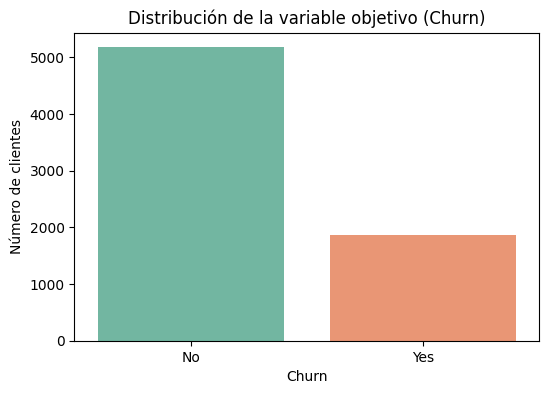

In [ ]:
#Distribuicion de la variable ojetivo
plt.figure(figsize=(6,4))
sns.countplot(x="Churn", data=df, palette="Set2")
plt.title("Distribución de la variable objetivo (Churn)")
plt.xlabel("Churn")
plt.ylabel("Número de clientes")
plt.show()

Podemos observar el desvalance moderado entre las dos clases, siendo la mayoría de los clientes activos, mientras que 1 de cada 4 abandonan el servicio. Esta proporción que ya habia sido cuantificada como 73.46% y 26.54% nos apoya visualmente a reconocer el desbalance que deberemos considerar al elegir las metricas de evaluación del modelo, ya que no sera suficiente con accuracy.

### *Distribución de variables numéricas relevantes*

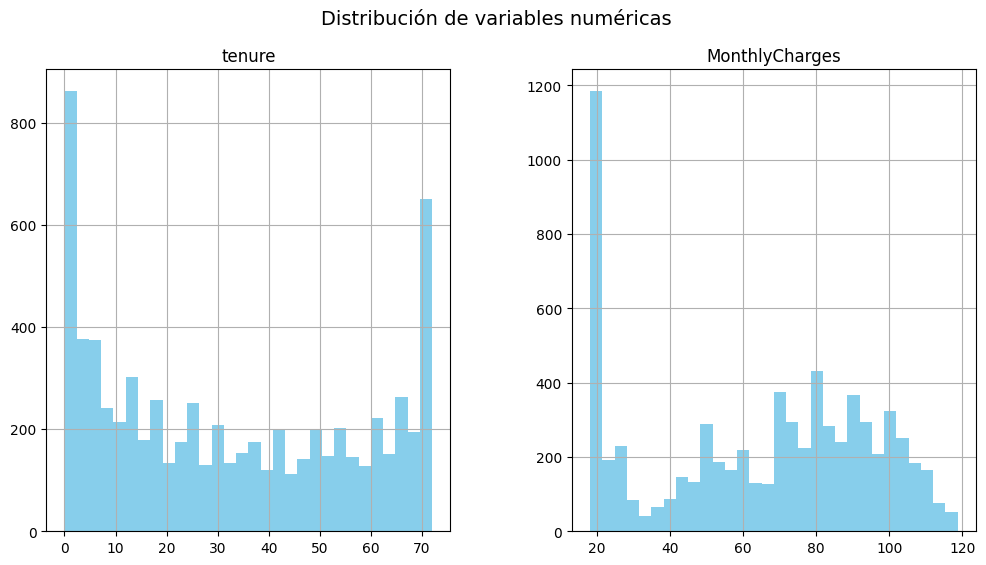

In [ ]:
#Distribuicion de variables numericas relevantes
num_vars = ["tenure","MonthlyCharges","TotalCharges"]

df[num_vars].hist(bins=30, figsize=(12,6), color="skyblue")
plt.suptitle("Distribución de variables numéricas", fontsize=14)
plt.show()


Podemos ver como tenure muestra una mayor concentración de clientes con pocos meses de antigüedad y otro grupo de clientes con varios años, sugiriendo que la etapa inicial de la relación con el cliente podría ser donde hay mayor riesgo de abandonar el servicio. Y por parte de MonthlyCharges se ve una distribución más dispersa, con un grupo notable en cargos bajos; siendo que TotalCharges este influenciada por tenure, ya que mayor antigüedad acumula un cargo total más alto.

### *Frecuencia de categorías principales*

/tmp/ipykernel_1744/1285082220.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=col, data=df, palette="Set2", ax=ax)
/tmp/ipykernel_1744/1285082220.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=col, data=df, palette="Set2", ax=ax)
/tmp/ipykernel_1744/1285082220.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=col, data=df, palette="Set2", ax=ax)
/tmp/ipykernel_1744/1285082220.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` 

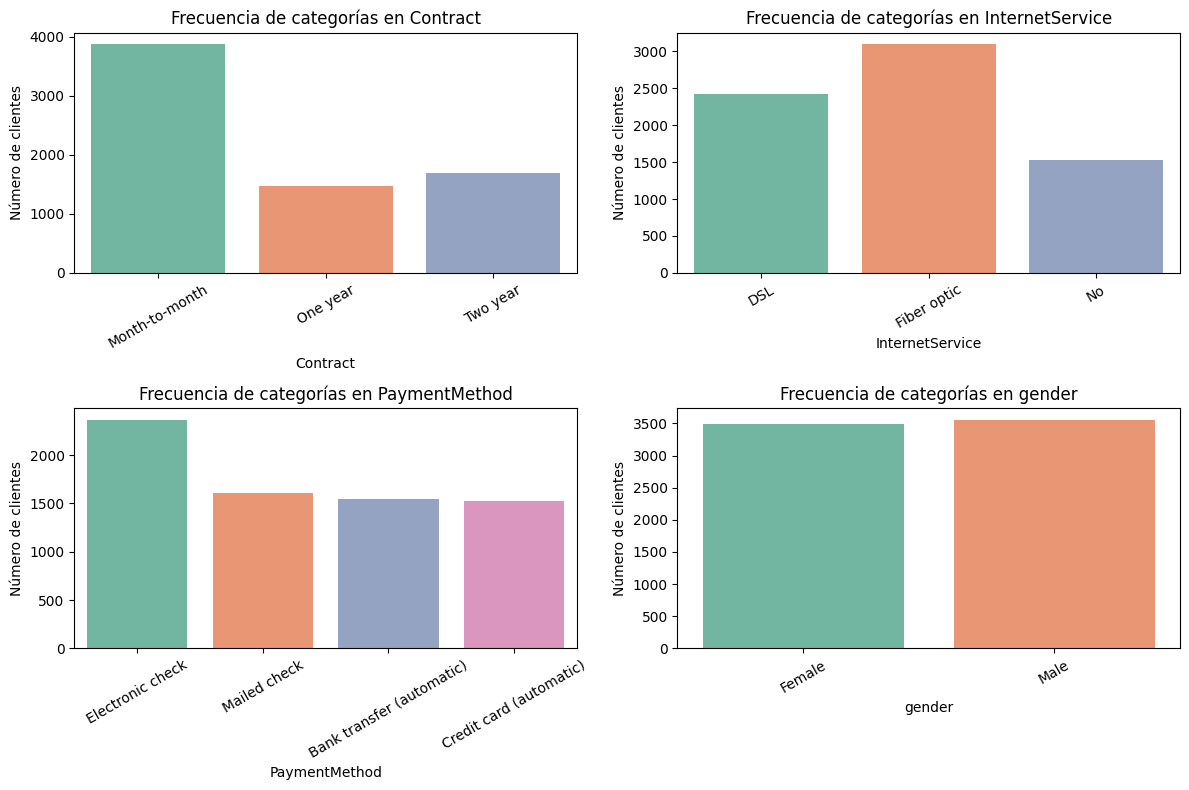

In [ ]:
#Frecuencia de categorias principales
cat_vars = ["Contract", "InternetService", "PaymentMethod", "gender"]

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.flatten()
for ax, col in zip(axes, cat_vars):
    sns.countplot(x=col, data=df, palette="Set2", ax=ax)
    ax.set_title(f"Frecuencia de categorías en {col}")
    ax.set_xlabel(col)
    ax.set_ylabel("Número de clientes")
    ax.tick_params(axis='x', rotation=30)
plt.tight_layout()
plt.show()

Podemos reconocer que la mayoría de los clientes tienen contrato mes a mes, que puede ser relevante porque este tipo de contrato suele asociarse a mayor rotación frente a contratos de uno a dos años. El servicio de Fiber optic es el servicio de internet más común entre los clientes, el método de pago más frecuente de Electronic check y que la distribución de género esta practicamente balanceada.

### *Comparación de tres variables con la variable objetivo*

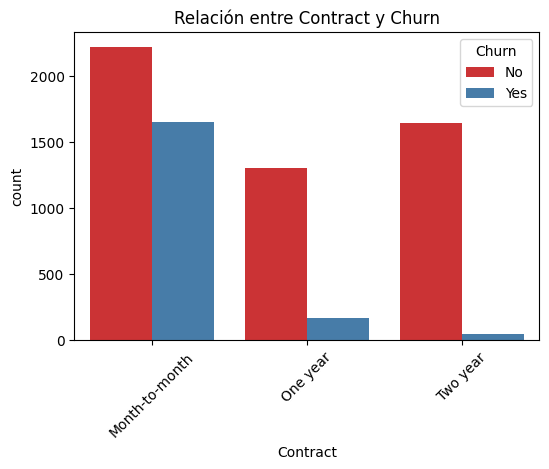

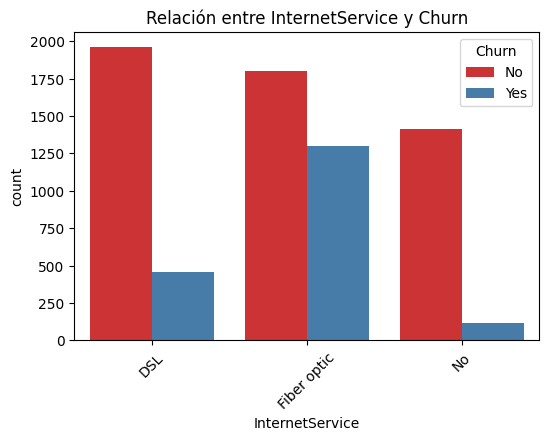

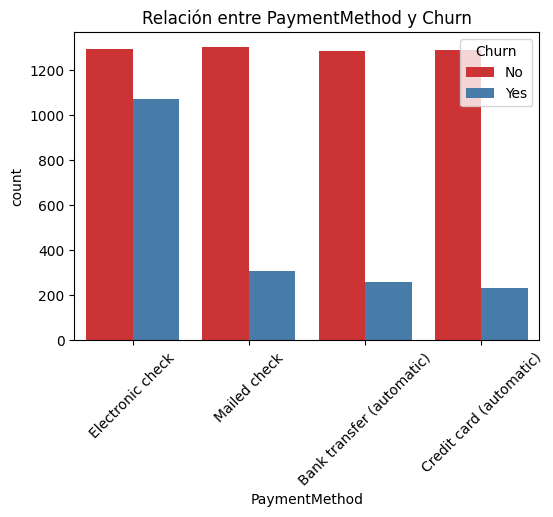

In [ ]:
# Comparacion de variables con la variable objetivo
comp_vars = ["Contract","InternetService","PaymentMethod"]

for col in comp_vars:
    plt.figure(figsize=(6,4))
    sns.countplot(x=col, hue="Churn", data=df, palette="Set1")
    plt.title(f"Relación entre {col} y Churn")
    plt.xticks(rotation=45)
    plt.show()


Podemos reconocer que los clientes con contarto Mes a Mes presentan una proporción de abandono notablemente mayor que los de contrato de Un año o Dos años. Asi como el servicio Fiber optic tiene una proporción mayor de abandono relativo frente a DSL o clientes sin internet. El metodo de pago Electronic check lo pdemos asociar con una tasa mayor de churn en comparación con pagos automaticos. Queda decir que estas relaciones son de froma univariada, siendo que no impliquen causalidad ni control por efecto conjunto en las variables, que podrían estar correlacionadas entre si.

### *Análisis de relaciones entre variables numéricas*

Se analiza la correlación entre las tres variables numéricas del dataset mediante un mapa de calor, con el fin de poder identificar posibles relaciones lineales entre ellas antes de pasar al modelado.

Recordemos que todavia la variable TotalCharges es texto, sin la conversión realizada todavia, solo aqui se convierte temporalmente sin modificación real para hacer posible el calculo de la correlación.

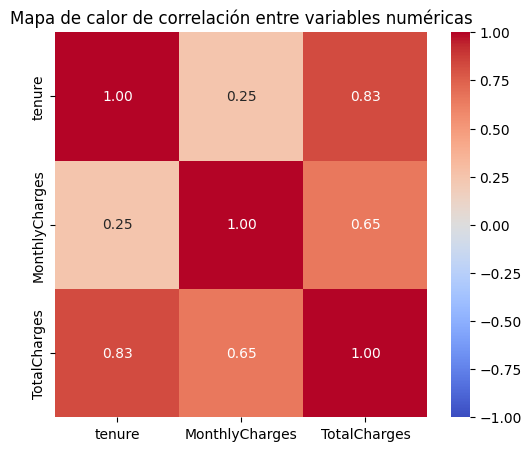

In [ ]:
plt.figure(figsize=(6,5))
totalCharges= pd.to_numeric(df['TotalCharges'], errors='coerce')
correlacion = pd.DataFrame({
    'tenure': df['tenure'],
    'MonthlyCharges': df['MonthlyCharges'],
    'TotalCharges': totalCharges
}).corr()

sns.heatmap(correlacion, annot=True, cmap='coolwarm', fmt='.2f', vmin=-1, vmax=1)
plt.title("Mapa de calor de correlación entre variables numéricas")
plt.show()

Podemos interpretar que la correlación fuerte y positiva entre tenure y TotalCharges, que es aproximadamente 0.83, lo cual es esperado, ya que a mayor antigüedad del cliente, mayor es el cargo total acumulado. MonthlyCharges y TotalCharge también muestran una correlación positiva moderada-alta de 0.65, consistente con que un cargo mensual más alto contribuye a un cargo total mayor. En cambio, tenure y MonthlyCharges nos presenta una correlación baja  de 0.25, indicando que la antigüedad del cliente no está fuertemente relacionada con cuánto paga mensualmente.

Esta correlación alta entre tenure y TotalCharges es un punto a tener en cuenta más adelante, ya que en los modelos lineales como la regresión logística, dos variables muy correlacionadas entre sí pueden hacer más difícil interpretar el efecto individual de cada una (multicolinealidad), aunque no afecta la capacidad predictiva del modelo en conjunto. Esto se deja documentado como un punto a revisar en el plan de mejora, en caso de que se busque profundizar en la interpretabilidad de los coeficientes.

### *Identificación de posibles valores atípicos*


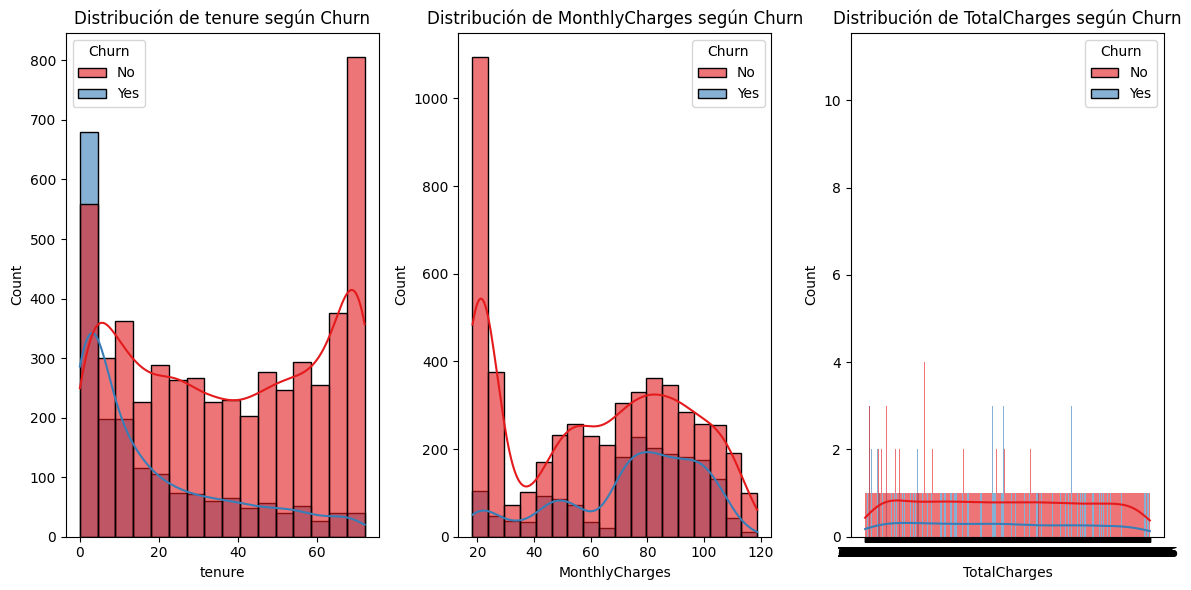

In [ ]:
#Identificación visual de posibles valores atípicos.
num_vars = ["tenure","MonthlyCharges","TotalCharges"]

plt.figure(figsize=(12,6))
for i, col in enumerate(num_vars, 1):
    plt.subplot(1,3,i)
    sns.histplot(data=df, x=col, hue="Churn", kde=True, palette="Set1", alpha=0.6)
    plt.title(f"Distribución de {col} según Churn")
plt.tight_layout()
plt.show()



No se observaron valores atípicos extremos en tenure, MonthlyCharges o TotalCharges, siendo que no haya valores negativos o fuera de los rangos. Sin embargo podemos apreciar que los clientes que abandonan el servicio se concentran en valores bajos de tenure y en cargos mensuales más altos, sugiriendonos que un cliente nuevo con servicios más costosos, es más propenso a abandonar el servicio.

### *Perfiles con mayor proporción de abandono*

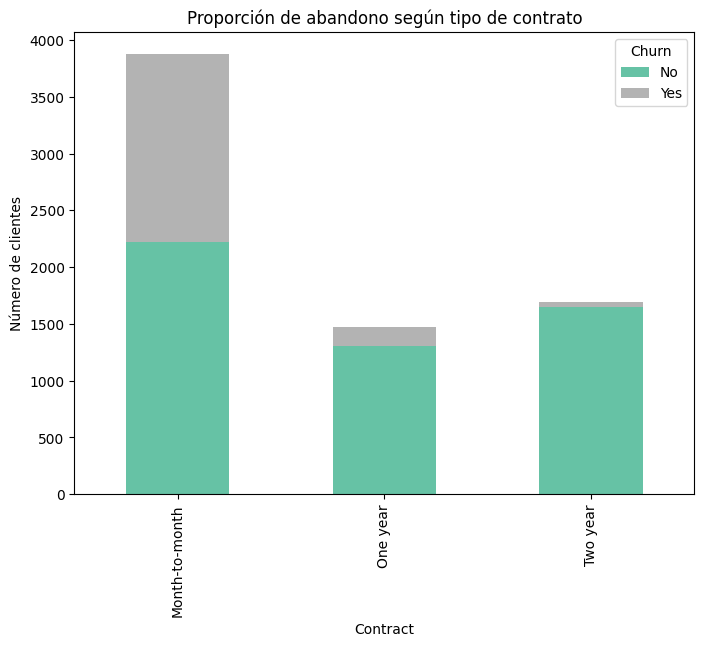

In [ ]:
#Observaciones iniciales sobre perfiles con mayor proporción de abandono.
df.groupby(["Contract","Churn"]).size().unstack().plot(kind="bar", stacked=True, figsize=(8,6), colormap="Set2")
plt.title("Proporción de abandono según tipo de contrato")
plt.ylabel("Número de clientes")
plt.show()


Entre las observaciones que podemos reconocer sobre los perfiles con mayor proporción de abandono es:
- Los clientes con contrato Mes a mes muestran, en términos relativos, la mayor proporción de abandono dentro de su propio grupo, en comparación con quienes tienen contrato de uno o dos años.
- Combinando las observaciones anteriores, podemos tener que un perfil con contrato mes a mes, antigüedad baja, servicio de fibra óptica y pago con cheque electrónico parece concentrar el mayor riesgo de abandonar el servicio.
- Estas observaciones son exploratorias y univariadas, ya que aún no se ha controlado el efecto conjunto de las variables, por lo que deberán confirmarse (o matizarse) con el modelo entrenado más adelante.

## **Revisión de posible desbalance de clases**

Churn
No     5174
Yes    1869
Name: count, dtype: int64
Churn
No     0.73463
Yes    0.26537
Name: proportion, dtype: float64


/tmp/ipykernel_1744/771500203.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x="Churn", data=df, palette="Set2")


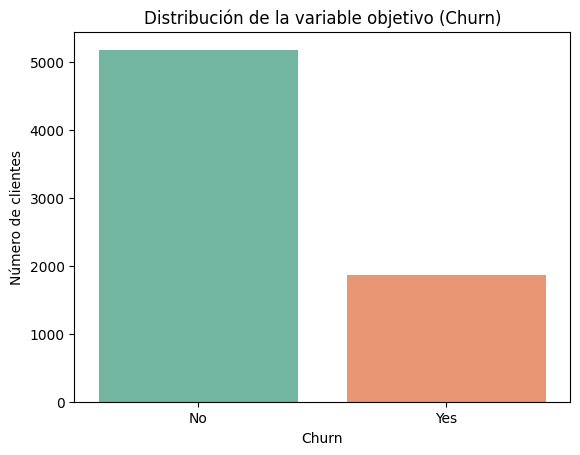

In [ ]:
# Muestra el conteo absoluto de clientes en cada clase (cuántos churn y cuántos no churn)
print(df['Churn'].value_counts())

# Muestra la proporción relativa de clientes en cada clase (porcentaje de churn vs no churn)
print(df['Churn'].value_counts(normalize=True))

# Grafica la distribución de churn para visualizar el desbalance de clases
sns.countplot(x="Churn", data=df, palette="Set2")
plt.title("Distribución de la variable objetivo (Churn)")
plt.xlabel("Churn")
plt.ylabel("Número de clientes")
plt.show()

Sobre el desbalance de clases, conocemos que porta la cantidad y proporción de 5,174 clientes no abandonan el servicio (73.46%) y 1,869 abandonan el servicio (26.54%). Existiendo un desbalance moderado, no extremo, pero suficiente para afectar la evaluación del modelo si no se maneja con cuidado.
Asimismo, pensamos que accuracy alta puede ser engañosa, ya que, que un modelo prediga siempre "No abandona" obtendría alrededor de 73.5% de accuracy sin identificar a ningún cliente en riesgo real, lo cual sería inútil para el objetivo de negocio de priorizar la retención. Y agregando que las métricas necesarias, aparte de accuracy, se requeriria precision, recall y F1-score para la clase de abandono, así como ROC-AUC, que nos ayudaria a evaluar la capacidad de discriminación del modelo de forma independiente al umbral de clasificación utilizado.

Incluyendo que la implicación de no detectar clientes que abandonan (falsos negativos), puede representar la pérdida directa de la oportunidad de retenerlos; para el negocio, este error suele ser más costoso que contactar innecesariamente a un cliente que en realidad iba a permanecer (falso positivo). Y no es obligatorio aplicar remuestreo en esta fase, ya que el desbalance es moderado, no severo. Teniendo modelos como la regresión logística o un árbol de decisión pueden manejarlo razonablemente bien si se combinan con métricas apropiadas y, si fuera necesario, con el parámetro class_weight='balanced'. El aplicar remuestreo de forma prematura podría introducir sesgos o sobreajuste sin evidencia de que realmente sea necesario; por ello se deja como una posible mejora a evaluar en la fase final, aplicándose únicamente sobre el conjunto de entrenamiento en caso de utilizarse, nunca sobre validación o prueba.

## **Identificación de posibles fugas de información**

Previo a la separación de las variables predictoras de la variable objetivo, se revisó cada grupo de columnas en el dataset para asegurarnos que ninguna de ellas tuviera presencia de data leakage (filtración involuntaria de información que revele el resultado antes de tiempo) y evitar así que algún resultado de Churn fuese encontrado por el modelo en el proceso de identificación de patrones.

Fueron analizados cuatro grupos:
- El ID del cliente (customerID)-Variables de facturación y antigüedad (tenure, MonthlyCharges,TotalCharges)
- Variables de servicios contratados(InternetService, OnlineSecurity, StreamingTV, entre otras)
- Variables contractuales(Contract, PaperlessBilling,PaymentMethod)

Para cada uno de los grupos se evaluó: cuándo se genera el dato, si estaría disponible antes de que ocurra el abandono, y si su uso podría inflar artificialmente las métricas del modelo.

In [ ]:
leakage_review = pd.DataFrame({
    'Variable': ['customerID', 'tenure, MonthlyCharges, TotalCharges',
                 'Servicios (InternetService, OnlineSecurity, StreamingTV, etc.)',
                 'Contract, PaperlessBilling, PaymentMethod'],
    'Cuándo se genera': ['Al alta del cliente', 'Durante la relación contractual',
                          'Al contratar/activar el servicio', 'Al contratar'],
    'Disponible al predecir': ['Sí, pero no aporta comportamiento', 'Sí', 'Sí', 'Sí'],
    'Riesgo de inflar métricas': ['No', 'No', 'No', 'No'],
    'Decisión': ['Eliminar', 'Conservar', 'Conservar', 'Conservar'],
    'Justificación': [
        'Identificador único (7043 valores distintos); no representa comportamiento y no generaliza a clientes nuevos',
        'Atributos de facturación/antigüedad conocidos antes de la decisión de abandono',
        'Describen la relación contractual vigente, no el resultado',
        'Son condiciones contractuales previas, no consecuencias del abandono'
    ]
})
leakage_review

,Variable,Cuándo se genera,Disponible al predecir,Riesgo de inflar métricas,Decisión,Justificación
0,customerID,Al alta del cliente,"Sí, pero no aporta comportamiento",No,Eliminar,Identificador único (7043 valores distintos); no representa comportamiento y no generaliza a clientes nuevos
1,"tenure, MonthlyCharges, TotalCharges",Durante la relación contractual,Sí,No,Conservar,Atributos de facturación/antigüedad conocidos antes de la decisión de abandono
2,"Servicios (InternetService, OnlineSecurity, StreamingTV, etc.)",Al contratar/activar el servicio,Sí,No,Conservar,"Describen la relación contractual vigente, no el resultado"
3,"Contract, PaperlessBilling, PaymentMethod",Al contratar,Sí,No,Conservar,"Son condiciones contractuales previas, no consecuencias del abandono"


No se identificaron variables con fuga de información entre los predictores, ya que todas solo describen condiciones conocidas antes o durante la relación contractual del cliente, no consecuencias como tal del abandono. La única variable que fue excluida de este análisis fue custumerID, ya que solo se trata de un identificador único, el cual no tiene valor predictivo y que más adelante podría darle problemas al modelo ya que no dejaría que generalice a nuevos clientes.

## **Separación de X (predictoras) y Y (objetivo)**

### *Corrección de TotalCharges*
Durante la exploración de la dataset nos percatamos que la columna "TotalCharges" originalmente estaba como tipo 'object',  el cual es un tipo de dato equivocado ya que la información que maneja es dinero. Esto se manifestó debido a que 11 registros contenían un espacio en blanco en lugar de un valor numérico, correspondientes a clientes con tenure=0 (los cuales son clientes que esta recién dados de alta y que aún no acumulan cargos totales).


In [ ]:
#Arreglo de columna TotalCharges

df['TotalCharges']= pd.to_numeric(df['TotalCharges'], errors='coerce')
print("Vacíos en TotalCharges después de convertir:", df['TotalCharges'].isnull().sum())

Vacíos en TotalCharges después de convertir: 11


Como podemos visualizar, la línea "pd.to_numeric(..., errors='coerce')" fue utilizada para convertir la columna a tipo numérica, transformando así esos 11 valores  vacíos en  valores "NaN" de forma en que puedan ser digeridos sin presentar fallas al tratar de tomarlos como texto.

Estos 11 valores faltantes no son eliminados, ni rellenados (por ahora), solo los dejamos así, ya que más adelante en el Pipeline de preprocesamiento se realizará la imputación de valores que correspondan a la mediana de los datos de entrenamiento, para evitar posibles data leakages hacia la validación y prueba.

### *Transformación de la variable objetivo*
La variable objetivo Churn es una variable dicotómica (ó variable binaria que solo puede tomar dos valores: si/no, verdadero/falso) y como se encontraba con valores "si / no" pandas la tomó como de tipo texto, es por eso que fue necesario convertirla a un formato binario numérico, para que posteriormente pudiese ser utilizada por algoritmos de clasificación.

Fue definido 1 como la clase positiva que hace referencia al cliente que abandonó el servicio, ya que ese es el evento de interés que la empresa busca anticipar y prevenir y 0 como clase negativa que refiere a los clientes activos:

In [ ]:
#Conversión de columna Churn ("Si/No") a binario (0,1)
df['Churn']= df['Churn'].map({'No':0, 'Yes':1})
print(df['Churn'].value_counts())

Churn
0    5174
1    1869
Name: count, dtype: int64


El resultado nos muestra que de los 7,043 clientes totales: 5,174 permanecen activos (0) y 1,869 abandonaron el servicio (1), estos resultados evidencian el desbalance de clases ya identificado anteriormente y que motiva el uso de estratificación en la partición de los datos.

### *Separación de variables predictoras y variable objetivo*
Con base en el análisis de fuga de información realizado anteriormente, se definió X como la variable que tendrá el conjunto de variables predictoras, eliminando a ID customer (identificador que nos puede traer problemas para generalizar durante el modelado) y  excluyendo a Churn (la variable que se busca predecir, y que no puede ser parte de los predictores).

y (variable objetivo) fue definida como la variable objetivo, es decir la columna Churn ya codificada en formato binario (0/1).

In [ ]:
X=df.drop(columns=['customerID','Churn'])

y = df['Churn']

print("Tamaño de X:", X.shape)
print("Tamaño de Y:", y.shape)

Tamaño de X: (7043, 19)
Tamaño de Y: (7043,)


El resultado nos confirma que X conserva las 19 columnas predictoras restantes (de las 21 originales, menos las 2 excluidas ID customer y Churn) para los 7,043 clientes, y que y contiene esa misma cantidad de registros, cada uno con su etiqueta correspondiente de abandono o permanencia.

En conclusión se excluyeron a las variables "IDcustomer" y "Churn" de X, mientras X se quedó con las 19 columnas restantes. Nuestra variable objetivo (Churn) fue asignada a y, por lo que y almacena su infomación ya convertida a binaria.

## **Estrategia de partición: entrenamiento, validación y prueba**

Los datos fueron divididos en tres conjuntos distintos: entrenamiento, validación y prueba, esto con el fin de poder entrenar el modelo, ir ajustando decisiones durante su desarrollo, y finalmente poder evaluarlo de manera honesta con datos que el modelo nunca antes hubiera visto.

Cada uno de estos conjuntos cumple con un papel diferente dentro del proyecto: el conjunto de entrenamiento (70%) es aquel con el que el modelo aprende los patrones de comportamiento relacionados al abandono de los clientes; el conjunto de validación (15%) se utiliza durante el desarrollo para ir comparando modelos y ajustando decisiones, sin necesidad de tocar el conjunto de prueba; y el conjunto de prueba (15%) se reserva únicamente para la evaluación final del modelo ya seleccionado, por lo que no debe utilizarse en ningún momento anterior para tomar decisiones. Esto nos garantiza que las métricas finales reflejen qué tan bien generalizaría el modelo ante clientes que jamás ha visto.

La división se realizó en dos pasos, ya que la función train_test_split solo permite separar los datos en dos partes a la vez: primero se separó el 70% correspondiente a entrenamiento del 30% restante, y posteriormente ese 30% fue divido a la mitad para poder obtener el 15% de validación y el 15% de prueba.

En ambos pasos fue utilizado el parámetro stratify, esto con la finalidad de conservar la proporción original de clientes que abandonan (aprox el 26.5%) frente a los que permanecen activos (aprox el 73.5%) en los tres conjuntos. Esto es de suma importancia ya que, debido al desbalance de clases identificado anteriormente, una partición hecha de manera aleatoria podría generar por azar proporciones distintas entre los conjuntos, lo cual afectaría tanto el aprendizaje del modelo como la confiabilidad de su evaluación.


Se registran a continuación los parámetros utilizados en la estrategia de partición, para dejar constancia de las proporciones, la semilla y el método de estratificación aplicados.

In [ ]:
particion = pd.DataFrame([
    ["Proporción de entrenamiento","70%"],
    ["Proporción de validación","15%"],
    ["Proporción de prueba","15%"],
    ["Semilla","42"],
    ["Método de estratificación","stratify=y en ambos splits (conserva la proporción 73.5% / 26.5% de Churn)"]
], columns=["Parametro", "Valor utilizado"])

pd.set_option('display.max_colwidth', None)
particion

,Parametro,Valor utilizado
0,Proporción de entrenamiento,70%
1,Proporción de validación,15%
2,Proporción de prueba,15%
3,Semilla,42
4,Método de estratificación,stratify=y en ambos splits (conserva la proporción 73.5% / 26.5% de Churn)


In [ ]:
#Partición de datos en Train (70%), Validación (15%) y Test (15%) con estratificación por Churn
from sklearn.model_selection import train_test_split

# Paso 1: separamos 70% train vs 30% "resto" (que luego partimos en validación y test)
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y,
    test_size=0.30,
    stratify=y,
    random_state=42
)

# Paso 2: partimos ese 30% "resto" a la mitad -> 15% validación, 15% test
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp,
    test_size=0.50,
    stratify=y_temp,
    random_state=42
)

print("Tamaño de X_train:", X_train.shape)
print("Tamaño de X_val:", X_val.shape)
print("Tamaño de X_test:", X_test.shape)

print("\nProporción de Churn en train:")
print(y_train.value_counts(normalize=True))

print("\nProporción de Churn en validación:")
print(y_val.value_counts(normalize=True))

print("\nProporción de Churn en test:")
print(y_test.value_counts(normalize=True))

Tamaño de X_train: (4930, 19)
Tamaño de X_val: (1056, 19)
Tamaño de X_test: (1057, 19)

Proporción de Churn en train:
Churn
0    0.734686
1    0.265314
Name: proportion, dtype: float64

Proporción de Churn en validación:
Churn
0    0.734848
1    0.265152
Name: proportion, dtype: float64

Proporción de Churn en test:
Churn
0    0.734153
1    0.265847
Name: proportion, dtype: float64


Los resultados nos confirman que la estratificación funcionó de manera correcta, ya que la proporción de Churn se mantuvo prácticamente idéntica en los tres conjuntos (73.47% / 73.48% / 73.42% para la clase 0, y 26.53% / 26.52% / 26.58% para la clase 1).
\n De igual manera, fue fijado un random_state=42 como semilla en ambos pasos de la partición, lo cual nos garantiza que el experimento sea reproducible, es decir que si el notebook llegase a ejecutarse de nuevo, se obtendrían exactamente los mismos conjuntos que ya tenemos.

## **Construcción del pipeline de preprocesamiento**

### *Identificación de tipos de variables (numéricas vs categóricas)*

Antes de construir el pipeline de preprocesamiento, fue necesario identificar qué tipo de dato tenía cada una de las 19 columnas de X, esto con la finalidad de poder aplicarles el tratamiento correcto más adelante (ya que las variables numéricas y las categóricas no pueden ser tratadas de la misma manera).

In [ ]:
#Identificación de tipos de variables (numéricas vs categóricas)
X.dtypes

,0
gender,object
SeniorCitizen,int64
Partner,object
Dependents,object
tenure,int64
PhoneService,object
MultipleLines,object
InternetService,object
OnlineSecurity,object
OnlineBackup,object


Al revisar los tipos con X.dtypes, nos encontramos con que 3 columnas son de tipo numérico (tenure como int64, además de MonthlyCharges y TotalCharges como float64) y las 16 columnas restantes son de tipo object, es decir, texto.

Cabe resaltar el caso de SeniorCitizen: aunque pandas la detecta como int64 (0 y 1), en realidad se trata de una variable categórica binaria disfrazada de número, ya que esos valores representan "No es adulto mayor" y "Sí es adulto mayor", no una cantidad que tenga sentido promediar o escalar. Es por eso que, más adelante, esta variable fue tratada junto con las categóricas y no junto con las numéricas.

### *Separación de columnas según su tipo*

Con base en la identificación de tipos realizada anteriormente, se construyeron dos listas de columnas: columnas_numericas, que contiene a tenure, MonthlyCharges y TotalCharges; y columnas_categoricas, que contiene a las 16 columnas restantes, incluyendo a SeniorCitizen, la cual, aunque está almacenada como número, fue tratada como categórica por las razones ya explicadas.

Estas listas serán utilizadas más adelante para indicarle al ColumnTransformer qué tratamiento aplicarle a cada grupo de columnas dentro del pipeline de preprocesamiento.

In [ ]:
columnas_numericas = ['tenure','MonthlyCharges','TotalCharges']
columnas_categoricas =['gender','SeniorCitizen','Partner','Dependents',
                       'PhoneService','MultipleLines','InternetService',
                       'OnlineSecurity','OnlineBackup','DeviceProtection',
                       'TechSupport','StreamingTV','StreamingMovies',
                       'Contract','PaperlessBilling','PaymentMethod']

print("Columnas numéricas:", len(columnas_numericas))
print("Columnas categóricas:", len(columnas_categoricas))
print("Total:", len(columnas_numericas)+len(columnas_categoricas))

Columnas numéricas: 3
Columnas categóricas: 16
Total: 19


El resultado nos confirma que no se quedó ninguna columna fuera de esta clasificación, ya que la suma de ambas listas (3 numéricas + 16 categóricas) nos da como resultado las 19 columnas totales que tiene X.

### **Pipeline de preprocesamiento: imputación, escalamiento y codificación**

Para poder aplicarle a cada tipo de columna el tratamiento que le corresponde, fueron construidos dos mini-pipelines: uno para las variables numéricas y otro para las categóricas, ya que cada grupo requiere pasos distintos.

In [ ]:
#Pipeline para variables numéricas: imputación (mediana) + escalamiento
pipeline_numerico = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

#Pipeline para variables categóricas: imputación (moda) + codificación One-Hot
pipeline_categorico = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore'))
])

#Preprocesador final: aplica cada mini-pipeline a su grupo de columnas correspondiente
preprocesador = ColumnTransformer(
    transformers=[
        ('num', pipeline_numerico, columnas_numericas),
        ('cat', pipeline_categorico, columnas_categoricas)
    ]
)

preprocesador

ColumnTransformer(transformers=[('num',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='median')),
                                                 ('scaler', StandardScaler())]),
                                 ['tenure', 'MonthlyCharges', 'TotalCharges']),
                                ('cat',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='most_frequent')),
                                                 ('encoder',
                                                  OneHotEncoder(handle_unknown='ignore'))]),
                                 ['gender', 'SeniorCitizen', 'Partner',
                                  'Dependents', 'PhoneService', 'MultipleLines',
                                  'InternetService', 'OnlineSecurity',
                                  'OnlineBackup', 'DeviceProtection',
                                  'TechSupport', 'StreamingTV',
                                  'StreamingMovies', 'Contract',
                                  'PaperlessBilling', 'PaymentMethod'])])

El pipeline_numerico aplica primero una imputación con la mediana “SimpleImputer(strategy='median')”, por si llegara a existir algún valor faltante en tenure, MonthlyCharges o TotalCharges, y posteriormente un escalamiento “StandardScaler()”, que deja a estas variables en una misma escala comparable (media 0, desviación estándar 1). Esto es de suma importancia ya que, sin este escalamiento, una variable como TotalCharges (que puede llegar a miles) podría hacer creer al modelo que "pesa más" que tenure (que va de 0 a 72), solo por tener números más grandes, sin que eso necesariamente sea cierto.

El pipeline_categorico aplica primero una imputación con la moda “SimpleImputer(strategy='most_frequent')”, rellenando cualquier valor faltante con la categoría más frecuente de esa columna, y posteriormente una codificación One-Hot “OneHotEncoder(handle_unknown='ignore')”, la cual convierte cada categoría de texto en columnas de 0 y 1. Se optó por One-Hot en lugar de asignar números consecutivos a cada categoría (como 0,1,2), ya que esto último induciría al modelo a interpretar relaciones de orden o magnitud que no existen realmente entre las categorías (por ejemplo, que Two year es "el doble" de One year). El parámetro “ handle_unknown='ignore' “protege al pipeline de fallar en caso de que en el futuro aparezca una categoría nueva que no fue vista durante el entrenamiento.

Finalmente, ambos mini-pipelines fueron integrados dentro de un ColumnTransformer, el cual se encarga de aplicarle a cada grupo de columnas (numéricas y categóricas) su tratamiento correspondiente dentro de un solo objeto (preprocesador), facilitando así que este mismo flujo pueda aplicarse de manera consistente a los tres conjuntos de datos (entrenamiento, validación y prueba).

#### Aplicación del preprocesador: ajuste solo con entrenamiento

En este paso se aplicó el preprocesador a los tres conjuntos de datos, pero de manera diferenciada: en X_train se utilizó fit_transform(), mientras que en X_val y X_test se utilizó únicamente transform(), sin volver a ajustar (fit).

Esto se debe a que fit_transform() en realidad realiza dos pasos: primero "aprende" los parámetros necesarios a partir de los datos (por ejemplo, la mediana y desviación estándar de las columnas numéricas, o las categorías existentes en las columnas categóricas), y después transforma los datos utilizando esos parámetros. Si ese aprendizaje se hiciera con el conjunto completo (entrenamiento + validación + prueba), el preprocesador estaría "viendo" información de datos que se supone el modelo no debería conocer todavía, lo cual constituiría una nueva forma de data leakage. Por eso, el ajuste (fit) se realiza únicamente con X_train, y esos mismos parámetros ya aprendidos son los que se aplican (transform) sobre X_val y X_test, sin que estos últimos influyan en el aprendizaje del preprocesador.

In [ ]:
X_train_procesado = preprocesador.fit_transform(X_train)
X_val_procesado = preprocesador.transform(X_val)
X_test_procesado = preprocesador.transform(X_test)

print("Tamaño de X_train procesado:", X_train_procesado.shape)
print("Tamaño de X_val procesado:", X_val_procesado.shape)
print("Tamaño de X_test procesado:", X_test_procesado.shape)

Tamaño de X_train procesado: (4930, 46)
Tamaño de X_val procesado: (1056, 46)
Tamaño de X_test procesado: (1057, 46)


El resultado muestra que las 19 columnas originales de X se transformaron en 46 columnas en los tres conjuntos procesados. Este incremento se debe al OneHotEncoder, el cual no conserva una sola columna por variable categórica, sino que crea una columna nueva por cada categoría distinta que contiene esa variable (por ejemplo, Contract, que tiene 3 categorías, se convierte en 3 columnas de 0 y 1). Al sumar las columnas generadas por las 16 variables categóricas (43 en total) más las 3 columnas numéricas, que solo se escalan y no se multiplican, se obtiene el total de 46 columnas finales.

#### Verificación del número de categorías por variable
Para comprobar con evidencia el resultado de 46 columnas obtenido tras aplicar el OneHotEncoder, se revisó cuántas categorías únicas contiene cada una de las 16 variables categóricas.

In [ ]:
#Ver cuántas categorías tiene cada columna categórica
for col in columnas_categoricas:
    print(col, "->", X[col].nunique(), "categorías:", X[col].unique())

gender -> 2 categorías: ['Female' 'Male']
SeniorCitizen -> 2 categorías: [0 1]
Partner -> 2 categorías: ['Yes' 'No']
Dependents -> 2 categorías: ['No' 'Yes']
PhoneService -> 2 categorías: ['No' 'Yes']
MultipleLines -> 3 categorías: ['No phone service' 'No' 'Yes']
InternetService -> 3 categorías: ['DSL' 'Fiber optic' 'No']
OnlineSecurity -> 3 categorías: ['No' 'Yes' 'No internet service']
OnlineBackup -> 3 categorías: ['Yes' 'No' 'No internet service']
DeviceProtection -> 3 categorías: ['No' 'Yes' 'No internet service']
TechSupport -> 3 categorías: ['No' 'Yes' 'No internet service']
StreamingTV -> 3 categorías: ['No' 'Yes' 'No internet service']
StreamingMovies -> 3 categorías: ['No' 'Yes' 'No internet service']
Contract -> 3 categorías: ['Month-to-month' 'One year' 'Two year']
PaperlessBilling -> 2 categorías: ['Yes' 'No']
PaymentMethod -> 4 categorías: ['Electronic check' 'Mailed check' 'Bank transfer (automatic)'
 'Credit card (automatic)']


Se identificaron 6 variables con 2 categorías (gender, SeniorCitizen, Partner, Dependents, PhoneService, PaperlessBilling), 9 variables con 3 categorías (MultipleLines, InternetService, OnlineSecurity, OnlineBackup, DeviceProtection, TechSupport, StreamingTV, StreamingMovies, Contract) y 1 variable con 4 categorías (PaymentMethod).

Al multiplicar cada variable por su número de categorías (6×2 + 9×3 + 1×4 = 12 + 27 + 4 = 43) y sumarle las 3 columnas numéricas, que no se multiplican sino que solo se escalan, se obtienen las 46 columnas finales confirmadas anteriormente. Esto comprueba que el OneHotEncoder funcionó correctamente y que ninguna columna se perdió ni se generó de más durante la transformación.

## **Modelo baseline**

Antes de comparar modelos de aprendizaje automático, vamos a construir un baseline, que puede ser reconocido como un modelo de referencia trivial, utilizando DummyClassifier con la estrategia most_frequent, logramos predecir siempre la clase mayoritaria (Churn = No), usando el mismo pipeline de preprocesamiento, la misma partición y la misma semilla (42) que se usarán para el resto de los modelos.

El propósito de este baseline es poder establecer un piso mínimo de comparación, siendo que cualquier modelo de aprendizaje automático debe superarlo claramente, en especial en Recall y F1-score de la clase de abandono, para justificar que realmente está aprendiendo un patrón y no solo aprovechándose del desbalance de clases.

In [ ]:
# Baseline. DummyClassifier con estrataegia "most_frequent"
from sklearn.dummy import DummyClassifier

base = Pipeline(steps=[
    ('preprocesador', preprocesador),
    ('model', DummyClassifier(strategy= 'most_frequent', random_state= 42))
])

base.fit(X_train, y_train)
y_predBase= base.predict(X_val)

print("Predicción unica en validación: ", np.unique(y_predBase))
print("Conteo de predicciones: \n   ", pd.Series(y_predBase).value_counts())

Predicción unica en validación:  [0]
Conteo de predicciones: 
    0    1056
Name: count, dtype: int64


Podemos interpretar que el baseline predice 0, que no abandona el servicio para los 1,056 clientes del conjunto de validación, sin excepción. Esto significa que, aunque el accuracy sea igual a la proporción de la clase mayoritaria (73.5%), su Recall para la clase de abandono sería 0%, ya que nunca predice esa clase. Esto confirma, con evidencia directa, por qué la accuracy por sí sola no es suficiente para evaluar el problema, ya que un modelo "inútil" para el negocio, que nunca detecta a ningún cliente en riesgo, puede de todas formas alcanzar una accuracy relativamente alta.

## **Entrenamiento de modelos iniciales**

Se entrenaran dos modelos adicionales al baseline, haciendo uso del pipeline de preprocesamiento, con la misma partición de datos y la misma semilla.

| Modelo | Función dentro de la comparación |
|---|---|
| DummyClassifier | Referencia trivial |
| Regresión logística | Línea base interpretable |
| Árbol de decisión | Alternativa inicial de comparación (captura relaciones no lineales) |

Se da uso de configuraciones inciales razonables, sin buscar realizar una busqueda extensa de hiperparámetros, siendo algo más para la sección del plan de mejora.

### *Modelo de Regresión logistica*

In [ ]:
from sklearn.linear_model import LogisticRegression

model_LogReg = Pipeline(steps=[
    ('preprocesador', preprocesador),
    ('model', LogisticRegression(max_iter = 1000, random_state = 42))
])

model_LogReg.fit(X_train, y_train)

print("    Regresión logística entrenada\n")
print("Configuración:")
for par, valor in model_LogReg.named_steps['model'].get_params().items():
 print(f" * {par}: {valor}")

    Regresión logística entrenada

Configuración:
 * C: 1.0
 * class_weight: None
 * dual: False
 * fit_intercept: True
 * intercept_scaling: 1
 * l1_ratio: None
 * max_iter: 1000
 * multi_class: deprecated
 * n_jobs: None
 * penalty: l2
 * random_state: 42
 * solver: lbfgs
 * tol: 0.0001
 * verbose: 0
 * warm_start: False


El modelo de regresión logística se entrenó con max_iter=1000, esto para asegurar que el algoritmo de optimización converja y con random_state=42, que es para reproducibilidad; siendo que el resto de los parámetros se dejaron en su valor por defecto de scikit-learn. No se busco aplicar un ajuste de hiperparámetros, ya que nuestro objetivo es obtener una comparación inicial razonable, no un modelo optimizado.

### *Modelo Arbol de decisión*

In [ ]:
from sklearn.tree import DecisionTreeClassifier

model_arbol = Pipeline(steps=[
    ('preprocesador', preprocesador),
    ('model', DecisionTreeClassifier(max_depth= 5, random_state= 42))
])

model_arbol.fit(X_train, y_train)

print("    Arbol de decisión entrenado\n")
print("Configuración:")
for par, valor in model_arbol.named_steps['model'].get_params().items():
 print(f" * {par}: {valor}")

    Arbol de decisión entrenado

Configuración:
 * ccp_alpha: 0.0
 * class_weight: None
 * criterion: gini
 * max_depth: 5
 * max_features: None
 * max_leaf_nodes: None
 * min_impurity_decrease: 0.0
 * min_samples_leaf: 1
 * min_samples_split: 2
 * min_weight_fraction_leaf: 0.0
 * monotonic_cst: None
 * random_state: 42
 * splitter: best


En el árbol de decisión se configuró con max_depth=5, que nos ayuda a limitar su profundidad máxima a 5 niveles para reducir el riesgo de sobreajuste, ya que un árbol sin restricción de profundidad tiende a memorizar el conjunto de entrenamiento. Mientras que el resto de los parámetros (criterion='gini', min_samples_split=2, min_samples_leaf=1) se dejaron en su valor por defecto, ya que, al igual que con la regresión logística, el ajuste fino de hiperparámetros se espera tratar en otra sección.

## **Evaluación de los modelos**

Con los mdodelos realizados, ahorea nos centramos en evaluar los tres modelos (baseline, regresión logística y árbol de decisión) sobre el conjunto de validación, utilizando la clase de abandono (1) como clase positiva. Para ello se construye una función auxiliar (eval_model) que calcula, para cualquier modelo ya entrenado: accuracy, precision, recall, F1-score y ROC-AUC, siendo esta última solo si el modelo puede generar probabilidades mediante predict_proba.

Las metricas que tratamos y su importancia en estos problemas:
- **Accuracy:**  porque proporciona total de predicciones correctas; llegando a ser engañosa cuando hay desbalance de clases, como ya se comento.
- **Precision (clase abandono):** siendo de los clientes marcados como "en riesgo", qué proporción realmente abandona el servicio. Llega ser importante porque nos ayuda a dirigir acciones de retención a clientes que no iban a abandonar tiene un costo (descuentos y tiempo del equipo).
- **Recall (clase abandono):** siendo de los clientes que realmente abandonan el servicio, tratando de qué proporción es detectada por el modelo. Es crítico porque el objetivo del proyecto es identificar a tiempo a los clientes en riesgo.
- **F1-score:** conlleva el balance entre precision y recall, siendonos útil para comparar modelos cuando ambos tipos de error importan.
- **ROC-AUC:** nos ayuda a medir la capacidad de discriminación del modelo entre clases, para todos los umbrales posibles, sin depender de un punto de corte específico.

In [ ]:
def eval_model(name, model, X_eval, y_eval):
  y_pred = model.predict(X_eval)

  if hasattr(model, "predict_proba"):
    y_prob = model.predict_proba(X_eval)[:, 1]
  else:
    y_prob = None

  result = {
      "Modelo": name,
      "Acurracy": accuracy_score(y_eval, y_pred),
      "Precision": precision_score(y_eval,y_pred, pos_label= 1, zero_division= 0),
      "Recall": recall_score(y_eval,y_pred, pos_label= 1),
      "F1-score": f1_score(y_eval,y_pred, pos_label= 1),
      "ROC-AUC": roc_auc_score(y_eval,y_prob) if y_prob is not None else None
  }
  return result, y_pred, y_prob

resultado = []
resBase, predBase, probBase = eval_model("DummyClassifier", base, X_val, y_val)
resLog, predLog, probLog = eval_model("Regresion logistica", model_LogReg, X_val, y_val)
resArb, predArb, probArb = eval_model("Arbol de decision", model_arbol, X_val, y_val)

resultado = [resBase, resLog, resArb]
tabla = pd.DataFrame(resultado).set_index("Modelo").round(4)

tabla

,Acurracy,Precision,Recall,F1-score,ROC-AUC
Modelo,,,,,
DummyClassifier,0.7348,0.0000,0.0000,0.0000,0.5000
Regresion logistica,0.8059,0.6459,0.5929,0.6182,0.8453
Arbol de decision,0.7926,0.6063,0.6214,0.6138,0.8365


Con el DummyClassifier obtiene 73.48% de accuracy, pero 0% en precision, recall y F1-score, y un ROC-AUC de exactamente 0.50 (equivalente a una decisión al azar), confirmando lo ya pensado, nunca predice la clase de abandono.

Los dos modelos entrenados superan claramente al baseline en todas las métricas relevantes. La regresión logística obtiene el mejor desempeño general (accuracy=80.59%, precision=64.59%, F1-score=61.82%, ROC-AUC=84.53%), mientras que el árbol de decisión obtiene un recall ligeramente superior (62.14% frente a 59.29%), a costa de una precision y un ROC-AUC menores. Esto anticipa la discusión de la siguiente sección, que ningún modelo domina al otro en todas las métricas a la vez, por lo que la selección final deberá ponderar el costo relativo de cada tipo de error, no solo un número aislado. No se selecciona un modelo por accuracy: de hecho, aunque la regresión logística también tiene la mayor accuracy, el criterio de selección se nos debera basar en el conjunto de métricas, especialmente recall y F1 de la clase de abandono, dado el desbalance.

### *Matriz de confusión*

Tratamos la graficación de tres matrices de confusión sobre el conjunto de validación, siendo que 1,056 clientes en total, donde 776 que permanecen y 280 que abandonan, esto nos apoya en poder analizar no solo cuántos aciertos tiene cada modelo, sino en qupe tipo de error se equivoca.

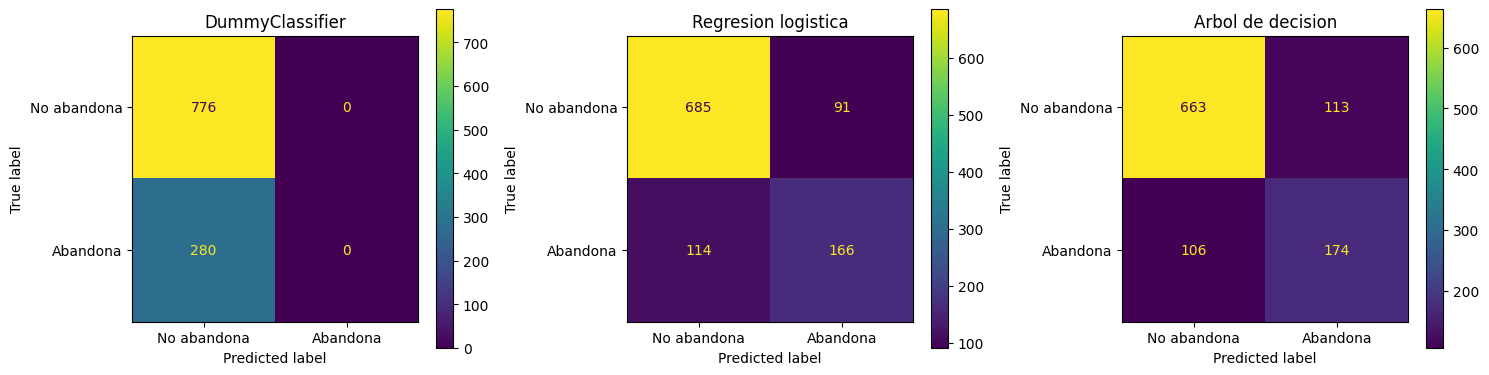

In [ ]:
fig, axes = plt.subplots(1, 3, figsize = (15,4))

for ax, name, pred in zip(axes,
                          ["DummyClassifier", "Regresion logistica", "Arbol de decision"],
                          [predBase, predLog, predArb]):
  cm = confusion_matrix(y_val, pred)
  ConfusionMatrixDisplay(cm, display_labels= ["No abandona", "Abandona"]).plot(ax=ax)
  ax.set_title(name)
plt.tight_layout()
plt.show()

Lo que pudimos obtener de dichas graficas, es lo siguiente:

| Modelo | VN | FP | FN | VP |
|---|---|---|---|---|
| DummyClassifier | 776 | 0 | 280 | 0 |
| Regresión logística | 685 | 91 | 114 | 166 |
| Árbol de decisión | 663 | 113 | 106 | 174 |

Siendo que el baseline nunca genera falsos positivos, pero tampoco ningún verdadero positivo, porque todos los 280 clientes que sí abandonan quedan sin detectar (280 falsos negativos). Entre los dos modelos entrenados, la regresión logística comete menos falsos positivos (91 contra 113) pero más falsos negativos (114 contra 106) que el árbol de decisión.

### *Curva ROC*

Se grafica la curva ROC, que es la rasa de verdaderos positivos contra la tasa de falsos positivos para todos los umbrales posibles de la regresión logística y el árbol de decisión, junto con la diagonal de referencia de un clasificador que decide al azar (AUC=0.50). No se incluye al DummyClassifier porque su curva coincide exactamente con esa diagonal, al no discriminar entre clases.

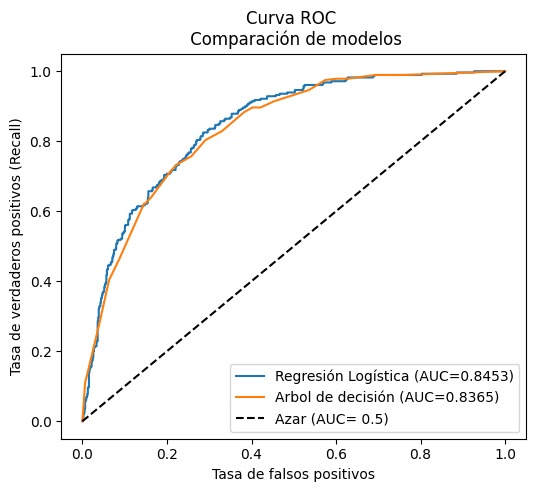

In [ ]:
plt.figure(figsize= (6,5))

for name, prob in [("Regresión Logística", probLog), ("Arbol de decisión", probArb)]:
  fpr, tpr, _ = roc_curve(y_val, prob)
  auc_val = roc_auc_score(y_val, prob)
  plt.plot(fpr, tpr, label=f"{name} (AUC={auc_val:.4f})")

plt.plot([0,1],[0,1],'k--', label="Azar (AUC= 0.5)")
plt.xlabel("Tasa de falsos positivos")
plt.ylabel("Tasa de verdaderos positivos (Recall)")
plt.title("Curva ROC \n Comparación de modelos")
plt.legend()
plt.show()

Podemos interpretar que ambas curvas se ubican claramente por encima de la diagonal de azar, confirmando que los dos modelos tienen capacidad real de discriminación entre clientes que abandonan y los que no. Siendo que la regresión logística obtiene un ROC-AUC ligeramente superior (0.8453) frente al árbol de decisión (0.8365), lo que indica que, en promedio y considerando todos los posibles umbrales de decisión (no solo 0.50), la regresión logística ordena mejor a los clientes según su riesgo real de abandono.

## **Análisis de errores de clasificación**

Con base a la matriz de confusión de la regresión logistica, que es el modelo con el mejor desempeño general sobre el conjunto de validación, se interpretan cuatro componentes en el contexto de retención de clientes:

In [ ]:
errorClas = pd.DataFrame([
    ["Verdadero positivo (VP)","166","Cliente clasificado correctamente como en riesgo de abandono, y que efectivamente abandona"],
    ["Verdadero negativo (VN)","685","Cliente clasificado correcatmente como estable, y que efectivamente permanece"],
    ["Falso positivo (FP)","91","Cliente clasificado con riesgo de abandono que en realidad permanece"],
    ["Falso negativo (FN)","114","Cliente clasificado como estable que en realidad abandona"]
], columns=["Tipo de error","Cantidad","Interpretación"])

errorClas

,Tipo de error,Cantidad,Interpretación
0,Verdadero positivo (VP),166,"Cliente clasificado correctamente como en riesgo de abandono, y que efectivamente abandona"
1,Verdadero negativo (VN),685,"Cliente clasificado correcatmente como estable, y que efectivamente permanece"
2,Falso positivo (FP),91,Cliente clasificado con riesgo de abandono que en realidad permanece
3,Falso negativo (FN),114,Cliente clasificado como estable que en realidad abandona


**Costos de cada tipo de error para la organización:**
- Un **falso positivo** implica dirigir una acción de retención (llamada, descuento, oferta) hacia un cliente que de todas formas iba a permanecer, ocasionando que represente un gasto de recursos moderado, pero no una pérdida de ingreso.
- Un **falso negativo** implica no detectar a un cliente que sí abandona, perdiendo la oportunidad de intentar retenerlo, lo que representa una pérdida directa de ingreso recurrente, y normalmente es más costoso recuperar o reemplazar a un cliente perdido que retener a uno existente.

El error más critico para la organización podemos saber en este contexto de retención que el falso negativo suele ser el más costoso, ya que representa una pérdida de negocio que ya no puede corregirse una vez que el cliente abandonó. La métrica nos debera ayudar a vigilar específicamente este riesgo es el recall de la clase de abandono, siendo de qué proporción de los abandonos reales logra detectar el modelo.

Podemos comparar en los dos modelos entrenados, que la regresión logística presenta menos falsos positivos (91 contra 113) pero más falsos negativos (114 contra 106) que el árbol de decisión. Esto significa que el árbol detecta una fracción ligeramente mayor de los clientes que realmente abandonan, a costa de generar más alertas sobre clientes que en realidad no lo harían. Ninguno de los dos modelos domina al otro en ambos tipos de error simultáneamente, por lo que la elección entre ellos depende de qué tipo de error le resulte más costoso a la organización.

Sabemos que la selección del modelo no debe basarse solo en accuracy, ya que un modelo puede alcanzar una accuracy alta simplemente por acertar en la clase mayoritaria, como llega a ocurrir con DummyClassifier, que llega a 73.48% de accuracy sin detectar un solo caso de abandono. La comparación debe considerarse en recall, precision, F1-score y ROC-AUC en conjunto, ponderando el costo relativo de cada tipo de error para el negocio, y no un solo número aislado.

In [ ]:
#Interpretación cuantitativa de la matriz
cm_logreg = confusion_matrix(y_val, predLog)
tn, fp, fn, tp = cm_logreg.ravel()

print(f"Verdaderos negativos (VN): {tn}")
print(f"Falsos positivos (FP): {fp}")
print(f"Falsos negativos (FN): {fn}")
print(f"Verdaderos positivos (VP): {tp}")

print(f"\nDe los {tp + fn} clientes que realmente abandonaron, el modelo detecto a {tp} ({tp/(tp+fn):.1%}) y dejo pasar a {fn} ({fn/(tp+fn):.1%}).")
print(f"De los {tn + fp} clientes que realmente permanecieron, el modelo los clasifico correctamente en {tn} casos y genero una alerta innecesaria (falso positivo) en {fp} casos.")

Verdaderos negativos (VN): 685
Falsos positivos (FP): 91
Falsos negativos (FN): 114
Verdaderos positivos (VP): 166

De los 280 clientes que realmente abandonaron, el modelo detecto a 166 (59.3%) y dejo pasar a 114 (40.7%).
De los 776 clientes que realmente permanecieron, el modelo los clasifico correctamente en 685 casos y genero una alerta innecesaria (falso positivo) en 91 casos.


## **Umbral de decisión**

Se busco obtener las probabilidades de predicción de la regresión logística (el modelo con mejor desempeño general) y compararlas con dos umbrales de decisión, que es el predeterminado (0.50) y uno alternativo, más sensible a detectar abandono (0.35). Nuestro propósito es evidenciar que la clasificación depende de una decisión operativa, y no únicamente del algoritmo entrenado.

In [ ]:
umbrales = [0.50, 0.35]
resultado_umbral = []

for u in umbrales:
  y_valPred = (probLog >= u).astype(int)
  resultado_umbral.append({
    "Umbral": u,
    "Precision": precision_score(y_val, y_valPred, pos_label= 1),
    "Recall": recall_score(y_val, y_valPred, pos_label= 1),
    "F1-score": f1_score(y_val, y_valPred, pos_label= 1)
  })

tablaUmbral = pd.DataFrame(resultado_umbral).round(3)
tablaUmbral["Observaciones"] = [
    "Umbral por defecto. Tiene mayor precisión, pero deja pasar más casos de abandono.",
    "Umbral más bajo. Se clasifican más clientes como en riesgo, aumentando el recall a costa de más falsos positivos."
]

pd.set_option('display.max_colwidth', None)
tablaUmbral

,Umbral,Precision,Recall,F1-score,Observaciones
0,0.50,0.646,0.593,0.618,"Umbral por defecto. Tiene mayor precisión, pero deja pasar más casos de abandono."
1,0.35,0.533,0.746,0.622,"Umbral más bajo. Se clasifican más clientes como en riesgo, aumentando el recall a costa de más falsos positivos."


Podemos ver que al bajar el umbral de 0.50 a 0.35, el recall aumenta de 59.3% a 74.6%, detectando más clientes que realmente abandonan, pero la precision disminuye de 64.6% a 53.3%, lo que aumenta los falsos positivos. Asi como el F1-score que mejora ligeramente (61.8% a 62.2%), sugiriendo que, dado que en este proyecto un falso negativo, que es perder a un cliente sin intentar retenerlo, suele ser más costoso que un falso positivo, cuando conlleva contactar innecesariamente a un cliente que iba a permanecer, el umbral más bajo podría ser preferible desde la perspectiva del negocio.

No se selecciona todavía un umbral definitivo, ya que este análisis solo demuestra que la clasificación final depende de una decisión operativa, que trata de qué tan agresiva debe ser la estrategia de retención, que deberá definirse junto con el área de negocio considerando el costo real de cada tipo de error, y no solamente del algoritmo utilizado.

### *Validacion cruzada estratificada (5 particiones)*

Siendo sobre el conjunto de entrenamiento, para evaluar la estabilidad de la Regresion Logistica y el Arbol de Decision antes de seleccionar el modelo preliminar. No se usa el conjunto de prueba.

In [ ]:
from sklearn.model_selection import StratifiedKFold, cross_validate

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

for nombre, modelo in [("Regresion Logistica", model_LogReg), ("Arbol de Decision", model_arbol)]:
    resultados_cv = cross_validate(modelo, X_train, y_train, cv=cv, scoring=['roc_auc', 'f1'])
    auc = resultados_cv['test_roc_auc']
    f1 = resultados_cv['test_f1']
    print(f"{nombre}:")
    print(f"  ROC-AUC promedio: {auc.mean()*100:.2f}%  (desviacion estandar: {auc.std()*100:.2f}%)")
    print(f"  F1-score promedio: {f1.mean()*100:.2f}%  (desviacion estandar: {f1.std()*100:.2f}%)")
    print()

Regresion Logistica:
  ROC-AUC promedio: 84.42%  (desviacion estandar: 1.16%)
  F1-score promedio: 59.43%  (desviacion estandar: 2.19%)

Arbol de Decision:
  ROC-AUC promedio: 82.23%  (desviacion estandar: 1.79%)
  F1-score promedio: 56.23%  (desviacion estandar: 4.40%)



## **Selección del modelo preliminar**

Para seleccionar el modelo preliminar se compararon los resultados obtenidos en el conjunto de validación para el **DummyClassifier**, la **Regresión Logística** y el **Árbol de Decisión**. La decisión se realizó considerando el desempeño en validación, la capacidad para detectar clientes que abandonan, la cantidad de falsos positivos, el equilibrio entre *precision* y *recall*, la interpretabilidad, la complejidad, la estabilidad y el costo potencial de los errores. De acuerdo con los resultados obtenidos, el **DummyClassifier** presentó una *accuracy* de **73.48 %**, pero obtuvo un *recall* de **0 %**, un *F1-score* de **0 %** y un *ROC-AUC* de **0.50**, debido a que utiliza una estrategia basada en la clase mayoritaria y no logra identificar clientes que abandonan. La **Regresión Logística** obtuvo una *accuracy* de **80.59 %**, *precision* de **64.59 %**, *recall* de **59.29 %**, *F1-score* de **61.82 %** y *ROC-AUC* de **84.53 %**. Por su parte, el **Árbol de Decisión** obtuvo una *accuracy* de **79.26 %**, *precision* de **60.63 %**, *recall* de **62.14 %**, *F1-score* de **61.38 %** y *ROC-AUC* de **83.65 %**. Estos resultados muestran que la **Regresión Logística** presenta el mejor desempeño general, aunque el **Árbol de Decisión** obtiene un *recall* ligeramente superior.

En cuanto a la capacidad de detectar clientes que abandonan, el **Árbol de Decisión** alcanza un *recall* de **62.14 %**, mientras que la **Regresión Logística** obtiene **59.29 %**. Esto significa que el Árbol de Decisión identifica una proporción ligeramente mayor de los clientes que realmente abandonan. Sin embargo, esta diferencia debe analizarse junto con las demás métricas, ya que la Regresión Logística presenta una *precision* de **64.59 %**, superior al **60.63 %** del Árbol de Decisión, y un *F1-score* de **61.82 %**, ligeramente superior al **61.38 %** obtenido por el Árbol de Decisión. Por lo tanto, aunque el Árbol de Decisión presenta una ventaja en *recall*, la Regresión Logística ofrece un equilibrio ligeramente mejor entre la identificación de abandonadores y la precisión de las predicciones positivas.

La matriz de confusión permite analizar la cantidad de falsos positivos y falsos negativos producidos por cada modelo. La **Regresión Logística** presentó **91 falsos positivos y 114 falsos negativos**, mientras que el **Árbol de Decisión** presentó **113 falsos positivos y 106 falsos negativos**. Los falsos positivos representan clientes que fueron clasificados como posibles abandonadores, aunque realmente permanecieron, por lo que pueden generar un uso innecesario de recursos destinados a las acciones de retención. Los falsos negativos representan clientes que realmente abandonaron pero que no fueron identificados como casos de riesgo, lo que puede significar una oportunidad de retención no detectada. En este caso, el Árbol de Decisión reduce los falsos negativos, pero genera más falsos positivos, mientras que la Regresión Logística presenta menos falsos positivos, pero más falsos negativos. Por ello, la selección debe considerar el equilibrio entre ambos tipos de error y no únicamente el *recall*.

El análisis del umbral de decisión también permite observar el comportamiento de la **Regresión Logística** ante diferentes criterios de clasificación. Con el umbral de **0.50**, el modelo obtuvo una *precision* de **64.6 %**, un *recall* de **59.3 %** y un *F1-score* de **61.8 %**. Al utilizar un umbral de **0.35**, la *precision* disminuyó a **53.3 %**, mientras que el *recall* aumentó a **74.6 %** y el *F1-score* aumentó ligeramente a **62.2 %**. Esto demuestra que reducir el umbral permite identificar una mayor cantidad de posibles abandonadores, aunque también aumenta la cantidad de clientes clasificados como casos de riesgo. Por esta razón, el umbral deberá considerarse de acuerdo con el costo relativo de los falsos positivos y falsos negativos.

Para analizar la **estabilidad** de los modelos se realizó adicionalmente una validación cruzada estratificada de **5 particiones** utilizando únicamente el conjunto de entrenamiento, manteniendo la semilla **42** y el mismo pipeline de preprocesamiento utilizado durante el proyecto. La **Regresión Logística** obtuvo un ROC-AUC promedio de **84.42 %**, con una desviación estándar de **1.16 puntos porcentuales**, mientras que el **Árbol de Decisión** obtuvo un ROC-AUC promedio de **82.23 %**, con una desviación estándar de **1.79 puntos porcentuales**. En F1-score, la Regresión Logística obtuvo un promedio de **59.43 %** y una desviación estándar de **2.19 puntos porcentuales**, mientras que el Árbol de Decisión obtuvo un promedio de **56.23 %** y una desviación estándar de **4.40 puntos porcentuales**. Estos resultados proporcionan evidencia de que la Regresión Logística mantiene un desempeño más consistente entre las diferentes particiones evaluadas y presenta menor variabilidad que el Árbol de Decisión. La validación cruzada se realizó sin utilizar el conjunto de prueba, por lo que este último permanece reservado para la evaluación final de generalización.

Respecto a la **interpretabilidad**, la Regresión Logística representa una alternativa adecuada debido a que permite analizar sus coeficientes y relacionarlos con las variables utilizadas para estimar la probabilidad de abandono. Esto facilita la explicación de los resultados y es consistente con el propósito del proyecto, ya que las predicciones se utilizarán como apoyo para priorizar acciones de retención. En cuanto a la **complejidad**, la Regresión Logística presenta una estructura sencilla y adecuada para esta etapa, lo que facilita su implementación, mantenimiento y comunicación frente a soluciones más complejas. Por su parte, el Árbol de Decisión utilizado en esta fase fue configurado con una profundidad máxima de **5**, lo que permite mantener una estructura relativamente controlada, aunque su comportamiento presenta mayor variabilidad entre las particiones de validación cruzada.

En relación con el **costo potencial de los errores**, los falsos negativos pueden representar una oportunidad de retención que no fue detectada, debido a que corresponden a clientes que abandonan pero que el modelo clasificó como no abandonadores. Los falsos positivos, por otro lado, pueden generar un uso innecesario de recursos al dirigir acciones de seguimiento hacia clientes que finalmente permanecen. Debido a que no se cuenta con un costo monetario específico para cada tipo de error, el análisis se realiza de manera relativa a partir de la cantidad de errores y de sus posibles consecuencias para la organización. La Regresión Logística presenta menos falsos positivos, mientras que el Árbol de Decisión presenta menos falsos negativos, por lo que ambos tipos de error deben mantenerse bajo seguimiento. La modificación del umbral de la Regresión Logística también permite ajustar posteriormente este equilibrio de acuerdo con las necesidades operativas de la organización.

Considerando el **desempeño en validación, la capacidad de detectar clientes que abandonan, la cantidad de falsos positivos, el equilibrio entre *precision* y *recall*, la interpretabilidad, la complejidad, la estabilidad y el costo potencial de los errores**, se selecciona la **Regresión Logística como modelo preliminar** para continuar con la siguiente fase del proyecto. Aunque el Árbol de Decisión presenta un *recall* ligeramente mayor, la Regresión Logística obtiene mejores resultados en *accuracy*, *precision*, *F1-score* y *ROC-AUC*, además de presentar un mejor desempeño promedio y menor variabilidad en la validación cruzada realizada sobre entrenamiento. Su *ROC-AUC* de **84.53 %** en validación y su promedio de **84.42 %** en validación cruzada respaldan su capacidad de discriminación y consistencia. Además, su estructura permite una interpretación más sencilla y presenta un balance adecuado entre desempeño y complejidad. Por estas razones, la Regresión Logística representa una opción razonable para evolucionar el proyecto hacia la siguiente fase. Esta selección es **preliminar** y deberá complementarse posteriormente con ajuste de hiperparámetros, comparación con modelos avanzados y evaluación final sobre el conjunto de prueba. La predicción deberá mantenerse como una herramienta de análisis para apoyar la priorización de acciones de retención y no como una certeza sobre el comportamiento futuro del cliente ni como un mecanismo automático para tomar decisiones desfavorables.


| **Criterio** | **Modelo seleccionado** | **Justificación** |
|---|---|---|
| **Desempeño general** | **Regresión Logística** | Presentó el mejor desempeño general en validación, con **80.59 % de accuracy**, **64.59 % de precision**, **59.29 % de recall**, **61.82 % de F1-score** y **84.53 % de ROC-AUC**. |
| **Recall de abandono** | **Regresión Logística** | Aunque el Árbol de Decisión obtuvo un *recall* ligeramente superior (**62.14 %** frente a **59.29 %**), la Regresión Logística presentó mejores resultados en *precision*, F1-score y ROC-AUC, por lo que ofrece un desempeño general más equilibrado. |
| **Equilibrio precision-recall** | **Regresión Logística** | Obtuvo el mayor **F1-score (61.82 %)** y una *precision* superior a la del Árbol de Decisión, mostrando un equilibrio ligeramente mejor entre la detección de abandonadores y las predicciones positivas incorrectas. |
| **Interpretabilidad** | **Regresión Logística** | Permite analizar sus coeficientes y facilita explicar la relación de las variables con la probabilidad estimada de abandono, lo que resulta adecuado para utilizar el modelo como apoyo analítico. |
| **Complejidad** | **Regresión Logística** | Presenta una estructura sencilla y adecuada para esta etapa, facilitando su implementación, mantenimiento y explicación antes de incorporar modelos más avanzados. |
| **Estabilidad** | **Regresión Logística** | En la validación cruzada estratificada de 5 particiones obtuvo un **ROC-AUC promedio de 84.42 % con desviación estándar de 1.16 %**, mientras que el Árbol obtuvo **82.23 % con desviación estándar de 1.79 %**. La menor variabilidad indica un comportamiento más consistente entre las particiones evaluadas. |
| **Riesgo operativo** | **Regresión Logística** | Presentó **91 falsos positivos y 114 falsos negativos**, mientras que el Árbol de Decisión presentó **113 falsos positivos y 106 falsos negativos**. La Regresión Logística reduce los falsos positivos y permite modificar el umbral para priorizar una mayor detección de abandono cuando sea necesario. |

### **Modelo preliminar seleccionado:**  *Regresión Logística*

## **Definición del plan de mejora**

A partir de los resultados obtenidos en esta fase, se definieron las acciones que se desarrollarán en la **siguiente fase del proyecto y en la entrega final**, con el propósito de mejorar el desempeño, robustez, interpretabilidad y reproducibilidad de la solución. En esta etapa, la **Regresión Logística** fue seleccionada como modelo preliminar debido a que obtuvo el mejor desempeño general, con un *ROC-AUC* de **84.53 %**, mientras que el **Árbol de Decisión** presentó un *recall* ligeramente superior, de **62.14 %** frente a **59.29 %**. Además, el análisis del umbral mostró que reducirlo de **0.50 a 0.35** permitió aumentar el *recall* de **59.3 % a 74.6 %**, aunque con una disminución de la *precision* de **64.6 % a 53.3 %**. Estos resultados muestran que existe oportunidad para continuar mejorando la solución y evaluar diferentes alternativas antes de establecer el modelo y la configuración definitivos.

En la **siguiente fase** se realizará una comparación con **modelos avanzados**, principalmente **Random Forest** y **Gradient Boosting**, para determinar si pueden mejorar la capacidad de identificar clientes con riesgo de abandono respecto a la Regresión Logística y al Árbol de Decisión utilizados en esta etapa. Esta mejora permitirá comprobar si existen relaciones no lineales o interacciones entre las variables de los clientes que puedan ser aprovechadas por modelos de mayor complejidad. Los resultados de estos modelos se compararán utilizando las mismas métricas y criterios establecidos durante esta fase, de manera que la selección final pueda realizarse con una base de comparación consistente.

También se realizará en la **siguiente fase** un **ajuste de hiperparámetros** de los modelos que presenten mejores resultados. Para la Regresión Logística se podrán evaluar parámetros relacionados con la regularización, como **C**, la penalización y el solucionador. Para el Árbol de Decisión se podrán evaluar parámetros como **max_depth**, **min_samples_split** y **min_samples_leaf**. En el caso de los modelos avanzados se ajustarán los parámetros correspondientes al número de estimadores, profundidad, tasa de aprendizaje y otros parámetros relevantes. Esta actividad permitirá determinar si una configuración diferente puede mejorar el desempeño sin generar sobreajuste.

Como parte de la **siguiente fase**, se continuará con la evaluación de la **estabilidad de los modelos mediante validación cruzada estratificada**. Se podrá utilizar **StratifiedKFold** con cinco particiones y una semilla fija, manteniendo la proporción de las clases en cada partición. Esta evaluación permitirá complementar la comparación realizada con una partición específica y determinar si el desempeño de los modelos se mantiene consistente ante diferentes particiones de los datos. El conjunto de prueba continuará separado y no será utilizado durante el ajuste o selección de los modelos.

En la **entrega final** también se realizará una **selección de características** para determinar si todas las variables utilizadas actualmente aportan información relevante para la predicción del abandono. Se podrán evaluar técnicas como importancia de variables, importancia por permutación y métodos de selección univariada cuando sean pertinentes. Esta actividad permitirá identificar variables poco informativas o redundantes y comprobar si es posible simplificar la representación de los datos manteniendo o mejorando el desempeño del modelo.

Otra actividad que se desarrollará en la **siguiente fase** será profundizar en la **interpretabilidad del modelo**. Para la Regresión Logística se analizarán los coeficientes de las variables, mientras que para modelos adicionales se podrán utilizar métodos como **permutation importance** y, cuando resulte pertinente, **SHAP**. El objetivo será comprender qué características tienen mayor relación con las predicciones y proporcionar evidencia que pueda ser interpretada por las áreas encargadas de las acciones de retención. Esta mejora es importante porque el modelo será utilizado como herramienta de análisis y apoyo, y no como un mecanismo automático de decisión.

En la **entrega final** se realizará también una revisión del **desempeño por subgrupos** disponibles en el dataset. Se podrán analizar variables como **SeniorCitizen, gender, Partner y Dependents**, entre otras características disponibles. Para estos grupos se compararán métricas como *precision*, *recall*, *F1-score* y tasas de falsos positivos y falsos negativos. Esta actividad permitirá identificar posibles diferencias de desempeño que podrían quedar ocultas cuando solamente se analiza el resultado global del modelo.

Posteriormente, en la **siguiente fase de desarrollo**, se realizará la **serialización del pipeline completo**, incluyendo las transformaciones de preprocesamiento y el modelo seleccionado. El objetivo será conservar el mismo proceso utilizado durante el entrenamiento para que pueda aplicarse posteriormente a nuevos registros. Esta actividad permitirá avanzar de una solución desarrollada principalmente para experimentación hacia una solución reproducible que pueda reutilizarse sin modificar manualmente las transformaciones.

También se desarrollará un **mecanismo mínimo de inferencia** que permita proporcionar nuevos registros de clientes al pipeline y obtener la probabilidad estimada de abandono y la clasificación correspondiente. Este mecanismo será implementado utilizando el pipeline previamente serializado, de manera que los nuevos datos reciban exactamente las mismas transformaciones utilizadas durante el entrenamiento. La salida estará orientada a apoyar la priorización de acciones de retención y no deberá interpretarse como una certeza sobre el comportamiento futuro del cliente ni utilizarse automáticamente para aplicar restricciones, modificar contratos o tomar decisiones desfavorables.

Finalmente, en la **entrega final** se establecerá un **plan inicial de monitoreo** para dar seguimiento al comportamiento del modelo después de su desarrollo. Se revisarán posibles cambios en la distribución de las variables de entrada, valores faltantes, aparición de categorías nuevas, distribución de las probabilidades estimadas y proporción de clientes clasificados como casos de riesgo. Cuando se disponga posteriormente de los resultados reales de abandono, también se revisarán *precision*, *recall*, *F1-score*, *ROC-AUC*, falsos positivos y falsos negativos. Asimismo, se continuará revisando el desempeño por subgrupos para identificar posibles cambios en el comportamiento del modelo.


| **Mejora propuesta** | **Acción que se desarrollará en la siguiente fase** | **Justificación** | **Limitación que atiende** |
|---|---|---|---|
| **Modelos avanzados** | Comparar **Random Forest** y **Gradient Boosting** con la Regresión Logística y el Árbol de Decisión. | Permitirá comprobar si modelos más complejos mejoran la identificación del abandono. | La comparación actual se limita a modelos iniciales. |
| **Hiperparámetros** | Realizar una búsqueda de configuraciones para los modelos seleccionados. | Permitirá encontrar configuraciones con mejor desempeño y controlar el sobreajuste. | Los modelos actuales utilizan configuraciones iniciales. |
| **Validación cruzada** | Aplicar **StratifiedKFold** con cinco particiones y semilla fija. | Permitirá evaluar la consistencia del desempeño ante diferentes particiones. | La evaluación inicial depende de una partición específica. |
| **Selección de características** | Evaluar importancia de variables, importancia por permutación y métodos de selección pertinentes. | Permitirá identificar variables poco informativas o redundantes. | No se ha realizado una selección formal de características. |
| **Interpretabilidad** | Analizar coeficientes, importancia por permutación y, cuando corresponda, SHAP. | Permitirá comprender los factores relacionados con las predicciones. | Se requiere profundizar en la explicación de los resultados del modelo. |
| **Sesgos y subgrupos** | Comparar métricas y tasas de error entre subgrupos disponibles en el dataset. | Permitirá identificar diferencias de desempeño entre grupos de clientes. | La evaluación actual se concentra principalmente en el desempeño global. |
| **Serialización del pipeline** | Guardar el pipeline completo de preprocesamiento y modelo. | Permitirá reutilizar el mismo proceso de transformación y predicción. | El avance actual está enfocado principalmente en experimentación. |
| **Mecanismo de inferencia** | Implementar un procedimiento para recibir nuevos registros y obtener probabilidad y clasificación de abandono. | Permitirá utilizar el modelo con nuevos clientes de manera reproducible. | Todavía no existe un mecanismo formal de inferencia. |
| **Monitoreo** | Definir indicadores para revisar datos, predicciones, desempeño, errores y subgrupos. | Permitirá detectar cambios o degradación del modelo después de su desarrollo. | El avance actual no contempla todavía el seguimiento posterior del modelo. |

Estas acciones serán desarrolladas en la **siguiente fase y en la entrega final** con el propósito de evolucionar la solución preliminar hacia un modelo más robusto, interpretable y reproducible. La **Regresión Logística** se mantendrá como referencia debido a los resultados obtenidos en esta fase, pero no se considerará todavía como el modelo definitivo. La siguiente etapa permitirá determinar si el ajuste de hiperparámetros, los modelos avanzados, la validación cruzada, la selección de características y los métodos de interpretabilidad producen mejoras suficientes para justificar cambios en la solución seleccionada. De esta manera, la evolución del proyecto se realizará utilizando evidencia adicional y manteniendo el modelo como una herramienta de apoyo para las acciones de retención.

## **Organización de la reproducibilidad del proyecto**


Para garantizar la reproducibilidad del proyecto se registraron los principales elementos utilizados durante el desarrollo, incluyendo el dataset, la fuente, la fecha de consulta, la semilla utilizada, el pipeline de preprocesamiento, el modelo baseline, los modelos comparados, las métricas obtenidas, el entorno de ejecución, el nombre del archivo principal y la fecha de ejecución. Mantener estos elementos documentados permite conocer las condiciones bajo las cuales se obtuvieron los resultados y facilita que el procedimiento pueda ser replicado posteriormente.

El dataset utilizado corresponde a **Telco Customer Churn**, obtenido de **Kaggle** a partir de la fuente indicada en el proyecto. En el notebook se registró como fecha de consulta el **24 de agosto de 2026** y se indicó que el archivo fue renombrado como **TelcoCustomer.csv** para facilitar su utilización durante el desarrollo. El archivo original corresponde a un archivo en formato **CSV**.

Para la partición de los datos se utilizó una semilla fija de **42**, manteniendo una proporción de **70 % para entrenamiento, 15 % para validación y 15 % para prueba**, con estratificación de acuerdo con la variable objetivo **Churn**. Esta configuración se mantuvo durante la comparación de los modelos para garantizar que las diferencias observadas fueran atribuibles principalmente a los modelos y no a cambios en la partición de los datos.

El preprocesamiento se implementó mediante un **Pipeline** y un **ColumnTransformer**. Para las variables numéricas se utilizó imputación mediante la mediana y posteriormente **StandardScaler**, mientras que para las variables categóricas se utilizó imputación mediante la categoría más frecuente y **One-Hot Encoding** con `handle_unknown='ignore'`. De esta manera, las transformaciones forman parte del flujo de modelado y pueden aplicarse de forma consistente a los diferentes conjuntos de datos.

Como modelo baseline se utilizó **DummyClassifier** con la estrategia `most_frequent` y semilla **42**. Los modelos de clasificación comparados fueron **Regresión Logística** y **Árbol de Decisión**. La Regresión Logística se configuró con `max_iter=1000` y `random_state=42`, mientras que el Árbol de Decisión se configuró con `max_depth=5` y `random_state=42`. Todos los modelos utilizaron el mismo pipeline de preprocesamiento y la misma partición de los datos.

La evaluación de los modelos se realizó utilizando **accuracy, precision, recall, F1-score y ROC-AUC**, además de matrices de confusión y curvas ROC. La clase positiva utilizada para las métricas corresponde al **abandono del cliente**, codificado como **1**. Los resultados obtenidos durante la validación fueron registrados como parte de la comparación de modelos y sirvieron como base para seleccionar la **Regresión Logística como modelo preliminar**.


El entorno de ejecución también será documentado mediante una celda del notebook que permita consultar las versiones utilizadas de **Python, Pandas, NumPy y Scikit-learn**. De esta manera, además de registrar la configuración de los modelos y el pipeline, se conserva información sobre las versiones de las principales bibliotecas utilizadas durante el proyecto.

| **Elemento** | **Detalle** |
|---|---|
| **Dataset** | **Telco Customer Churn** |
| **Fuente** | **BlastChar (2018), Kaggle** |
| **Fecha de consulta** | **24 de agosto de 2026** |
| **Semilla** | **42** |
| **Pipeline** | `ColumnTransformer` integrado con `Pipeline`. Variables numéricas: imputación mediante mediana + `StandardScaler`. Variables categóricas: imputación mediante categoría más frecuente + `OneHotEncoder(handle_unknown='ignore')`. |
| **Baseline** | `DummyClassifier(strategy='most_frequent', random_state=42)` |
| **Modelos comparados** | `DummyClassifier`, **Regresión Logística** y **Árbol de Decisión** |
| **Métricas** | **Accuracy, Precision, Recall, F1-score y ROC-AUC**, además de matriz de confusión y curva ROC |
| **Entorno de ejecución** | **Python 3.13.5, Pandas 2.2.3, NumPy 2.3.5 y Scikit-learn 1.8.0** |
| **Archivo principal** | **AvanceProyecto.ipynb** |
| **Archivo del dataset utilizado en el notebook** | **TelcoCustomer.csv** |
| **Fecha de ejecución** | **29 de agosto de 2026** |

La documentación de estos elementos permite mantener una trazabilidad de las principales decisiones realizadas durante el proyecto. La utilización de una semilla fija, una partición definida, un pipeline de preprocesamiento y configuraciones explícitas para los modelos facilita la reproducción del procedimiento. Además, conservar las versiones del entorno permite identificar las condiciones técnicas bajo las cuales fueron obtenidos los resultados.

In [ ]:
# Versiones principales del entorno de ejecución
import sys
import pandas as pd
import numpy as np
import sklearn

print("Versión de Python:", sys.version)
print("Versión de Pandas:", pd.__version__)
print("Versión de NumPy:", np.__version__)
print("Versión de Scikit-learn:", sklearn.__version__)

Versión de Python: 3.13.15 (main, Aug  6 2026, 11:06:22) [GCC 13.3.0]
Versión de Pandas: 2.2.3
Versión de NumPy: 2.1.3
Versión de Scikit-learn: 1.6.1


## **Conclusión**

A lo largo de este avance, reconocimos que las decisiones más relevantes fueron el definir el problema como una clasificación binaria con el abandono como clase positiva, y de ahí construir una partición 70/15/15 estratificada con semilla fija, reservando el conjunto de pruebas sin tocar para evitar que lograra influir en la selección del modelo. Igualmente, uno de los puntos que también fue relevante llegó a ser el encapsular todo el preprocesamiento dentro de un pipeline ajustado únicamente con el conjunto de entrenamiento, ya que sabemos era necesario para evitar cualquier fuga de información entre las particiones.

Asimismo, la decisión de evaluar los modelos con recall, precisión, F1-score y ROC-AUC, y no solo accuracy, llegó a resultar clave dado el desbalance de las clases; siendo de hecho el baseline el que alcanza un alto porcentaje de accuracy a pesar de no detectar un solo caso de abandono, confirmándonos que esa métrica por sí sola habría sido engañosa. Con base en este marco de evaluación logramos seleccionar la regresión logística como modelo preliminar, priorizando su interpretabilidad, su balance entre precisión y recall, y su mayor estabilidad frente al árbol de decisión, confirmada mediante una validación cruzada estratificada sobre el conjunto de entrenamiento.

Otro punto a tomar en cuenta del avance es que dejó ver diversas limitaciones que deben atenderse antes de pensar en una solución operativa. Sabemos que el recall del modelo seleccionado significa que, en el conjunto de validación, 114 de los 280 clientes que realmente abandonan quedan sin detectar, lo cual llega a ser una limitación relevante si el objetivo del negocio es minimizar la pérdida de los clientes. Incluyendo que aún no se realiza una búsqueda de hiperparámetros, por lo que el desempeño reportado corresponde a configuraciones iniciales razonables y no a modelos optimizados; agregando que tampoco se ha validado el umbral de decisión con el área de negocio, y el análisis mostró que un umbral alternativo cambia de forma sustancial el balance entre falsos positivos y falsos negativos. También cabe mencionar que no se evaluó el desempeño del modelo por subgrupos de clientes, provocando que aún no haya evidencia de que su comportamiento sea equitativo entre distintos perfiles, y que el modelo todavía no se ha probado sobre el conjunto de prueba ni sobre datos completamente nuevos, por lo que su capacidad real de generalización sigue sin poder confirmarse.

Con todo lo anterior, consideramos que, antes de que este modelo pueda utilizarse como una solución operativa, será necesario comparar modelos avanzados y ajustar sus hiperparámetros mediante validación cruzada para obtener una estimación de desempeño más robusta; definir junto al área de retención el umbral de decisión final, considerando el costo relativo de cada tipo de error; evaluar y corregir posibles sesgos por subgrupos; serializar el pipeline completo con un mecanismo de inferencia y un plan de monitoreo definido; y confirmar su desempeño final sobre el conjunto de prueba reservado para este propósito. En todo momento, incluso una vez incorporadas estas mejoras, debemos reconocer que el modelo deberá seguir utilizándose como una herramienta de apoyo a la decisión del equipo de retención, y no como una herramienta que genere decisiones automáticas para restringir los servicios del cliente o tomar decisiones que puedan ser desfavorables para él.

## **Enlaces**

###Trabajo colaborativo
-	PPFAC. (2026). AvanceProyecto. Centro de trabajo colaborativo del equipo. Google Colaboratory. https://colab.research.google.com/drive/1TNmU8ORZutlm-G04CIn-YJGnvtKUhfBp?usp=sharing
- BlastChar. (2018). Telco Customer Churn. Kaggle. https://www.kaggle.com/datasets/blastchar/telco-customer-churn

###Fuentes consultadas
-	Scikit-learn developers. (s.f.). LogisticRegression. Scikit-learn 1.8 documentation. https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LogisticRegression.html
- Scikit-learn developers. (s.f.). DecisionTreeClassifier. Scikit-learn 1.8 documentation. https://scikit-learn.org/stable/modules/generated/sklearn.tree.DecisionTreeClassifier.html
- Scikit-learn developers. (s.f.). DummyClassifier. Scikit-learn 1.8 documentation. https://scikit-learn.org/stable/modules/generated/sklearn.dummy.DummyClassifier.html
- Scikit-learn developers. (s.f.). Model evaluation: quantifying the quality of predictions. Scikit-learn 1.8 documentation. https://scikit-learn.org/stable/modules/model_evaluation.html
- Scikit-learn developers. (s.f.). ColumnTransformer and Pipeline. Scikit-learn 1.8 documentation. https://scikit-learn.org/stable/modules/compose.html

# **Proyecto final**

## **Componentes del avance**

Lo que realizamos en este apartado es recopilar todo lo realizado y obtenido en el avance del proyecto.
Recapitulamos la siguiente información:
- **Dataset:** Mantuvimos la base de datos original de Telco.csv que está en la carpeta comprimida y está cargada después de las librerías utilizadas dentro del archivo del colab ProyectoFinal-AAA.ipynb y realizamos una exploración sobre el dataset para reconocer el contenido dentro del dataset: Tamaño del dataset, numero de filas y columnas, Tipos de datos, Estadísticas descriptiva y la variable objetivo etc.
- **Pipeline:** Se encuentra en el Google Colab que hicimos en el avance lo que hicimos fue verificar que funciona fue preparar los datos para que el modelo pudiera aprender de manera correcta. Se quitó la columna de identificación de clientes porque no aportaba información útil, se corrigieron los valores de una columna que estaba mal escrita y se rellenaron los datos faltantes. Después, las variables numéricas se ajustaron para que estuvieran en la misma escala y las variables de texto se transformaron en números para que el modelo pudiera entenderlas.
-	**Baseline:** El baseline se encuentra en el colab en el apartado de modelos predice siempre la opción más común, en este caso que los clientes no abandonan. Sirve para tener una referencia inicial y darnos cuenta de que, aunque muestra una precisión alta, en realidad no detecta ningún abandono. Con esto entendimos que la métrica de accuracy sola puede ser engañosa y que necesitamos modelos más completos y métricas más justas para evaluar el desempeño real.
-	**Modelo preliminar:** Lo que realizamos en este apartado es comparar nuevamente la regresión logística, porque mostró un mejor equilibrio entre precisión y recall en comparación con el árbol de decisión y además es más fácil de interpretar. Este modelo permitió identificar clientes con riesgo de abandono de manera más estable y confiable, aunque todavía tiene limitaciones como dejar sin detectar a varios casos reales de abandono.
-	**Métricas:** Recalculamos las métricas de medir qué tan bien funciona el modelo. No usamos solo la accuracy porque puede engañar cuando hay más clientes que se quedan que los que se van. Por eso también vimos el recall (qué tantos abandonos detectan), la precisión (qué tan correctas son esas detecciones), el F1-score (equilibrio entre ambas) y el ROC-AUC (qué tan bien distingue entre clientes que se quedan y los que se van).

In [ ]:
display(
    pd.DataFrame({
        "Elemento": [
            "Dataset",
            "Pipeline",
            "Baseline",
            "Modelo preliminar",
            "Métricas",
            "Informe del avance"
        ],
        "Archivo o ubicación": [
            "TELCO.csv",
            "Notebook, sección de preprocesamiento",
            "Notebook, sección de modelos",
            "Notebook, resultados del avance",
            "Notebook, evaluación",
            "ProyectoFinal-AAA.ipynb"
        ],
        "Versión": [
            "Original",
            "Avance",
            "Avance",
            "Avance",
            "Avance",
            "Avance"
        ],
        "Estado": [
            "Disponible",
            "Disponible",
            "Disponible",
            "Disponible",
            "Disponible",
            "Disponible"
        ],
        "Acción requerida": [
            "Verificar calidad",
            "Verificar y consolidar",
            "Volver a ejecutar",
            "Comparar nuevamente",
            "Recalcular y comparar",
            "Usar como referencia"
        ]
    })
)

,Elemento,Archivo o ubicación,Versión,Estado,Acción requerida
0,Dataset,TELCO.csv,Original,Disponible,Verificar calidad
1,Pipeline,"Notebook, sección de preprocesamiento",Avance,Disponible,Verificar y consolidar
2,Baseline,"Notebook, sección de modelos",Avance,Disponible,Volver a ejecutar
3,Modelo preliminar,"Notebook, resultados del avance",Avance,Disponible,Comparar nuevamente
4,Métricas,"Notebook, evaluación",Avance,Disponible,Recalcular y comparar
5,Informe del avance,ProyectoFinal-AAA.ipynb,Avance,Disponible,Usar como referencia


Teniendo contemplados los componentes como el dataset, pipeline de preprocesamiento, baseline, modelo preliminar y metricas de evaluación, tenemos un punto de partida que nos apoyara en las etapas siguientes en donde abordaremos comparaciones, optimizaciones, interpretaciones y utilización en nuevos modelos.

## **Evolución del proyecto**

La evolución del proyecto la podemos tomar como una muestra de la ampliación progresiva del flujo inicial. Reconocemos que va desde el trabajo con el dataset y el preprocesamiento, hasta la consolidación del pipeline con nuevos modelos y métodos de evaluación más sólidos.

Siendo más específicos, para la evolución del proyecto, en los datos pasamos de usar el dataset original a verificar su calidad y asegurarnos de que fuera reproducible, lo que nos garantiza que los resultados sean claros. En el preprocesamiento de datos mejoramos el pipeline inicial para consolidar todas las transformaciones dentro del dataset, evitando errores y asegurando un mayor beneficio.

Los modelos comenzaron con operaciones básicas y despues fuimos implementando modelos más avanzados para comparar su capacidad predictiva y lograr un mejor desempeño. Las métricas tambien evolucionaron: de una evaluación inicial pasamos a usar validación cruzada, lo que nos da comparaciones más estables y reduce la dependencia de una sola partición de datos.

La decisión del umbral la ampliamos, pasando de un valor inicial a evaluar diferentes umbrales, lo que nos permite analizar mejor los falsos positivos y negativos y mejorar la detección de clientes en riesgo.

Finalmente, la interpretabilidad la fortalecimos al analizar la importancia de las variables, lo que nos ayuda a comprender por qué el modelo hace sus predicciones y nos da mejor trazabilidad de los resultados.

In [ ]:
display(
    pd.DataFrame([
    {
        "Elemento modificado": "Datos",
        "Situación anterior": "Dataset original",
        "Cambio realizado": "Verificación de calidad",
        "Justificación": "Garantizar reproducibilidad",
        "Impacto esperado": "Datos consistentes"
    },
    {
        "Elemento modificado": "Preprocesamiento",
        "Situación anterior": "Pipeline del avance",
        "Cambio realizado": "Consolidación",
        "Justificación": "Evitar transformaciones fuera del pipeline",
        "Impacto esperado": "Mayor reproducibilidad"
    },
    {
        "Elemento modificado": "Modelos",
        "Situación anterior": "Modelos iniciales",
        "Cambio realizado": "Modelos avanzados",
        "Justificación": "Comparar mayor capacidad predictiva",
        "Impacto esperado": "Mejor desempeño"
    },
    {
        "Elemento modificado": "Métricas",
        "Situación anterior": "Evaluación inicial",
        "Cambio realizado": "Validación cruzada",
        "Justificación": "Comparación más estable",
        "Impacto esperado": "Menor dependencia de una partición"
    },
    {
        "Elemento modificado": "Umbral",
        "Situación anterior": "Umbral inicial",
        "Cambio realizado": "Evaluación de diferentes umbrales",
        "Justificación": "Analizar FP/FN",
        "Impacto esperado": "Mejor detección de churn"
    },
    {
        "Elemento modificado": "Interpretabilidad",
        "Situación anterior": "Análisis inicial",
        "Cambio realizado": "Importancia de variables",
        "Justificación": "Entender predicciones",
        "Impacto esperado": "Mayor trazabilidad"
    },
  ])
)

,Elemento modificado,Situación anterior,Cambio realizado,Justificación,Impacto esperado
0,Datos,Dataset original,Verificación de calidad,Garantizar reproducibilidad,Datos consistentes
1,Preprocesamiento,Pipeline del avance,Consolidación,Evitar transformaciones fuera del pipeline,Mayor reproducibilidad
2,Modelos,Modelos iniciales,Modelos avanzados,Comparar mayor capacidad predictiva,Mejor desempeño
3,Métricas,Evaluación inicial,Validación cruzada,Comparación más estable,Menor dependencia de una partición
4,Umbral,Umbral inicial,Evaluación de diferentes umbrales,Analizar FP/FN,Mejor detección de churn
5,Interpretabilidad,Análisis inicial,Importancia de variables,Entender predicciones,Mayor trazabilidad


## **Calidad de datos**

Siempre es importante que antes de entrenar los modelos se revise la calidad del dataset para comprobar que las variables utilizadas tengan la estructura compatible con el análisis. Esta etapa nos sirve como un control previo para evitar que problemas en los datos se interpreten posteriormente como problemas del modelo.

En esta revisión rapida se comprobaron aspectos como valores faltantes, tipos de datos, registros duplicados y valores que pudieran encontrarse fuera de los rangos esperados.

In [ ]:
print("Valores faltantes por columna (top 5):")
display(df.isnull().sum().sort_values(ascending=False).head())

print("\nRegistros duplicados:", df.duplicated().sum())

print("\nBalance de clases (Churn):")
display(y.value_counts(normalize=True).round(4))

Valores faltantes por columna (top 5):


,0
TotalCharges,11
gender,0
SeniorCitizen,0
Partner,0
customerID,0



Registros duplicados: 0

Balance de clases (Churn):


,proportion
Churn,
0,0.7346
1,0.2654


In [ ]:
# Verificación de categorías por variable categórica
for columna in columnas_categoricas:
    print(f"{columna}: {sorted(X[columna].dropna().unique())}")

gender: ['Female', 'Male']
SeniorCitizen: [np.int64(0), np.int64(1)]
Partner: ['No', 'Yes']
Dependents: ['No', 'Yes']
PhoneService: ['No', 'Yes']
MultipleLines: ['No', 'No phone service', 'Yes']
InternetService: ['DSL', 'Fiber optic', 'No']
OnlineSecurity: ['No', 'No internet service', 'Yes']
OnlineBackup: ['No', 'No internet service', 'Yes']
DeviceProtection: ['No', 'No internet service', 'Yes']
TechSupport: ['No', 'No internet service', 'Yes']
StreamingTV: ['No', 'No internet service', 'Yes']
StreamingMovies: ['No', 'No internet service', 'Yes']
Contract: ['Month-to-month', 'One year', 'Two year']
PaperlessBilling: ['No', 'Yes']
PaymentMethod: ['Bank transfer (automatic)', 'Credit card (automatic)', 'Electronic check', 'Mailed check']


In [ ]:
# Verificación de valores fuera de rango en variables numéricas
print("Rango de tenure:", X['tenure'].min(), "-", X['tenure'].max())
print("Rango de MonthlyCharges:", round(X['MonthlyCharges'].min(), 2), "-", round(X['MonthlyCharges'].max(), 2))
print("Rango de TotalCharges:", round(X['TotalCharges'].min(), 2), "-", round(X['TotalCharges'].max(), 2))

columnas_pipeline = set(columnas_numericas) | set(columnas_categoricas)
columnas_X = set(X.columns)

print("\n¿Las columnas de X coinciden exactamente con las que espera el pipeline?",
      columnas_pipeline == columnas_X)

Rango de tenure: 0 - 72
Rango de MonthlyCharges: 18.25 - 118.75
Rango de TotalCharges: 18.8 - 8684.8

¿Las columnas de X coinciden exactamente con las que espera el pipeline? True


Estos controles nos permiten identificar problemas que deben resolverse antes de cualquier proceso o entrenamiento. Es asi, que cuando una transformación es necesaria, se incorpora al flujo de preprocesamiento para que el tratamiento pueda repetirse de manera consistente y no dependa de modificaciones manuales realizadas fuera del pipeline.

De manera más concreta generamos una tabla donde podamos entender las variables afectadas considerando su tratamieneto, así como las razones de cambio y los efectos en las variables.

In [ ]:
display(
    pd.DataFrame([
      {
          "Variable afectada": "CustomerID",
          "Tratamiento en avance de proyecto": "Excluida por ser identificador único",
          "Tratamiento nuevo": "Sin cambios",
          "Razón del cambio": "No aporta información predictiva",
          "Efecto en registros o variables": "Se mantiene fuera del modelo"
      },
      {
          "Variable afectada": "TotalCharges",
          "Tratamiento en avance de proyecto": "Convertida de texto a número e imputada con mediana",
          "Tratamiento nuevo": "Sin cambios",
          "Razón del cambio": "Corrección inicial ya garantiza consistencia",
          "Efecto en registros o variables": "11 registros imputados, sin pérdida de información"
      },
      {
          "Variable afectada": "Variables categóricas (ej. Contract, PaymentMethod)",
          "Tratamiento en avance de proyecto": "Codificación One-Hot Encoding",
          "Tratamiento nuevo": "Verificación de categorías nuevas",
          "Razón del cambio": "Asegurar que no aparezcan valores inesperados",
          "Efecto en registros o variables": "No se detectaron categorías nuevas, se mantienen igual"
      },
      {
          "Variable afectada": "Variables numéricas (tenure, MonthlyCharges, TotalCharges)",
          "Tratamiento en avance de proyecto": "Escalamiento con StandardScaler",
          "Tratamiento nuevo": "Verificación de rangos",
          "Razón del cambio": "Confirmar que no haya valores fuera de rango",
          "Efecto en registros o variables": "No se detectaron valores imposibles, se mantienen igual"
      },
      {
          "Variable afectada": "Churn (objetivo)",
          "Tratamiento en avance de proyecto": "Codificada como binaria (Yes=1, No=0)",
          "Tratamiento nuevo": "Sin cambios",
          "Razón del cambio": "Mantener consistencia con avance",
          "Efecto en registros o variables": "Balance de clases sigue siendo 26% abandono, 74% permanencia"
      },
      {
          "Variable afectada": "Duplicados",
          "Tratamiento en avance de proyecto": "Verificado en avance (0 duplicados)",
          "Tratamiento nuevo": "Revisión actual",
          "Razón del cambio": "Confirmar que no se hayan generado duplicados",
          "Efecto en registros o variables": "No se encontraron duplicados"
      },
      {
          "Variable afectada": "Valores faltantes",
          "Tratamiento en avance de proyecto": "Imputación en TotalCharges",
          "Tratamiento nuevo": "Revisión actual",
          "Razón del cambio": "Confirmar que no aparezcan nuevos faltantes",
          "Efecto en registros o variables": "No se detectaron valores adicionales"
      },
      {
          "Variable afectada": "Fugas de información",
          "Tratamiento en avance de proyecto": "Variables revisadas y excluidas si revelaban el objetivo",
          "Tratamiento nuevo": "Sin cambios",
          "Razón del cambio": "Mantener consistencia",
          "Efecto en registros o variables": "No se identifican nuevas fugas"
      },
  ])
)

,Variable afectada,Tratamiento en avance de proyecto,Tratamiento nuevo,Razón del cambio,Efecto en registros o variables
0,CustomerID,Excluida por ser identificador único,Sin cambios,No aporta información predictiva,Se mantiene fuera del modelo
1,TotalCharges,Convertida de texto a número e imputada con mediana,Sin cambios,Corrección inicial ya garantiza consistencia,"11 registros imputados, sin pérdida de información"
2,"Variables categóricas (ej. Contract, PaymentMethod)",Codificación One-Hot Encoding,Verificación de categorías nuevas,Asegurar que no aparezcan valores inesperados,"No se detectaron categorías nuevas, se mantienen igual"
3,"Variables numéricas (tenure, MonthlyCharges, TotalCharges)",Escalamiento con StandardScaler,Verificación de rangos,Confirmar que no haya valores fuera de rango,"No se detectaron valores imposibles, se mantienen igual"
4,Churn (objetivo),"Codificada como binaria (Yes=1, No=0)",Sin cambios,Mantener consistencia con avance,"Balance de clases sigue siendo 26% abandono, 74% permanencia"
5,Duplicados,Verificado en avance (0 duplicados),Revisión actual,Confirmar que no se hayan generado duplicados,No se encontraron duplicados
6,Valores faltantes,Imputación en TotalCharges,Revisión actual,Confirmar que no aparezcan nuevos faltantes,No se detectaron valores adicionales
7,Fugas de información,Variables revisadas y excluidas si revelaban el objetivo,Sin cambios,Mantener consistencia,No se identifican nuevas fugas


## **Consolidación del pipeline de preprocesamiento**

En esta etapa nos centramos en consolidar el tratamiento de los datos dentro de un flujo único mediante ColumnTransformer y Pipeline. Nuestro objetivo es que las mismas transformaciones utilizadas durante el entrenamiento se apliquen posteriormente durante la evaluación y la inferencia de nuevos registros.

El pipeline separa el tratamiento según el tipo de variable. Esto nos permite mantener un procedimiento reproducible y reducir el riesgo de aplicar transformaciones diferentes entre las distintas etapas del proyecto. Como el pipeline integra transformaciones que sabemos son necesarias para que los datos puedan ser utilizados por los modelos. A continuación, detallaremos la manera en que fueron trasnformadas las variables:

- Para las **variables numéricas**, se considera la imputación de valores faltantes y el escalamiento cuando el algoritmo lo requiere.

- Para las **variables categóricas**, se realiza la imputación correspondiente y posteriormente su codificación mediante OneHotEncoder, incluyendo el manejo de categorías desconocidas.

- Para las **variables binarias u ordinales** se mantienen con un tratamiento coherente con su naturaleza, evitando asignarles una interpretación continua cuando no corresponde.

Una característica importante del flujo es que las transformaciones se ajustan utilizando únicamente los datos de entrenamiento. El conjunto de prueba permanece separado hasta la evaluación final, lo que nos ayuda a evitar fuga de información.

Con integrar el preprocesamiento y el modelo dentro del mismo pipeline, el flujo también puede reutilizarse durante la inferencia sobre nuevos clientes y posteriormente serializarse como un único artefacto.

In [ ]:
# Verificación de la estructura del pipeline consolidado
print("Pasos del preprocesador:")
for nombre, paso, columnas in preprocesador.transformers:
    print(f" - {nombre}: {paso} -> {len(columnas)} columnas")

print("\n¿El OneHotEncoder maneja categorías desconocidas?",
      preprocesador.named_transformers_["cat"].named_steps["encoder"].handle_unknown == "ignore"
      if hasattr(preprocesador, "named_transformers_") else "Pendiente de fit")

Pasos del preprocesador:
 - num: Pipeline(steps=[('imputer', SimpleImputer(strategy='median')),
                ('scaler', StandardScaler())]) -> 3 columnas
 - cat: Pipeline(steps=[('imputer', SimpleImputer(strategy='most_frequent')),
                ('encoder', OneHotEncoder(handle_unknown='ignore'))]) -> 16 columnas

¿El OneHotEncoder maneja categorías desconocidas? True


## **Ingeniería de características**



En esta etapa del proyecto nos centramos en revisar si la información disponible podía representarse mediante variables que facilitarian el aprendizaje del modelo. Con la ingeniería de características se busca transformar o complementar las variables originales sin llegar a utilizar información posterior al abandono o datos derivados directamente de la variable objetivo.

Su princiapl propósito es mejorar la representación de los clientes y permitir que los modelos trabajen con información que conserve significado dentro del problema de predicción.

Esta es una etapa complementaria al preprocesamiento, ya que las variables derivadas deben construirse a partir de información disponible en el momento en que se realizaría una predicción real. Siendo una condición importante porque una característica construida con información posterior al abandono produciría fuga de información y haría que la evaluación del modelo fuera demasiado optimista. Por ello, cualquier transformación o variable derivada se mantiene dentro del flujo reproducible del proyecto.

In [ ]:
#Creacion de Variable y transformacion a variable numerica.
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"],errors="coerce")

print("Valores faltantes en TotalCharges:", df["TotalCharges"].isnull().sum())

# Variables utilizadas para calcular el número de servicios
service_columns = [
    "PhoneService","MultipleLines",
    "OnlineSecurity","OnlineBackup",
    "DeviceProtection","TechSupport",
    "StreamingTV","StreamingMovies"
]

# Crear indicadores 0/1
for col in service_columns: df[col + "_bin"] = df[col].eq("Yes").astype(int)

# Crear lista de las columnas binarias
binary_service_columns = [col + "_bin" for col in service_columns]

# Sumar los servicios contratados
df["TotalServices"] = df[binary_service_columns].sum(axis=1)

#Creacion de Segunda Variable
df["ChargesPerTenure"] = np.where(
    df["tenure"] > 0,
    df["TotalCharges"] / df["tenure"],
    df["MonthlyCharges"]
)
df.drop(columns=binary_service_columns,inplace=True)

Valores faltantes en TotalCharges: 11


In [ ]:
# Muestra de las nuevas variables creadas.
print("\nPrimeros registros de las nuevas variables:")
display(df[["TotalServices","ChargesPerTenure"]].head(10))


Primeros registros de las nuevas variables:


,TotalServices,ChargesPerTenure
0,1,29.850000
1,3,55.573529
2,3,54.075000
3,3,40.905556
4,1,75.825000
5,5,102.562500
6,4,88.609091
7,1,30.190000
8,6,108.787500
9,3,56.257258


In [ ]:
#Realizacion de estadistica descrptiva
print("\nEstadísticos de las nuevas características:")
display(df[["TotalServices","ChargesPerTenure"]].describe())


Estadísticos de las nuevas características:


,TotalServices,ChargesPerTenure
count,7043.000000,7043.000000
mean,3.362914,64.762906
std,2.062031,30.189796
min,0.000000,13.775000
25%,1.000000,35.935156
50%,3.000000,70.337500
75%,5.000000,90.174158
max,8.000000,121.400000


In [ ]:
#Comprobacion de Valores
print("\nValores faltantes:")

display(df[["TotalServices", "ChargesPerTenure"]].isnull().sum())

#Comprobacion de que no se utilizo modifico la variabel objetivo
print("\nVariables utilizadas para crear las características:")
print("TotalServices:")
print(service_columns)

print("\nChargesPerTenure:")
print(["TotalCharges","tenure","MonthlyCharges"])
print("\nVariable objetivo utilizada durante la construcción:")
print("Churn → NO utilizada")

#Muestra de columnas en el dataset
print("\nColumnas nuevas presentes en el dataset:")
print("TotalServices" in df.columns)
print("ChargesPerTenure" in df.columns)
print("\nDimensiones finales del dataset:")
print(df.shape)


Valores faltantes:


,0
TotalServices,0
ChargesPerTenure,0



Variables utilizadas para crear las características:
TotalServices:
['PhoneService', 'MultipleLines', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies']

ChargesPerTenure:
['TotalCharges', 'tenure', 'MonthlyCharges']

Variable objetivo utilizada durante la construcción:
Churn → NO utilizada

Columnas nuevas presentes en el dataset:
True
True

Dimensiones finales del dataset:
(7043, 23)


## **Validación cruzada**


Teniendo la definición de los modelos y las métricas desde un inicio, incorporamos la validación cruzada estratificada para evaluar la estabilidad de los resultados. Esta estrategia nos permite observar el comportamiento del modelo en varias particiones del conjunto de entrenamiento, manteniendo aproximadamente la misma proporción de clases en cada partición.

El bloque implementa *StratifiedKFold* con 5 particiones. En cada iteración se usa una parte de los datos para entrenar y otra para validar, repitiendo el proceso hasta utilizar todas las particiones como validación.

Además, registramos **Recall, Precision, F1-score, ROC-AUC y Accuracy**, de manera que podamos analizar cada configuración desde diferentes perspectivas. El uso de varias particiones nos permite obtener promedios y desviaciones estándar, lo que nos aporta información tanto sobre el desempeño medio como sobre su variación.

El conjunto de prueba lo mantenemos separado de este procedimiento, ya que lo reservamos para la evaluación final.

In [ ]:
#Definimos la métrica de la validación cruzada
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

In [ ]:
scoring = {
    "recall":"recall",
    "precision":"precision",
    "f1":"f1",
    "roc_auc":"roc_auc",
    "accuracy":"accuracy"
}

In [ ]:
print("ESTRATEGIA DE VALIDACIÓN CRUZADA")
print("Método de validación: StratifiedKFold")
print("Número de particiones: 5")
print("Número de repeticiones: 1")
print("Semilla: 42")
print("Métrica principal: Recall")
print("Métricas secundarias: Precision, F1, ROC-AUC y Accuracy")
print("\nConfiguración:")
print(cv)
print("\nMétricas:")
print(scoring)

ESTRATEGIA DE VALIDACIÓN CRUZADA
Método de validación: StratifiedKFold
Número de particiones: 5
Número de repeticiones: 1
Semilla: 42
Métrica principal: Recall
Métricas secundarias: Precision, F1, ROC-AUC y Accuracy

Configuración:
StratifiedKFold(n_splits=5, random_state=42, shuffle=True)

Métricas:
{'recall': 'recall', 'precision': 'precision', 'f1': 'f1', 'roc_auc': 'roc_auc', 'accuracy': 'accuracy'}


## **Modelos de referencia**


Antes de comparar modelos más avanzados, volvemos a recuperar los tres modelos de referencia que ya habíamos trabajado en el avance del proyecto: el DummyClassifier, la Regresión Logística y el Árbol de Decisión. La idea de traerlos de vuelta es tener una línea base fija que nos permita, más adelante, medir si los modelos nuevos realmente representan una mejora o no.

Para que la comparación sea justa, los tres modelos conservan exactamente el mismo pipeline de preprocesamiento, la misma semilla (random_state=42) y se evaluarán bajo la misma estrategia de validación cruzada (StratifiedKFold de 5 particiones) que acabamos de definir. Ninguno de los tres se vuelve a entrenar en este punto; aquí solamente los recuperamos para dejar constancia de su configuración antes de integrarlos, junto con los modelos avanzados, dentro de la comparación general.

El primero es el **DummyClassifier**, que predice siempre la clase mayoritaria (que el cliente no abandona). No aporta valor predictivo real, pero nos sirve como piso mínimo: cualquier modelo que no logre superarlo no estaría aportando nada al problema.

In [ ]:
# Modelo de Linea Base (DummyClassifier)
base

Pipeline(steps=[('preprocesador',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['tenure', 'MonthlyCharges',
                                                   'TotalCharges']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['gender', 'SeniorCitizen',
                                                   'Partner', 'Dependents',
                                                   'PhoneService',
                                                   'MultipleLines',
                                                   'InternetService',
                                                   'OnlineSecurity',
                                                   'OnlineBackup',
                                                   'DeviceProtection',
                                                   'TechSupport', 'StreamingTV',
                                                   'StreamingMovies',
                                                   'Contract',
                                                   'PaperlessBilling',
                                                   'PaymentMethod'])])),
                ('model',
                 DummyClassifier(random_state=42, strategy='most_frequent'))])

El segundo modelo es la **Regresión Logística**, la misma que seleccionamos como modelo preliminar en el avance del proyecto por su buen equilibrio entre Precision y Recall, además de ser fácil de interpretar.

In [ ]:
# Modelo de Regresión Logistica
model_LogReg

Pipeline(steps=[('preprocesador',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['tenure', 'MonthlyCharges',
                                                   'TotalCharges']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['gender', 'SeniorCitizen',
                                                   'Partner', 'Dependents',
                                                   'PhoneService',
                                                   'MultipleLines',
                                                   'InternetService',
                                                   'OnlineSecurity',
                                                   'OnlineBackup',
                                                   'DeviceProtection',
                                                   'TechSupport', 'StreamingTV',
                                                   'StreamingMovies',
                                                   'Contract',
                                                   'PaperlessBilling',
                                                   'PaymentMethod'])])),
                ('model', LogisticRegression(max_iter=1000, random_state=42))])

El tercero es el **Árbol de Decisión**, configurado con una profundidad máxima de 5 niveles para evitar que crezca de forma descontrolada y termine memorizando los datos de entrenamiento en lugar de generalizar.

In [ ]:
# Modelo de Arbol de Decisión
model_arbol

Pipeline(steps=[('preprocesador',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['tenure', 'MonthlyCharges',
                                                   'TotalCharges']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['gender', 'SeniorCitizen',
                                                   'Partner', 'Dependents',
                                                   'PhoneService',
                                                   'MultipleLines',
                                                   'InternetService',
                                                   'OnlineSecurity',
                                                   'OnlineBackup',
                                                   'DeviceProtection',
                                                   'TechSupport', 'StreamingTV',
                                                   'StreamingMovies',
                                                   'Contract',
                                                   'PaperlessBilling',
                                                   'PaymentMethod'])])),
                ('model',
                 DecisionTreeClassifier(max_depth=5, random_state=42))])

No solo es importante recuperar la definición de los modelos que trabajamos con anterioridad, si no, también sus resultados bajo la misma validación cruzada estratificada (StratifiedKFold, 5 particiones, semilla 42) que se aplicara a todos los modelos más adelante. Esos datos son los mismos números que trabajaremos para la comparación de todos los modelos. A continuación, los resultados de los tres modelos de referencia.

In [ ]:
display(
    pd.DataFrame([
      {"Modelo": "DummyClassifier", "Recall": 0.0000, "Precision": 0.0000, "F1-score": 0.0000, "ROC-AUC": 0.5000, "Accuracy": 0.7347},
      {"Modelo": "Regresión Logística", "Recall": 0.5458, "Precision": 0.6536, "F1-score": 0.5943, "ROC-AUC": 0.8442, "Accuracy": 0.8024},
      {"Modelo": "Árbol de Decisión", "Recall": 0.5214, "Precision": 0.6173, "F1-score": 0.5623, "ROC-AUC": 0.8223, "Accuracy": 0.7868},
  ])
)

,Modelo,Recall,Precision,F1-score,ROC-AUC,Accuracy
0,DummyClassifier,0.0000,0.0000,0.0000,0.5000,0.7347
1,Regresión Logística,0.5458,0.6536,0.5943,0.8442,0.8024
2,Árbol de Decisión,0.5214,0.6173,0.5623,0.8223,0.7868


Aquí se ve justo el punto que ya habíamos señalado desde el avance del proyecto: el DummyClassifier logra una Accuracy de 0.7347 (parece "bueno" a simple vista), pero su Recall es 0.0000, es decir, no identifica ni un solo cliente que realmente abandona. Esto confirma por qué la Accuracy sola no es una métrica confiable para este problema.

Entre la Regresión Logística y el Árbol de Decisión, la primera obtiene mejor Recall (0.5458 frente a 0.5214) y mejor ROC-AUC (0.8442 frente a 0.8223), por lo que sigue siendo, hasta este punto, la mejor opción entre los tres modelos de referencia. Esta misma comparación se vuelve a hacer más adelante, ya integrando Random Forest y los modelos SVM. Ahí es donde calcularemos sus métricas bajo las mismas condiciones, lo que nos permitira compararlos de forma directa entre sí.

Con los tres modelos de referencia recuperados, quedan listos para integrarse más adelante junto con Random Forest y las dos versiones de SVM dentro del mismo proceso de validación cruzada, que abordaremos en la sección de "Comparación de modelos". Ahí es donde calcularemos sus métricas bajo las mismas condiciones, lo que nos permitirá compararlos de forma directa entre sí, siendo como un punto de comparación para evaluar si las mejoras posteriores en ingeniería de características, selección de variables y ajuste de hiperparámetros producen un desempeño superior al de los modelos de referencia.

## **Modelo de ensamble:** Random Forest Classifier


En este punto incorporamos un modelo Random Forest, que es un modelo que nos es útil para problemas de clasificación, ya que combina múltiples árboles de decisión para obtener una predicción más robusta al proyecto, esto para contar con un modelo de ensamble, que es una técnica que combina varios modelos para obtener una predicción final, y poder compararlo posteriormente con los demás modelos desarrollados (SVM RBF y SVM lineal). Mantuvimos el mismo preprocesamiento utilizado anteriormente mediante el uso de un Pipeline, evitando separar manualmente la transformación de los datos y conservando el mismo flujo de trabajo para todos los modelos.

Este modelo funciona mediante la creación de varios árboles de decisión, donde cada uno realiza una predicción y posteriormente se combinan sus resultados para obtener una predicción final. Al utilizar varios árboles, esperamos obtener un modelo más robusto y capaz de identificar relaciones más complejas en los datos que algunos modelos individuales. Sin embargo, tambien existe riesgo de sobreajuste, por lo que más adelante evaluamos su comportamiento mediante validación cruzada.

Este bloque se encarga de la creación del modelo utilizando un Pipeline compuesto por dos partes:

- **Preprocesador:** aplica las transformaciones necesarias a las variables, asegurando que los datos tengan el formato adecuado para que el modelo pueda trabajar con ellos.

- **RandomForestClassifier:** corresponde al modelo de clasificación que utilizamos.

Dentro del Random Forest podemos reconocer la configuración de algunos parámetros:

- *n_estimators=200:* nos indica la cantidad de árboles que se van a utilizar para formar el ensamble.

- *random_state=42:* nos permite mantener los resultados reproducibles al utilizar la misma configuración.

- *n_jobs=-1:* nos permite utilizar todos los núcleos disponibles del procesador para acelerar el entrenamiento.

El uso de varios árboles **aumenta el costo computacional** en comparación con modelos más simples, ya que se deben construir y evaluar múltiples árboles. Por otro lado, su interpretabilidad es **menor que la de los modelos lineales**, aunque más adelante podemos analizar las variables que tienen mayor importancia para las predicciones.

El Pipeline nos permite que el preprocesamiento y el modelo formen parte de un mismo flujo, lo que nos ayuda a mantener consistente el tratamiento de los datos durante el entrenamiento y las evaluaciones posteriores.

In [ ]:
modelo_random_forest = Pipeline(steps=[
    ('preprocesador', preprocesador),
    ('modelo', RandomForestClassifier(
        n_estimators=200,
        random_state=42,
        n_jobs=-1
    ))
])

print("Random Forest creado correctamente.")

Random Forest creado correctamente.


### *Evaluación de funcionamiento de Random Forest*

Luego de la creación del modelo, realizamos una evaluación mediante validación cruzada (proceso que nos sirve para evaluar el comportamiento de un modelo utilizando diferentes particiones de los datos y obtener una medida más confiable de su desempeño), la cual ya habíamos desarrollado anteriormente. Calculamos métricas de clasificación y también los tiempos de entrenamiento e inferencia, esto con el objetivo de tener una visión más completa del modelo.

**"cross_validate"** nos ayudó en la evaluación del Random Forest haciendo uso de las configuraciones que ya habíamos aplicado en su creación.

Por otro lado, tenemos los demás componentes que nos hicieron posible la valoración del rendimiento del modelo:

- **"modelo_random_forest":** pipeline que contiene el preprocesamiento y el Random Forest.

- **"x_train" y "y_train":** corresponden a las variables que contienen los datos de entrenamiento para la validación cruzada.

- **"cv=cv":** utiliza la estrategia de validación cruzada que definimos previamente.

- **"scoring=scoring":** nos indica las métricas que vamos a calcular durante la evaluación.

- **"n_jobs=-1":** nos permite utilizar todos los núcleos disponibles para realizar el proceso.

- **"return_train_score=False":** nos indica que solo se guardarán los resultados de la validación, sin los cálculos de métricas sobre los datos de entrenamiento.

Posteriormente, exponemos el promedio de las métricas obtenidas en las diversas particiones de los datos, donde:

- *Recall:* nos mide a los clientes que abandonaron el servicio y que fueron exitosamente identificados por el modelo.
- *Precision:* nos indica cuál es la proporción de los posibles clientes que puedan abandonar el servicio.
- *F1-score:* es la combinación de Precision y Recall en una sola métrica.
- *ROC-AUC:* nos mide la capacidad para distinguir entre clientes que abandonan y los que permanecen.
- *Accuracy:* es la proporción total de predicciones correctas.

In [ ]:
resultado_rf = cross_validate(
    modelo_random_forest,
    X_train,
    y_train,
    cv=cv,
    scoring=scoring,
    n_jobs=-1,
    return_train_score=False
)

print("RESULTADOS RANDOM FOREST")
print("--------------------------------")
print(f"Recall:    {resultado_rf['test_recall'].mean():.4f}")
print(f"Precision: {resultado_rf['test_precision'].mean():.4f}")
print(f"F1-score:  {resultado_rf['test_f1'].mean():.4f}")
print(f"ROC-AUC:   {resultado_rf['test_roc_auc'].mean():.4f}")
print(f"Accuracy:  {resultado_rf['test_accuracy'].mean():.4f}")

print("\nTiempos")
print("--------------------------------")
print(f"Entrenamiento promedio: "
      f"{resultado_rf['fit_time'].mean():.4f} segundos")

print(f"Inferencia promedio: "
      f"{resultado_rf['score_time'].mean():.4f} segundos")

RESULTADOS RANDOM FOREST
--------------------------------
Recall:    0.4878
Precision: 0.6326
F1-score:  0.5507
ROC-AUC:   0.8253
Accuracy:  0.7888

Tiempos
--------------------------------
Entrenamiento promedio: 1.9263 segundos
Inferencia promedio: 0.2640 segundos


Los resultados que obtenemos son que un Recall de 0.4878 nos indica que el modelo detectó aproximadamente al 48.78% de los usuarios que realmente abandonaron el servicio; que la Precision de 0.6326 nos indica que aproximadamente el 63.26% de los clientes que el modelo clasificó como posibles casos de abandono realmente abandonaron el servicio; que el F1-score de 0.5507 refleja el equilibrio entre Precision y Recall, mientras que el ROC-AUC de 0.8253 nos indica que el modelo tiene una capacidad muy buena para distinguir entre clientes que abandonan y los que permanecen. Finalmente, con el modelo obteniendo una Accuracy de 0.7888.

### *Impresión de resultados del modelo de ensamble: RandomForestClassifier*

En este bloque organizamos los resultados obtenidos durante la validación cruzada. En donde calculamos los valores promedio de las métricas y su desviación estándar, lo que nos permite conocer tanto el desempeño como la estabilidad del modelo entre las diversas particiones. Tambien conservamos los tiempos promedio de entrenamiento e inferencia para considerar su costo computacional. Estos resultados los vamos a utilizar más adelante para comparar el Random Forest con los demás modelos evaluados.

De los resultados más destacados:
- **Recall:** 0.4878
- **Precision:** 0.6326
- **F1-score:** 0.5507
- **ROC-AUC:** 0.8253
- **Accuracy:** 0.7888

In [ ]:
resultado_ensamble = {
    "Modelo": "Random Forest",
    "Recall": resultado_rf["test_recall"].mean(),
    "Recall Std": resultado_rf["test_recall"].std(),
    "Precision": resultado_rf["test_precision"].mean(),
    "Precision Std": resultado_rf["test_precision"].std(),
    "F1": resultado_rf["test_f1"].mean(),
    "F1 Std": resultado_rf["test_f1"].std(),
    "ROC-AUC": resultado_rf["test_roc_auc"].mean(),
    "ROC-AUC Std": resultado_rf["test_roc_auc"].std(),
    "Accuracy": resultado_rf["test_accuracy"].mean(),
    "Accuracy Std": resultado_rf["test_accuracy"].std(),
    "Tiempo entrenamiento": resultado_rf["fit_time"].mean(),
    "Tiempo inferencia": resultado_rf["score_time"].mean()
}

resultado_ensamble

{'Modelo': 'Random Forest',
 'Recall': np.float64(0.4877628615717587),
 'Recall Std': np.float64(0.014421610423105448),
 'Precision': np.float64(0.6326216436736105),
 'Precision Std': np.float64(0.022470181130865123),
 'F1': np.float64(0.550749658484901),
 'F1 Std': np.float64(0.016497106835026962),
 'ROC-AUC': np.float64(0.8252836878436183),
 'ROC-AUC Std': np.float64(0.012825306955639413),
 'Accuracy': np.float64(0.7888438133874238),
 'Accuracy Std': np.float64(0.008567428836487978),
 'Tiempo entrenamiento': np.float64(1.926263427734375),
 'Tiempo inferencia': np.float64(0.26404104232788084)}

Las desviaciones estandar fueron bajas, por lo que los resultados presentaron poca variación entre las particiones. Y si hablamos en los términos de tiempo, tenemos que el entrenamiento tuvo un tiempo promedio de 2.2149 segundos y la inferencia de 0.2857 segundos.

## **Máquina de Soporte Vectorial (SVM)**

### *SVM con Kernel Lineal*

Recordemos que anteriormente ya se había trabajado con el desarrollo del modelo líneal, sin ambargo, esta vez, con el objetivo de que dicho modelo este haciendo uso del mismo pipeline, preprocesamiento y configuración que definimos para esta última fase;y que logre una exitosa comparación directamente con el modelo de ensamble, es que se volvío a definir su estructura.

El SVM líneal en este caso, busca encontrar una frontera que permita separar las dos clases de clientes. Su principal aporte al proyecto es servir como modelo de comparación frente a Random Forest, ya que ambos utilizan enfoques distintos, en donde: SVM busca una **frontera de separación**, mientras que **Random Forest realiza la combinación de múltiples árboles de decisión.**

El siguiente bloque de código crea nuevamente el modelo mediante un Pipeline, utilizando el mismo preprocesamiento que los modelos anteriores.

- Kernel= 'linear': nos indica que se utilizará una frontera de separación líneal.
- C=1.0: controla la penalización de los errores de clasificación y el equilibrio entre mantener un margen amplio y clasificar correctamente los datos de entrenamiento. Un valor mayor de C **penaliza más los errores** y puede generar una **frontera más ajustada** a los datos, aumentando el riesgo de **sobreajuste**.
- probability=True: nos permite obtener probabilidades de predicción, las cuaes serán útiles para análisis posteriores.
- random_state=42: es útil para mantener los resultados reproducibles.

La configuración del modelo busca mantener un equilibrio entre complejidad y capacidad de generalización, por lo que posteriormente se evaluará mediante validación cruzada para observar cómo se comporta ante diferentes particiones de los datos.

In [ ]:
modelo_svm_lineal = Pipeline(steps=[
    ('preprocesador', preprocesador),
    ('modelo', SVC(
        kernel='linear',
        C=1.0,
        probability=True,
        random_state=42
    ))
])

print("SVM lineal creado correctamente.")

SVM lineal creado correctamente.


La finalidad de configurar nuevamente el modelo lineal es poder comparar directamente dos enfoques diferentes de aprendizaje. Al tener Random Forest y SVM lineal, podemos observar cómo cambia el desempeño dependiendo de la forma en la que cada modelo aprende a separar clases.

El output representa que el modelo fue creado exitosamente y quedó listo para pasar a la etapa de evaluación mediante validación cruzada.

#### *Evaluación SVM lineal*

Al igual que en el modelo Random Forest, en este modelo lineal tambien nos es importante hacer la misma validación mediante validación cruzada. Esto nos permite obtener resultados bajo el mismo procedimiento y posteriormente comparar ambos modelos utilizando las mismas métricas y tiempos de ejecución.

In [ ]:
resultado_svm_lineal = cross_validate(
    modelo_svm_lineal,
    X_train,
    y_train,
    cv=cv,
    scoring=scoring,
    n_jobs=-1,
    return_train_score=False
)

print("RESULTADOS SVM LINEAL")
print("--------------------------------")
print(f"Recall:    {resultado_svm_lineal['test_recall'].mean():.4f}")
print(f"Precision: {resultado_svm_lineal['test_precision'].mean():.4f}")
print(f"F1-score:  {resultado_svm_lineal['test_f1'].mean():.4f}")
print(f"ROC-AUC:   {resultado_svm_lineal['test_roc_auc'].mean():.4f}")
print(f"Accuracy:  {resultado_svm_lineal['test_accuracy'].mean():.4f}")

print("\nTiempos")
print("--------------------------------")
print(f"Entrenamiento promedio: "
      f"{resultado_svm_lineal['fit_time'].mean():.4f} segundos")

print(f"Inferencia promedio: "
      f"{resultado_svm_lineal['score_time'].mean():.4f} segundos")

RESULTADOS SVM LINEAL
--------------------------------
Recall:    0.5329
Precision: 0.6491
F1-score:  0.5849
ROC-AUC:   0.8322
Accuracy:  0.7994

Tiempos
--------------------------------
Entrenamiento promedio: 6.4966 segundos
Inferencia promedio: 0.3149 segundos


En comparación con Random Forest, el SVM lineal obtuvo valores superiores en Recall, Precision, F1_score y Accuracy. En ROC-AUC, ambos modelos presentaron resultados similares, aunque el SVM lineal obtuvo un valor ligeramente superior (0.8322 frente a 0.8253).

En cuanto a tiempo de ejecución, el SVM lineal tuvo un entrenamiento promedio de 7.4438 segundos aprox y una inferencia de 0.5487 segundos aprox. Estos datos también serán considerados posteriormente para comparar el costo computacional de los modelos.

### *SVM con RBF*

En esta parte incorporamos un SVM utilizando un **kernel RBF**, con el objetivo de evaluar un enfoque capaz de representar relaciones no lineales entre las variables. A diferencia del SVM lineal, este kernel nos permite construir fronteras de decisión más complejas cuando los datos no pueden separarse adecuadamente mediante una línea.

Para esta configuración utilizamos los parámetros C=1.0 y gamma='scale'. El parámetro C controla la penalización de los errores de clasificación, mientras que gamma controla qué tan lejos llega la influencia de cada observación sobre la frontera de decisión. Un gamma alto puede generar fronteras más complejas y aumentar el riesgo de sobreajuste, mientras que un gamma bajo produce una frontera más suave y puede favorecer una mayor generalización.

Esta configuración nos permitira más adelante comparar el comportamiento del SVM RBF con el SVM lineal y Random Forest, además de realizar un ajuste de hiperparámetros para buscar una configuración que mejore su desempeño.

El siguiente bloque esta compuesto por los siguientes elementos:

- **kernel='rbf':** nos permite modelar relaciones no lineales.
- **C=1.0:** controla la penalización de los errores.
- **gamma='scale':** establece automáticamente un valor de gamma basado en las características de los datos.
- **probability=True:** nos permite obtener probabilidades de predicción.
- **random_state=42:** mantiene la reproducibilidad.

In [ ]:
modelo_svm_rbf = Pipeline(steps=[
    ('preprocesador', preprocesador),
    ('modelo', SVC(
        kernel='rbf',
        C=1.0,
        gamma='scale',
        probability=True,
        random_state=42
    ))
])

#### *Evaluación RBF*

Luego de crear el modelo SVM con kernel RBF, realizamos una evaluación mediante **validación cruzada**, utilizando el mismo procedimiento que aplicamos a los modelos anteriores. Esto nos permite conocer el desempeño inicial del modelo antes de realizar el ajuste de hiperparámetros y tener un punto de referencia para comparar más adelante los resultados obtenidos despues de la optimización.

En este bloque volvimos a utilizar las métricas Recall, Precision, F1-score, ROC-AUC y Accuracy, además de los tiempos promedio de entrenamiento e inferencia.

El **cross_validate** utiliza el modelo **modelo_svm_rbf**, los datos de entrenamiento y la estrategia de validación cruzada que definimos anteriormente. De esta forma, el RBF queda evaluado bajo las mismas condiciones que los demás modelos.

In [ ]:
resultado_svm_rbf = cross_validate(
    modelo_svm_rbf,
    X_train,
    y_train,
    cv=cv,
    scoring=scoring,
    n_jobs=-1,
    return_train_score=False
)

print("RESULTADOS SVM RBF")
print("--------------------------------")
print(f"Recall:    {resultado_svm_rbf['test_recall'].mean():.4f}")
print(f"Precision: {resultado_svm_rbf['test_precision'].mean():.4f}")
print(f"F1-score:  {resultado_svm_rbf['test_f1'].mean():.4f}")
print(f"ROC-AUC:   {resultado_svm_rbf['test_roc_auc'].mean():.4f}")
print(f"Accuracy:  {resultado_svm_rbf['test_accuracy'].mean():.4f}")

print("\nTiempos")
print("--------------------------------")
print(f"Entrenamiento promedio: "
      f"{resultado_svm_rbf['fit_time'].mean():.4f} segundos")

print(f"Inferencia promedio: "
      f"{resultado_svm_rbf['score_time'].mean():.4f} segundos")

RESULTADOS SVM RBF
--------------------------------
Recall:    0.4954
Precision: 0.6749
F1-score:  0.5708
ROC-AUC:   0.7981
Accuracy:  0.8024

Tiempos
--------------------------------
Entrenamiento promedio: 6.2804 segundos
Inferencia promedio: 0.6508 segundos


El Recall de 0.4954 nos indica que el modelo identificó correctamente aproximadamente al 49.54% de los clientes que realmente abandonaron el servicio. Por otro lado, la Precision de 0.6749 nos indica que aproximadamente el 67.49% de los clientes que el modelo clasificó como posibles abandonos realmente abandonaron.

El F1-score fue de 0.5708, mientras que el ROC-AUC de 0.7981 nos muestra una capacidad adecuada para distinguir entre ambas clases. Finalmente, obtuvo una Accuracy de 0.8024.

En cuanto al costo computacional, el entrenamiento tuvo un tiempo promedio de 6.7057 segundos y la inferencia de 0.7344 segundos. Estos resultados nos serviran como referencia para comprobar más adelante si el ajuste de hiperparámetros mejora el comportamiento del modelo.

#### *Ajuste de hiperparámetros - SVM RBF*

Para mejorar el funcionamiento del SVM RBF realizamos un ajuste de hiperparámetros mediante GridSearchCV (método que nos permite probar diferentes combinaciones de parámetros y seleccionar la que obtiene el mejor resultado según una métrica definida). En este caso probamos diferentes valores de C y gamma, ya que ambos parámetros influyen directamente en la complejidad de la frontera de decisión del modelo.

Utilizamos 3 valores de C (0.1, 1 y 10) y 3 valores de gamma (scale, 0.01 y 0.1), dandonos un total de 9 combinaciones. Cada combinación la evaluamos mediante la misma estrategia de validación cruzada utilizada anteriormente.

Como criterio de selección utilizamos Recall, debido a que en este proyecto nos es importante identificar la mayor cantidad posible de clientes que realmente abandonan el servicio. Por lo tanto, GridSearchCV nos selecciona la combinación que obtuvo el mayor Recall promedio durante la validación.

Elementos importantes:

- **param_grid_svm_rbf:** contiene los valores de C y gamma que serán probados.

- **GridSearchCV:** se encarga de evaluar automáticamente las diferentes combinaciones.

- **scoring='recall':** establece Recall como métrica utilizada para seleccionar la mejor configuración.

- **cv=cv:** utiliza la estrategia de validación cruzada definida anteriormente.

- **n_jobs=-1:** permite utilizar todos los núcleos disponibles para acelerar el proceso.

- **best_params_:** muestra la combinación de hiperparámetros que obtuvo el mejor resultado.

- **best_score_:** muestra el mejor Recall promedio obtenido durante la búsqueda.

In [ ]:
from sklearn.model_selection import GridSearchCV

param_grid_svm_rbf = {
    'modelo__C': [0.1, 1, 10],
    'modelo__gamma': ['scale', 0.01, 0.1]
}

grid_svm_rbf = GridSearchCV(
    estimator=modelo_svm_rbf,
    param_grid=param_grid_svm_rbf,
    scoring='recall',
    cv=cv,
    n_jobs=-1,
    refit=True,
    return_train_score=False
)

print("Iniciando GridSearchCV para SVM RBF...")
grid_svm_rbf.fit(X_train, y_train)

print("GridSearchCV terminado.")

print("\nMejores hiperparámetros:")
print(grid_svm_rbf.best_params_)

print("\nMejor Recall promedio:")
print(f"{grid_svm_rbf.best_score_:.4f}")

Iniciando GridSearchCV para SVM RBF...
GridSearchCV terminado.

Mejores hiperparámetros:
{'modelo__C': 10, 'modelo__gamma': 'scale'}

Mejor Recall promedio:
0.5283


**El resultado que obtenemos fue:**
- Mejor C: 10
- Mejor gamma: scale
- Mejor Recall promedio: 0.5283

Esto nos indica que, entre las 9 combinaciones evaluadas, la configuración C=10 y gamma='scale' fue la que obtuvo el mayor Recall promedio durante la validación cruzada, por lo que la vamos a utilizar más adelante para evaluar el SVM RBF optimizado.

#### *Evaluación del SVM RBF optimizado*

Despues de realizar la búsqueda de hiperparámetros, volvemos a evaluar el SVM RBF utilizando la mejor configuración encontrada (C=10 y gamma='scale'). Utilizamos la misma validación cruzada y las mismas métricas empleadas anteriormente, lo que nos permite comparar el modelo optimizado con su configuración inicial y con los demás modelos.

En este bloque calculamos:

- **Recall, Precision, F1-score, ROC-AUC y Accuracy:** nos permiten evaluar el desempeño del modelo.
- **Desviación estándar:** nos permite observar qué tan estables fueron los resultados entre las diferentes particiones.
- **Tiempo de entrenamiento e inferencia:** nos permite considerar el costo computacional del modelo.

In [ ]:
resultado_svm_rbf_optimizado = cross_validate(
    grid_svm_rbf.best_estimator_,
    X_train,
    y_train,
    cv=cv,
    scoring=scoring,
    n_jobs=-1,
    return_train_score=False
)

print("==========================================")
print("SVM RBF OPTIMIZADO")
print("==========================================")

print(f"Recall:    {resultado_svm_rbf_optimizado['test_recall'].mean():.4f}")
print(f"Precision: {resultado_svm_rbf_optimizado['test_precision'].mean():.4f}")
print(f"F1-score:  {resultado_svm_rbf_optimizado['test_f1'].mean():.4f}")
print(f"ROC-AUC:   {resultado_svm_rbf_optimizado['test_roc_auc'].mean():.4f}")
print(f"Accuracy:  {resultado_svm_rbf_optimizado['test_accuracy'].mean():.4f}")

print("\nDesviaciones estándar")
print("--------------------------------")
print(f"Recall Std:    {resultado_svm_rbf_optimizado['test_recall'].std():.4f}")
print(f"Precision Std: {resultado_svm_rbf_optimizado['test_precision'].std():.4f}")
print(f"F1 Std:        {resultado_svm_rbf_optimizado['test_f1'].std():.4f}")
print(f"ROC-AUC Std:   {resultado_svm_rbf_optimizado['test_roc_auc'].std():.4f}")
print(f"Accuracy Std:  {resultado_svm_rbf_optimizado['test_accuracy'].std():.4f}")

print("\nTiempos")
print("--------------------------------")
print(f"Entrenamiento promedio: "
      f"{resultado_svm_rbf_optimizado['fit_time'].mean():.4f} segundos")

print(f"Inferencia promedio: "
      f"{resultado_svm_rbf_optimizado['score_time'].mean():.4f} segundos")

SVM RBF OPTIMIZADO
Recall:    0.5283
Precision: 0.6161
F1-score:  0.5683
ROC-AUC:   0.7862
Accuracy:  0.7870

Desviaciones estándar
--------------------------------
Recall Std:    0.0197
Precision Std: 0.0298
F1 Std:        0.0185
ROC-AUC Std:   0.0117
Accuracy Std:  0.0118

Tiempos
--------------------------------
Entrenamiento promedio: 8.8572 segundos
Inferencia promedio: 0.6810 segundos


En comparación con la configuración inicial del SVM RBF, el Recall aumentó de 0.4954 a 0.5283, que era la métrica que utilizamos como criterio principal para seleccionar los hiperparámetros. Sin embargo, Precision, F1-score, ROC-AUC y Accuracy no presentaron una mejora general, por lo que el ajuste benefició principalmente a la detección de clientes que abandonaron.

Las desviaciones estándar que obtuvimos fueron relativamente bajas, lo que nos indica que los resultados tuvieron poca variación entre las particiones. Finalmente, el entrenamiento tuvo un tiempo promedio de 8.5497 segundos y la inferencia de 0.6743 segundos, datos que más adelante utilizamos para comparar el costo computacional de los modelos.

## **Comparación de modelos**

Despues de evaluar los diferentes modelos por separado, realizamos una comparación general utilizando el mismo procedimiento de validación cruzada. Nuestro objetivo es observar cómo se comportan los modelos utilizando las mismas métricas y poder considerar tambien su estabilidad y costo computacional.

#### **Definición de los modelos**
En este bloque agrupamos los modelos que ya habíamos desarrollado dentro de un diccionario para poder evaluarlos mediante un mismo proceso. Incluimos DummyClassifier, Regresión Logística, Árbol de Decisión, Random Forest, SVM Lineal y SVM RBF.
Todos los modelos utilizan el mismo preprocesador dentro de un Pipeline, lo que nos permite que la transformación de los datos se realice de la misma manera antes de aplicar cada modelo.

#### **Validación cruzada**
Posteriormente, mediante un ciclo for, recorremos todos los modelos y aplicamos cross_validate() utilizando la misma configuración de validación cruzada y las mismas métricas.
Para cada modelo almacenamos:
- Recall y su desviación estándar
- Precision y su desviación estándar
- F1-score y su desviación estándar
- ROC-AUC y su desviación estándar
- Accuracy y su desviación estándar
- Tiempo promedio de entrenamiento
- Tiempo promedio de inferencia

Esto nos permite realizar una comparación considerando no solamente el desempeño, sino tambien la estabilidad de los resultados y el costo computacional.

In [ ]:
modelos_comparacion = {

    "DummyClassifier": Pipeline(steps=[
        ('preprocesador', preprocesador),
        ('modelo', DummyClassifier(
            strategy='most_frequent',
            random_state=42
        ))
    ]),

    "Regresión Logística": Pipeline(steps=[
        ('preprocesador', preprocesador),
        ('modelo', LogisticRegression(
            max_iter=1000,
            random_state=42
        ))
    ]),

    "Árbol de Decisión": Pipeline(steps=[
        ('preprocesador', preprocesador),
        ('modelo', DecisionTreeClassifier(
            max_depth=5,
            random_state=42
        ))
    ]),

    "Random Forest": Pipeline(steps=[
        ('preprocesador', preprocesador),
        ('modelo', RandomForestClassifier(
            n_estimators=200,
            random_state=42,
            n_jobs=-1
        ))
    ]),

    "SVM Lineal": Pipeline(steps=[
        ('preprocesador', preprocesador),
        ('modelo', SVC(
            kernel='linear',
            C=1.0,
            probability=True,
            random_state=42
        ))
    ]),

    "SVM RBF": Pipeline(steps=[
        ('preprocesador', preprocesador),
        ('modelo', SVC(
            kernel='rbf',
            C=1.0,
            gamma='scale',
            probability=True,
            random_state=42
        ))
    ])
}

# VALIDACIÓN CRUZADA
resultados_comparacion = []

for nombre, modelo in modelos_comparacion.items():

    print(f"Evaluando: {nombre}...")

    resultado = cross_validate(
        modelo,
        X_train,
        y_train,
        cv=cv,
        scoring=scoring,
        n_jobs=-1,
        return_train_score=False
    )

    resultados_comparacion.append({
        "Modelo": nombre,

        "Recall": resultado["test_recall"].mean(),
        "Recall Std": resultado["test_recall"].std(),

        "Precision": resultado["test_precision"].mean(),
        "Precision Std": resultado["test_precision"].std(),

        "F1": resultado["test_f1"].mean(),
        "F1 Std": resultado["test_f1"].std(),

        "ROC-AUC": resultado["test_roc_auc"].mean(),
        "ROC-AUC Std": resultado["test_roc_auc"].std(),

        "Accuracy": resultado["test_accuracy"].mean(),
        "Accuracy Std": resultado["test_accuracy"].std(),

        "Tiempo entrenamiento (s)": resultado["fit_time"].mean(),
        "Tiempo inferencia (s)": resultado["score_time"].mean()
    })



# Creación de tabla
tabla_comparacion = pd.DataFrame(resultados_comparacion)

# Ordenar por Recall, nuestra métrica principal
tabla_comparacion = tabla_comparacion.sort_values(
    by="Recall",
    ascending=False
).reset_index(drop=True)

# Muestreo de resultados
print("\n==========================================")
print("COMPARACIÓN DE MODELOS")
print("==========================================")

display(
    tabla_comparacion.round(4)
)

Evaluando: DummyClassifier...
Evaluando: Regresión Logística...
Evaluando: Árbol de Decisión...
Evaluando: Random Forest...
Evaluando: SVM Lineal...
Evaluando: SVM RBF...

COMPARACIÓN DE MODELOS


,Modelo,Recall,Recall Std,Precision,Precision Std,F1,F1 Std,ROC-AUC,ROC-AUC Std,Accuracy,Accuracy Std,Tiempo entrenamiento (s),Tiempo inferencia (s)
0,Regresión Logística,0.5458,0.0301,0.6536,0.0264,0.5943,0.0219,0.8442,0.0116,0.8024,0.0104,0.1009,0.0653
1,SVM Lineal,0.5329,0.0246,0.6491,0.0256,0.5849,0.0197,0.8322,0.0079,0.7994,0.0099,13.9963,0.6779
2,Árbol de Decisión,0.5214,0.0697,0.6173,0.0219,0.5623,0.0440,0.8223,0.0179,0.7868,0.0106,0.0898,0.0588
3,SVM RBF,0.4954,0.0223,0.6749,0.0258,0.5708,0.0155,0.7981,0.0098,0.8024,0.0077,6.3190,0.6623
4,Random Forest,0.4878,0.0144,0.6326,0.0225,0.5507,0.0165,0.8253,0.0128,0.7888,0.0086,2.4510,0.3210
5,DummyClassifier,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.5000,0.0000,0.7347,0.0005,0.0717,0.0655


La tabla que obtenemos nos muestra los resultados de los seis modelos evaluados. Como la métrica principal que definimos para el proyecto es Recall, ordenamos los resultados de mayor a menor utilizando esta métrica.

Podemos reconocer diferencias entre los modelos dependiendo de la métrica utilizada. Por ejemplo, la **Regresión Logística obtuvo el mayor Recall y F1-score** dentro de esta comparación, mientras que el **SVM RBF obtuvo la mayor Precision**. Tambien observamos que el DummyClassifier nos sirve como referencia, pero no logra identificar correctamente los casos de abandono.

Además, la tabla conserva las desviaciones estándar y los tiempos de ejecución, los cuales consideraremos junto con las métricas para realizar una comparación más completa.

## **Selección de características**


En este punto realizamos una selección de características con el objetivo de reducir la cantidad de variables utilizadas por el modelo y observar si era posible mantener un desempeño similar utilizando un conjunto más pequeño de características. Para esto comparamos el modelo de Regresión Logística utilizando todas las variables contra una versión reducida.

Para realizar la selección utilizamos SelectKBest, un método que nos permite seleccionar las características que presentan mayor relación estadística con la variable objetivo utilizando f_classif como función de evaluación. Seleccionamos las 20 características con mayor puntuación.

Una parte importante de este proceso es evitar la fuga de información. Por esta razón, incorporamos el selector dentro del mismo Pipeline que el preprocesamiento y el modelo, lo que nos permite que la selección de características se realice correctamente dentro de cada partición de la validación cruzada.

### **Modelo completo**

El primer modelo utiliza todas las características disponibles despues del preprocesamiento. En este caso, la Regresión Logística nos funciona como referencia para comprobar más adelante qué ocurre cuando reducimos la cantidad de variables.

In [ ]:
modelo_completo = Pipeline(steps=[
    ('preprocesador', preprocesador),
    ('modelo', LogisticRegression(
        max_iter=1000,
        random_state=42
    ))
])
modelo_completo

Pipeline(steps=[('preprocesador',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['tenure', 'MonthlyCharges',
                                                   'TotalCharges']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['gender', 'SeniorCitizen',
                                                   'Partner', 'Dependents',
                                                   'PhoneService',
                                                   'MultipleLines',
                                                   'InternetService',
                                                   'OnlineSecurity',
                                                   'OnlineBackup',
                                                   'DeviceProtection',
                                                   'TechSupport', 'StreamingTV',
                                                   'StreamingMovies',
                                                   'Contract',
                                                   'PaperlessBilling',
                                                   'PaymentMethod'])])),
                ('modelo', LogisticRegression(max_iter=1000, random_state=42))])

### **Modelo reducido**
En el segundo modelo agregamos SelectKBest antes de la Regresión Logística:

- **SelectKBest:** se encarga de seleccionar las características con mayor puntuación.
- **f_classif:** utiliza una prueba estadística para evaluar la relación de cada característica con la variable objetivo.
- **k=20:** nos indica que solamente conservaremos las 20 características con mayor puntuación.

Al mantener el selector dentro del Pipeline, tanto la selección como el entrenamiento forman parte del mismo flujo de validación, evitando realizar la selección utilizando información de las particiones que despues vamos a utilizar para validar.

In [ ]:
modelo_reducido = Pipeline(steps=[
    ('preprocesador', preprocesador),

    ('selector', SelectKBest(score_func=f_classif,k=20)),

    ('modelo', LogisticRegression(
        max_iter=1000,random_state=42
    ))
])
modelo_reducido

Pipeline(steps=[('preprocesador',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['tenure', 'MonthlyCharges',
                                                   'TotalCharges']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['gender', 'SeniorCitizen',
                                                   'Partner', 'Dependents',
                                                   'PhoneService',
                                                   'MultipleLines',
                                                   'InternetService',
                                                   'OnlineSecurity',
                                                   'OnlineBackup',
                                                   'DeviceProtection',
                                                   'TechSupport', 'StreamingTV',
                                                   'StreamingMovies',
                                                   'Contract',
                                                   'PaperlessBilling',
                                                   'PaymentMethod'])])),
                ('selector', SelectKBest(k=20)),
                ('modelo', LogisticRegression(max_iter=1000, random_state=42))])

### **Evaluaciones de modelos: completo y reducido**

***Modelo completo.***
Una vez creado el modelo completo, realizamos su evaluación mediante validación cruzada utilizando las mismas métricas que definimos anteriormente. Esto nos permite conocer cómo se comporta el modelo utilizando todas las características disponibles y tener una referencia para compararlo despues con el modelo reducido.

***Modelo reducido.***
De la misma manera, evaluamos el modelo reducido utilizando las 20 características seleccionadas. Mantuvimos el mismo procedimiento y las mismas métricas para que la comparación con el modelo completo se realice bajo las mismas condiciones.

In [ ]:
resultado_completo = cross_validate(
    modelo_completo,
    X_train,
    y_train,
    cv=cv,
    scoring=scoring,
    n_jobs=-1,
    return_train_score=False
)
print(f"Resultados de modelo completo:{resultado_completo}")


resultado_reducido = cross_validate(
    modelo_reducido,
    X_train,
    y_train,
    cv=cv,
    scoring=scoring,
    n_jobs=-1,
    return_train_score=False
)
print(f"Resultados de modelo reducido:{resultado_reducido}")

Resultados de modelo completo:{'fit_time': array([0.11476064, 0.09759545, 0.10670042, 0.1109581 , 0.08228445]), 'score_time': array([0.06391168, 0.06462789, 0.06390762, 0.06030822, 0.03763151]), 'test_recall': array([0.51340996, 0.54022989, 0.52290076, 0.55343511, 0.59923664]), 'test_precision': array([0.67      , 0.68446602, 0.60619469, 0.65022422, 0.65690377]), 'test_f1': array([0.5813449 , 0.60385439, 0.56147541, 0.59793814, 0.62674651]), 'test_roc_auc': array([0.8334998 , 0.85674197, 0.82806503, 0.84672726, 0.85597929]), 'test_accuracy': array([0.80425963, 0.81237323, 0.78296146, 0.80223124, 0.81034483])}
Resultados de modelo reducido:{'fit_time': array([0.11483932, 0.10677218, 0.10334063, 0.11057138, 0.06775379]), 'score_time': array([0.06719804, 0.0706625 , 0.06669569, 0.06481075, 0.03953552]), 'test_recall': array([0.52873563, 0.52490421, 0.50381679, 0.54198473, 0.60305344]), 'test_precision': array([0.66666667, 0.6492891 , 0.6       , 0.65137615, 0.66386555]), 'test_f1': array(

### **Comparación de resultados**

Despues de evaluar ambos modelos mediante validación cruzada, comparamos sus resultados para conocer el efecto de reducir la cantidad de características. El modelo completo utilizó 46 características, mientras que el modelo reducido trabajó únicamente con 20, lo que representa una reducción aproximada del 56.5%


In [ ]:
comparacion_caracteristicas = pd.DataFrame([
    {
        "Configuración": "Modelo completo",
        "Características": "Todas",
        "Recall": resultado_completo["test_recall"].mean(),
        "Recall Std": resultado_completo["test_recall"].std(),
        "Precision": resultado_completo["test_precision"].mean(),
        "F1": resultado_completo["test_f1"].mean(),
        "ROC-AUC": resultado_completo["test_roc_auc"].mean(),
        "Accuracy": resultado_completo["test_accuracy"].mean(),
        "Tiempo entrenamiento (s)": resultado_completo["fit_time"].mean(),
        "Tiempo inferencia (s)": resultado_completo["score_time"].mean()
    },
    {
        "Configuración": "Modelo reducido",
        "Características": 20,
        "Recall": resultado_reducido["test_recall"].mean(),
        "Recall Std": resultado_reducido["test_recall"].std(),
        "Precision": resultado_reducido["test_precision"].mean(),
        "F1": resultado_reducido["test_f1"].mean(),
        "ROC-AUC": resultado_reducido["test_roc_auc"].mean(),
        "Accuracy": resultado_reducido["test_accuracy"].mean(),
        "Tiempo entrenamiento (s)": resultado_reducido["fit_time"].mean(),
        "Tiempo inferencia (s)": resultado_reducido["score_time"].mean()
    }
])

display(comparacion_caracteristicas.round(4))

,Configuración,Características,Recall,Recall Std,Precision,F1,ROC-AUC,Accuracy,Tiempo entrenamiento (s),Tiempo inferencia (s)
0,Modelo completo,Todas,0.5458,0.0301,0.6536,0.5943,0.8442,0.8024,0.1025,0.0581
1,Modelo reducido,20,0.5405,0.0336,0.6462,0.5883,0.8423,0.7996,0.1007,0.0618


Al comparar ambos modelos, observamos que la reducción de características produjo una ligera disminución en las métricas. El Recall pasó de 0.5458 a 0.5405, el F1-score de 0.5943 a 0.5883 y el ROC-AUC de 0.8442 a 0.8423. La Accuracy tambien disminuyó ligeramente, de 0.8024 a 0.7996. Aunque existe una pequeña pérdida de desempeño, los resultados se mantienen cercanos al modelo completo.

Tambien observamos una reducción en el costo computacional. El tiempo de entrenamiento pasó de aproximadamente 0.3237 a 0.2190 segundos, mientras que la inferencia pasó de 0.1533 a 0.1387 segundos. Por lo tanto, utilizar menos características nos permite reducir el tiempo de procesamiento.

En general, la selección de características nos permite trabajar con un modelo más sencillo y con menor costo computacional, aunque en este caso se presenta una pequeña pérdida de desempeño. Por esta razón, mantenemos el modelo completo como referencia para las siguientes etapas.

### ***Caracteristicas seleccionadas***

Para tener una visión mucho más completa y con el objetivo de complementar el entendimiento de la comparación de resultados, buscamos conocer qué variables fueron consideradas más relevantes, obteniendo las características seleccionadas por SelectKBest. De las 46 características originales, el método conservó 20 para el modelo reducido.

Entre ellas se encuentran variables relacionadas con la antigüedad del cliente, los cargos realizados y los servicios contratados. Esta selección nos permite trabajar con un conjunto más pequeño de variables, aunque una característica seleccionada no implica que sea la causa directa del abandono:

In [ ]:
modelo_reducido.fit(X_train, y_train)

nombres_caracteristicas = (
    modelo_reducido
    .named_steps["preprocesador"]
    .get_feature_names_out()
)

mascara = (
    modelo_reducido
    .named_steps["selector"]
    .get_support()
)

caracteristicas_seleccionadas = nombres_caracteristicas[mascara]

print("Número total de características:",
      len(nombres_caracteristicas))

print("Número de características seleccionadas:",
      len(caracteristicas_seleccionadas))

print("\nCaracterísticas seleccionadas:")

for caracteristica in caracteristicas_seleccionadas:
    print("-", caracteristica)

Número total de características: 46
Número de características seleccionadas: 20

Características seleccionadas:
- num__tenure
- num__MonthlyCharges
- num__TotalCharges
- cat__InternetService_Fiber optic
- cat__InternetService_No
- cat__OnlineSecurity_No
- cat__OnlineSecurity_No internet service
- cat__OnlineBackup_No
- cat__OnlineBackup_No internet service
- cat__DeviceProtection_No
- cat__DeviceProtection_No internet service
- cat__TechSupport_No
- cat__TechSupport_No internet service
- cat__StreamingTV_No internet service
- cat__StreamingMovies_No internet service
- cat__Contract_Month-to-month
- cat__Contract_Two year
- cat__PaperlessBilling_No
- cat__PaperlessBilling_Yes
- cat__PaymentMethod_Electronic check


## **Ajuste de hiperparametros a** Random Forest


Despues de comparar los modelos, realizamos un ajuste de hiperparámetros para Random Forest con el objetivo de buscar una configuración que mejorara su desempeño. Para esto utilizamos GridSearchCV, probando diferentes combinaciones de parámetros y evaluándolas mediante validación cruzada.

En este proceso consideramos parámetros como el número de árboles, la profundidad máxima y el número mínimo de muestras necesarias para dividir un nodo. La métrica que utilizamos para seleccionar la mejor configuración fue Recall, ya que buscamos detectar la mayor cantidad posible de clientes que abandonan.

### *Espacio de búsqueda*

Para encontrar una configuración adecuada definimos diferentes valores para los principales hiperparámetros de Random Forest. Probamos distintas cantidades de árboles, profundidades máximas y cantidades mínimas de muestras para dividir un nodo.

De esta forma, GridSearchCV puede evaluar todas las combinaciones posibles mediante validación cruzada y seleccionar la configuración que obtenga el mejor Recall.

In [ ]:
modelo_rf_tuning = Pipeline(steps=[
    ('preprocesador', preprocesador),
    ('modelo', RandomForestClassifier(
        random_state=42,
        n_jobs=-1
    ))
])

### *Parámetros evaluados*

Definimos diferentes valores para cada hiperparámetro con el objetivo de probar distintas configuraciones del modelo. Evaluamos 100 y 200 árboles, profundidades máximas de 5, 10 o sin límite, y valores de 2 y 5 para el mínimo de muestras necesarias para dividir un nodo.

En total probamos 12 combinaciones diferentes, utilizando Recall como criterio para encontrar la configuración con mejor desempeño.

In [ ]:
param_grid_rf = {
    'modelo__n_estimators': [100, 200],
    'modelo__max_depth': [5, 10, None],
    'modelo__min_samples_split': [2, 5]
}

### *Configuración de GridSearchCV*

En este bloque configuramos GridSearchCV utilizando las combinaciones que definimos anteriormente. La búsqueda utiliza Recall como métrica principal y realiza la evaluación mediante validación cruzada. Además, refit=True nos permite conservar automáticamente el modelo con la mejor configuración encontrada para utilizarlo despues.

In [ ]:
grid_rf = GridSearchCV(
    estimator=modelo_rf_tuning,
    param_grid=param_grid_rf,
    scoring='recall',
    cv=cv,
    n_jobs=-1,
    refit=True,
    return_train_score=False
)

### *Ejecución de la búsqueda*

En este bloque ejecutamos GridSearchCV sobre los datos de entrenamiento. El proceso prueba las diferentes combinaciones de hiperparámetros que definimos anteriormente y, al finalizar, conserva la configuración que obtuvo el mejor Recall durante la validación cruzada.

In [ ]:
print("Iniciando GridSearchCV para Random Forest...")

grid_rf.fit(X_train, y_train)

print("GridSearchCV terminado.")

Iniciando GridSearchCV para Random Forest...
GridSearchCV terminado.


### *Mejores hiperparámetros*


In [ ]:
print("Mejores hiperparámetros:")
print(grid_rf.best_params_)

print("\nMejor Recall promedio en validación cruzada:")
print(f"{grid_rf.best_score_:.4f}")

Mejores hiperparámetros:
{'modelo__max_depth': 10, 'modelo__min_samples_split': 2, 'modelo__n_estimators': 100}

Mejor Recall promedio en validación cruzada:
0.5245


Despues de probar las diferentes combinaciones, la mejor configuración que encontramos fue de 100 árboles, una profundidad máxima de 10 y un mínimo de 2 muestras para dividir un nodo.

Esta configuración la vamos a utilizar más adelante para evaluar el Random Forest optimizado y compararlo con los demás modelos.

### *Evaluación Random Forest optimizado*

In [ ]:
resultado_rf_optimizado = cross_validate(
    grid_rf.best_estimator_,
    X_train,
    y_train,
    cv=cv,
    scoring=scoring,
    n_jobs=-1,
    return_train_score=False
)

print("RANDOM FOREST OPTIMIZADO:")
print(f"Recall:    {resultado_rf_optimizado['test_recall'].mean():.4f}")
print(f"Precision: {resultado_rf_optimizado['test_precision'].mean():.4f}")
print(f"F1-score:  {resultado_rf_optimizado['test_f1'].mean():.4f}")
print(f"ROC-AUC:   {resultado_rf_optimizado['test_roc_auc'].mean():.4f}")
print(f"Accuracy:  {resultado_rf_optimizado['test_accuracy'].mean():.4f}")

print("\nDESVIACIONES ÉSTANDAR:")
print(f"Recall Std:    {resultado_rf_optimizado['test_recall'].std():.4f}")
print(f"Precision Std: {resultado_rf_optimizado['test_precision'].std():.4f}")
print(f"F1 Std:        {resultado_rf_optimizado['test_f1'].std():.4f}")
print(f"ROC-AUC Std:   {resultado_rf_optimizado['test_roc_auc'].std():.4f}")
print(f"Accuracy Std:  {resultado_rf_optimizado['test_accuracy'].std():.4f}")

print("\nTIEMPOS")
print(f"Entrenamiento promedio: "
      f"{resultado_rf_optimizado['fit_time'].mean():.4f} segundos")

print(f"Inferencia promedio: "
      f"{resultado_rf_optimizado['score_time'].mean():.4f} segundos")

RANDOM FOREST OPTIMIZADO:
Recall:    0.5245
Precision: 0.6587
F1-score:  0.5836
ROC-AUC:   0.8417
Accuracy:  0.8016

DESVIACIONES ÉSTANDAR:
Recall Std:    0.0256
Precision Std: 0.0175
F1 Std:        0.0180
ROC-AUC Std:   0.0105
Accuracy Std:  0.0070

TIEMPOS
Entrenamiento promedio: 0.8112 segundos
Inferencia promedio: 0.1525 segundos


Despues de aplicar los mejores hiperparámetros, el modelo obtuvo un Recall de 0.5245, una Precision de 0.6587, un F1-score de 0.5836, un ROC-AUC de 0.8417 y una Accuracy de 0.8016.

Las desviaciones estándar fueron relativamente bajas, lo que nos indica que el desempeño presentó poca variación entre las diferentes particiones de la validación cruzada. El tiempo promedio de entrenamiento fue de 0.8926 segundos y el de inferencia de 0.1713 segundos.

## **Registro de experimentos**

Para llevar un seguimiento de las pruebas realizadas, creamos un registro de experimentos. En esta tabla guardamos los principales cambios que hicimos en cada modelo, incluyendo el dataset utilizado, el pipeline, los hiperparámetros, el método de validación y las métricas obtenidas.

Registramos 9 experimentos, comenzando con el DummyClassifier como referencia y posteriormente probando Regresión Logística, Árbol de Decisión, Random Forest y SVM. Tambien incluimos las pruebas de selección de características y los modelos que optimizamos mediante GridSearchCV.

De esta forma, el registro nos permite comparar las diferentes configuraciones y conservar evidencia de cómo fueron evolucionando los modelos. Tambien nos facilita identificar qué cambios produjeron mejoras o disminuciones en el desempeño, manteniendo un historial reproducible de las pruebas realizadas.

In [ ]:
registro_experimentos = [
    {
        "ID": "EXP-01",
        "Fecha": "2026-09-23",
        "Dataset": "Telco.csv",
        "Pipeline": "Preprocesador general + modelo",
        "Modelo": "DummyClassifier",
        "Hiperparámetros": "strategy=most_frequent",
        "Validación": "StratifiedKFold + CV",
        "Métrica principal": "Recall",
        "Resultados": "Recall=0.0000",
        "Observaciones": "Baseline de referencia"
    },

    {
        "ID": "EXP-02",
        "Fecha": "2026-09-23",
        "Dataset": "Telco.csv",
        "Pipeline": "Preprocesador general + modelo",
        "Modelo": "Regresión Logística",
        "Hiperparámetros": "max_iter=1000",
        "Validación": "StratifiedKFold + CV",
        "Métrica principal": "Recall",
        "Resultados": "Recall=0.5458, F1=0.5943, ROC-AUC=0.8442",
        "Observaciones": "Modelo lineal de referencia"
    },

    {
        "ID": "EXP-03",
        "Fecha": "2026-09-23",
        "Dataset": "Telco.csv",
        "Pipeline": "Preprocesador general + modelo",
        "Modelo": "Árbol de Decisión",
        "Hiperparámetros": "max_depth=5",
        "Validación": "StratifiedKFold + CV",
        "Métrica principal": "Recall",
        "Resultados": "Recall=0.5214, F1=0.5623, ROC-AUC=0.8223",
        "Observaciones": "Modelo basado en árboles"
    },

    {
        "ID": "EXP-04",
        "Fecha": "2026-09-23",
        "Dataset": "Telco.csv",
        "Pipeline": "Preprocesador general + modelo",
        "Modelo": "Random Forest",
        "Hiperparámetros": "n_estimators=200",
        "Validación": "StratifiedKFold + CV",
        "Métrica principal": "Recall",
        "Resultados": "Recall=0.4878, F1=0.5507, ROC-AUC=0.8253",
        "Observaciones": "Modelo de ensamble inicial"
    },

    {
        "ID": "EXP-05",
        "Fecha": "2026-09-23",
        "Dataset": "Telco.csv",
        "Pipeline": "Preprocesador general + modelo",
        "Modelo": "SVM Lineal",
        "Hiperparámetros": "kernel=linear, C=1.0",
        "Validación": "StratifiedKFold + CV",
        "Métrica principal": "Recall",
        "Resultados": "Recall=0.5329, F1=0.5849, ROC-AUC=0.8322",
        "Observaciones": "SVM con frontera lineal"
    },

    {
        "ID": "EXP-06",
        "Fecha": "2026-09-23",
        "Dataset": "Telco.csv",
        "Pipeline": "Preprocesador general + modelo",
        "Modelo": "SVM RBF",
        "Hiperparámetros": "kernel=rbf, C=1.0, gamma=scale",
        "Validación": "StratifiedKFold + CV",
        "Métrica principal": "Recall",
        "Resultados": "Recall=0.4954, F1=0.5708, ROC-AUC=0.7981",
        "Observaciones": "SVM con frontera no lineal"
    },

    {
        "ID": "EXP-07",
        "Fecha": "2026-09-23",
        "Dataset": "Telco.csv",
        "Pipeline": "Preprocesador general + SelectKBest + modelo",
        "Modelo": "Regresión Logística + SelectKBest",
        "Hiperparámetros": "k=20, f_classif, max_iter=1000",
        "Validación": "StratifiedKFold + CV",
        "Métrica principal": "Recall",
        "Resultados": "Recall=0.5405, F1=0.5883, ROC-AUC=0.8423",
        "Observaciones": "Reducción de 46 a 20 características"
    },

    {
        "ID": "EXP-08",
        "Fecha": "2026-09-23",
        "Dataset": "Telco.csv",
        "Pipeline": "Preprocesador general + Random Forest",
        "Modelo": "Random Forest optimizado",
        "Hiperparámetros": "n_estimators=100, max_depth=10, min_samples_split=2",
        "Validación": "GridSearchCV + StratifiedKFold",
        "Métrica principal": "Recall",
        "Resultados": "Recall=0.5245, F1=0.5836, ROC-AUC=0.8417, Accuracy=0.8016",
        "Observaciones": "Mejor configuración encontrada mediante GridSearchCV"
    },

    {
        "ID": "EXP-09",
        "Fecha": "2026-09-23",
        "Dataset": "Telco.csv",
        "Pipeline": "Preprocesador general + SVM RBF",
        "Modelo": "SVM RBF optimizado",
        "Hiperparámetros": "C=10, gamma=scale",
        "Validación": "GridSearchCV + StratifiedKFold",
        "Métrica principal": "Recall",
        "Resultados": "Recall=0.5283, F1=0.5683, ROC-AUC=0.7862, Accuracy=0.7870",
        "Observaciones": "Mejor configuración encontrada mediante GridSearchCV"
    }
]

registro = pd.DataFrame(registro_experimentos)

display(registro)

,ID,Fecha,Dataset,Pipeline,Modelo,Hiperparámetros,Validación,Métrica principal,Resultados,Observaciones
0,EXP-01,2026-09-23,Telco.csv,Preprocesador general + modelo,DummyClassifier,strategy=most_frequent,StratifiedKFold + CV,Recall,Recall=0.0000,Baseline de referencia
1,EXP-02,2026-09-23,Telco.csv,Preprocesador general + modelo,Regresión Logística,max_iter=1000,StratifiedKFold + CV,Recall,"Recall=0.5458, F1=0.5943, ROC-AUC=0.8442",Modelo lineal de referencia
2,EXP-03,2026-09-23,Telco.csv,Preprocesador general + modelo,Árbol de Decisión,max_depth=5,StratifiedKFold + CV,Recall,"Recall=0.5214, F1=0.5623, ROC-AUC=0.8223",Modelo basado en árboles
3,EXP-04,2026-09-23,Telco.csv,Preprocesador general + modelo,Random Forest,n_estimators=200,StratifiedKFold + CV,Recall,"Recall=0.4878, F1=0.5507, ROC-AUC=0.8253",Modelo de ensamble inicial
4,EXP-05,2026-09-23,Telco.csv,Preprocesador general + modelo,SVM Lineal,"kernel=linear, C=1.0",StratifiedKFold + CV,Recall,"Recall=0.5329, F1=0.5849, ROC-AUC=0.8322",SVM con frontera lineal
5,EXP-06,2026-09-23,Telco.csv,Preprocesador general + modelo,SVM RBF,"kernel=rbf, C=1.0, gamma=scale",StratifiedKFold + CV,Recall,"Recall=0.4954, F1=0.5708, ROC-AUC=0.7981",SVM con frontera no lineal
6,EXP-07,2026-09-23,Telco.csv,Preprocesador general + SelectKBest + modelo,Regresión Logística + SelectKBest,"k=20, f_classif, max_iter=1000",StratifiedKFold + CV,Recall,"Recall=0.5405, F1=0.5883, ROC-AUC=0.8423",Reducción de 46 a 20 características
7,EXP-08,2026-09-23,Telco.csv,Preprocesador general + Random Forest,Random Forest optimizado,"n_estimators=100, max_depth=10, min_samples_split=2",GridSearchCV + StratifiedKFold,Recall,"Recall=0.5245, F1=0.5836, ROC-AUC=0.8417, Accuracy=0.8016",Mejor configuración encontrada mediante GridSearchCV
8,EXP-09,2026-09-23,Telco.csv,Preprocesador general + SVM RBF,SVM RBF optimizado,"C=10, gamma=scale",GridSearchCV + StratifiedKFold,Recall,"Recall=0.5283, F1=0.5683, ROC-AUC=0.7862, Accuracy=0.7870",Mejor configuración encontrada mediante GridSearchCV


## **Modelos finalistas**

Con todos los modelos ya comparados, el siguiente paso es decidir cuáles pasan a la etapa final. En lugar de quedarnos únicamente con la métrica más alta, construimos una matriz de decisión que pondera varios criterios a la vez (Recall, Precision, F1-score, ROC-AUC, estabilidad, interpretabilidad y costo operativo), de manera que la selección refleje un balance entre desempeño y qué tan práctico es usar cada modelo en la operación diaria.

In [ ]:
# Modelos que vamos a comparar como finalistas
modelo_a = "Regresión Logística"
modelo_b = "Random Forest optimizado"

# Pesos de cada criterio
pesos = {
    "Recall": 0.20,
    "Precision": 0.15,
    "F1-score": 0.15,
    "ROC-AUC": 0.15,
    "Estabilidad": 0.15,
    "Interpretabilidad": 0.10,
    "Costo operativo": 0.10
}

# Resultados obtenidos anteriormente
resultados_modelos = {
    modelo_a: {
        "Recall": 0.5458,
        "Precision": 0.6536,
        "F1-score": 0.5943,
        "ROC-AUC": 0.8442,
        "Estabilidad": 1 - 0.0219,
        "Interpretabilidad": 1.0,
        "Costo operativo": 1.0
    },

    modelo_b: {
        "Recall": 0.5245,
        "Precision": 0.6587,
        "F1-score": 0.5836,
        "ROC-AUC": 0.8417,
        "Estabilidad": 1 - 0.0180,
        "Interpretabilidad": 0.75,
        "Costo operativo": 0.75
    }
}

# Calculamos el puntaje ponderado de cada modelo
puntajes = {}

for modelo, resultados in resultados_modelos.items():
    puntaje = 0

    for criterio, peso in pesos.items():
        puntaje += resultados[criterio] * peso

    puntajes[modelo] = puntaje

# Mostramos la matriz de decisión
matriz_decision = pd.DataFrame(resultados_modelos).T

matriz_decision["Puntaje ponderado"] = pd.Series(puntajes)

display(matriz_decision.round(4))

print("\nPesos utilizados:")
for criterio, peso in pesos.items():
    print(f"{criterio}: {peso * 100:.0f}%")

print(f"\nSuma de ponderaciones: {sum(pesos.values()) * 100:.0f}%")

,Recall,Precision,F1-score,ROC-AUC,Estabilidad,Interpretabilidad,Costo operativo,Puntaje ponderado
Regresión Logística,0.5458,0.6536,0.5943,0.8442,0.9781,1.00,1.00,0.7697
Random Forest optimizado,0.5245,0.6587,0.5836,0.8417,0.9820,0.75,0.75,0.7148



Pesos utilizados:
Recall: 20%
Precision: 15%
F1-score: 15%
ROC-AUC: 15%
Estabilidad: 15%
Interpretabilidad: 10%
Costo operativo: 10%

Suma de ponderaciones: 100%


En la realización de una matriz de decisión tomamos en cuenta diferentes criterios, no solamente una métrica. Consideramos el Recall, Precision, F1-score, ROC-AUC, estabilidad, interpretabilidad y costo operativo, asignando una ponderación total del 100%. Con base en los resultados obtenidos anteriormente, seleccionamos como finalistas a la **Regresión Logística** y al **Random Forest optimizado**, ya que representan enfoques diferentes y nos permiten comparar tanto el desempeño predictivo como aspectos prácticos del modelo.

### *Evaluación modelos finalistas*


En esta etapa evaluamos a los dos modelos finalistas utilizando por primera vez el conjunto de prueba, el cual no se utilizó durante el entrenamiento ni durante la selección de hiperparámetros. Comparamos la Regresión Logística y el Random Forest optimizado mediante Accuracy, Precision, Recall, F1-score y ROC-AUC, además de las matrices de confusión y las curvas ROC y Precision-Recall. En los resultados obtenidos, la Regresión Logística alcanzó un Accuracy de 0.8108, Precision de 0.6884, Recall de 0.5267, F1-score de 0.5968 y ROC-AUC de 0.8447. Por su parte, el Random Forest obtuvo 0.7947, 0.6553, 0.4804, 0.5544 y 0.8343 respectivamente. Estos resultados nos permiten comparar el comportamiento de ambos modelos sobre datos que no participaron en su ajuste.

In [ ]:
# Modelos finalistas
modelo_logistico_final = model_LogReg
modelo_rf_final = grid_rf.best_estimator_

# Entrenamos los modelos usando solamente el conjunto de entrenamiento
modelo_logistico_final.fit(X_train, y_train)
modelo_rf_final.fit(X_train, y_train)

# Predicciones sobre el conjunto de prueba
modelos_finalistas = {
    "Regresión Logística": modelo_logistico_final,
    "Random Forest optimizado": modelo_rf_final
}

resultados_test = []

for nombre, modelo in modelos_finalistas.items():

    y_pred = modelo.predict(X_test)
    y_prob = modelo.predict_proba(X_test)[:, 1]

    resultados_test.append({
        "Modelo finalista": nombre,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1-score": f1_score(y_test, y_pred),
        "ROC-AUC": roc_auc_score(y_test, y_prob)
    })


# Tabla comparativa final
tabla_final = pd.DataFrame(resultados_test)

display(tabla_final.round(4))

,Modelo finalista,Accuracy,Precision,Recall,F1-score,ROC-AUC
0,Regresión Logística,0.8108,0.6884,0.5267,0.5968,0.8447
1,Random Forest optimizado,0.7947,0.6553,0.4804,0.5544,0.8343


Podemos observar que la tabla evalúa a los dos modelos finalistas sobre el conjunto de prueba (X_test, y_test), datos que ninguno de los dos había visto durante el entrenamiento ni durante la búsqueda de hiperparámetros. La Regresión Logística obtuvo Accuracy 0.8108, Precision 0.6884, Recall 0.5267, F1-score 0.5968 y ROC-AUC 0.8447; el Random Forest optimizado obtuvo 0.7947, 0.6553, 0.4804, 0.5544 y 0.8343 respectivamente. En los cinco indicadores la Regresión Logística supera ligeramente al Random Forest, siendo la diferencia más notoria en Recall (0.5267 frente a 0.4804), es decir, identifica una mayor proporción de los clientes que realmente abandonan. Estos resultados sobre prueba son consistentes con lo observado durante la validación cruzada, lo que nos sugiere que ninguno de los dos modelos sufrió un sobreajuste importante.

#### Matrices de confusión

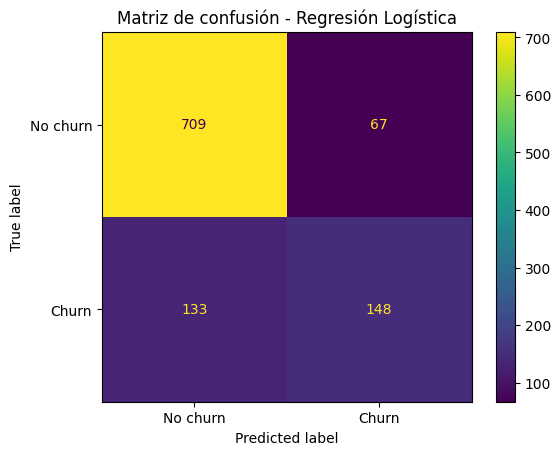

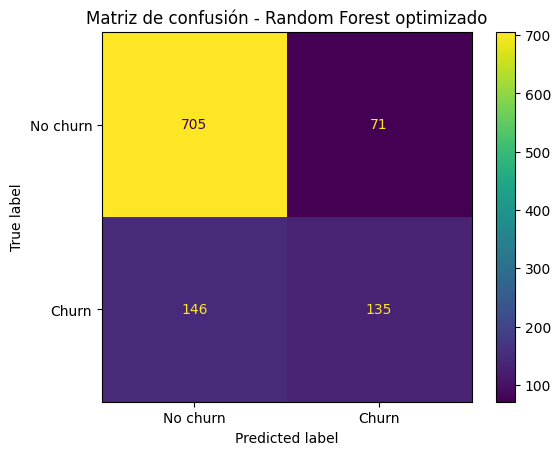

In [ ]:
for nombre, modelo in modelos_finalistas.items():

    y_pred = modelo.predict(X_test)

    cm = confusion_matrix(y_test, y_pred)

    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=["No churn", "Churn"]
    )

    disp.plot()
    plt.title(f"Matriz de confusión - {nombre}")
    plt.show()

Las matrices de confusión nos muestran, para cada modelo, la cantidad de verdaderos negativos, falsos positivos, falsos negativos y verdaderos positivos sobre el conjunto de prueba. Como vamos a confirmar más adelante en *Análisis de errores finales*, la Regresión Logística generó 67 falsos positivos y 133 falsos negativos; el Random Forest, al tener un Recall menor (0.4804 frente a 0.5267), deja sin detectar una proporción todavía mayor de clientes que sí abandonan. Visualmente, en ambas matrices la clase mayoritaria (no churn) se clasifica con menos errores que la clase minoritaria (churn), lo cual es esperable dado el desbalance del dataset (~73%/27%).

#### Curva ROC

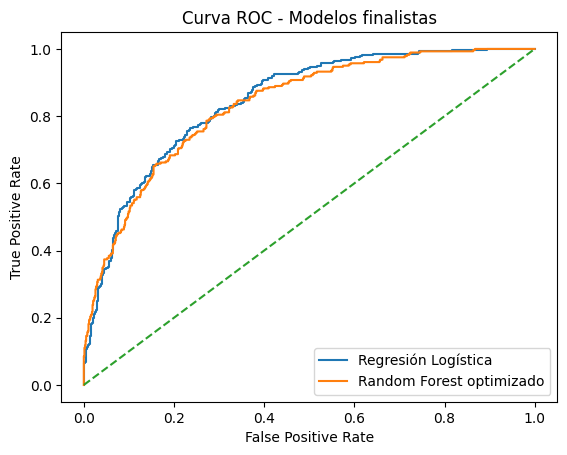

In [ ]:
plt.figure()

for nombre, modelo in modelos_finalistas.items():
    y_prob = modelo.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    plt.plot(fpr, tpr, label=nombre)

plt.plot([0, 1], [0, 1], linestyle="--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Curva ROC - Modelos finalistas")
plt.legend()
plt.show()

La curva ROC compara la tasa de verdaderos positivos contra la tasa de falsos positivos en distintos umbrales de decisión. Podemos ver que ambas curvas se ubican claramente por encima de la diagonal de referencia (clasificador aleatorio), confirmandonos que los dos modelos distinguen razonablemente bien entre clientes que abandonan y los que no. La Regresión Logística obtuvo un ROC-AUC de 0.8447 y el Random Forest optimizado de 0.8343 sobre prueba, por lo que sus curvas casi se superponen, con una ligera ventaja para la Regresión Logística en la mayor parte del rango.

#### Curva Precision-Recall

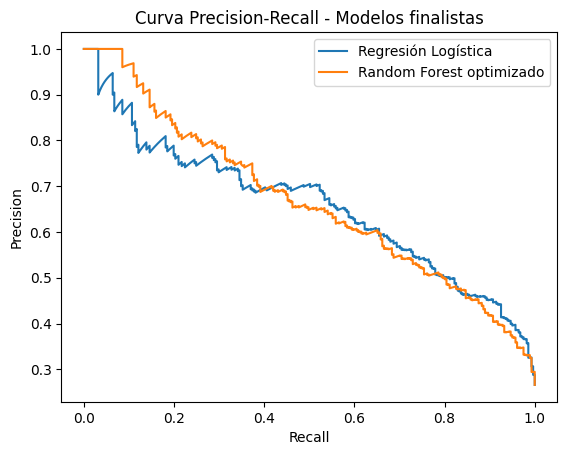

In [ ]:
plt.figure()

for nombre, modelo in modelos_finalistas.items():
    y_prob = modelo.predict_proba(X_test)[:, 1]
    precision, recall, _ = precision_recall_curve(y_test, y_prob)
    plt.plot(recall, precision, label=nombre)

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Curva Precision-Recall - Modelos finalistas")
plt.legend()
plt.show()

La curva Precision-Recall nos resulta más informativa que la ROC cuando hay desbalance de clases, como aquí (~27% de churn). Observamos que, a medida que exigimos mayor Recall (detectar a más clientes que abandonan), la Precision de ambos modelos disminuye, comportamiento que esperabamos. Las dos curvas se mantienen cercanas entre sí en la mayor parte del rango, siendo coherente con que sus valores de Precision (0.6884 vs 0.6553) y Recall (0.5267 vs 0.4804) en el punto de umbral 0.50 son similares.

## **Análisis de errores finales**

Para analizar los errores del modelo final revisamos las predicciones realizadas sobre el conjunto de prueba, identificando los falsos positivos y falsos negativos. Los falsos positivos corresponden a clientes que fueron clasificados como posibles casos de abandono cuando realmente no abandonaron, mientras que los falsos negativos corresponden a clientes que realmente abandonaron pero fueron clasificados como no abandono. Además, revisamos las probabilidades asignadas por el modelo y las principales características de los casos seleccionados, con el objetivo de identificar patrones en los errores. Este análisis nos permite conocer en qué situaciones el modelo presenta mayor dificultad y nos sirve como base para plantear posibles mejoras en la clasificación y en las acciones de retención de clientes.

In [ ]:
# Usamos el modelo final
modelo_final = modelo_logistico_final

# Obtenemos predicciones y probabilidades
y_pred_final = modelo_final.predict(X_test)
y_prob_final = modelo_final.predict_proba(X_test)[:, 1]


# Creamos una tabla con las predicciones
errores = X_test.copy()

errores["Clase real"] = y_test.values
errores["Predicción"] = y_pred_final
errores["Probabilidad"] = y_prob_final


# Identificamos falsos positivos y falsos negativos
falsos_positivos = errores[
    (errores["Clase real"] == 0) &
    (errores["Predicción"] == 1)
].copy()

falsos_negativos = errores[
    (errores["Clase real"] == 1) &
    (errores["Predicción"] == 0)
].copy()


print("Falsos positivos:", len(falsos_positivos))
print("Falsos negativos:", len(falsos_negativos))


# Características que vamos a mostrar
caracteristicas = [
    "tenure","MonthlyCharges",
    "TotalCharges","Contract",
    "InternetService","OnlineSecurity",
    "TechSupport","PaymentMethod",
    "TotalServices","ChargesPerTenure"
]

# Nos quedamos solamente con las que existan
caracteristicas = [
    col for col in caracteristicas
    if col in errores.columns
]


# Tomamos algunos casos representativos
fp_ejemplos = falsos_positivos.sort_values(
    "Probabilidad",
    ascending=False
).head(3)

fn_ejemplos = falsos_negativos.sort_values(
    "Probabilidad",
    ascending=True
).head(3)


# Agregamos el tipo de error
fp_ejemplos = fp_ejemplos.copy()
fn_ejemplos = fn_ejemplos.copy()

fp_ejemplos["Tipo de error"] = "Falso positivo"
fn_ejemplos["Tipo de error"] = "Falso negativo"


# Unimos los ejemplos
ejemplos_error = pd.concat([
    fp_ejemplos,
    fn_ejemplos
])


columnas_mostrar = [
    "Clase real",
    "Predicción",
    "Probabilidad",
    "Tipo de error"
] + caracteristicas

display(ejemplos_error[columnas_mostrar].round(4))

Falsos positivos: 67
Falsos negativos: 133


,Clase real,Predicción,Probabilidad,Tipo de error,tenure,MonthlyCharges,TotalCharges,Contract,InternetService,OnlineSecurity,TechSupport,PaymentMethod
352,0,1,0.7756,Falso positivo,7,89.15,574.35,Month-to-month,Fiber optic,No,No,Electronic check
5627,0,1,0.7488,Falso positivo,7,74.85,485.25,Month-to-month,Fiber optic,No,No,Electronic check
4077,0,1,0.7439,Falso positivo,14,95.80,1346.30,Month-to-month,Fiber optic,No,No,Electronic check
5441,1,0,0.0071,Falso negativo,70,65.30,4759.75,Two year,DSL,Yes,Yes,Credit card (automatic)
430,1,0,0.0153,Falso negativo,61,19.40,1182.55,Month-to-month,No,No internet service,No internet service,Mailed check
2894,1,0,0.0273,Falso negativo,48,60.35,2896.40,One year,DSL,Yes,Yes,Credit card (automatic)


## **Optimización de umbral decisión**

Antes de fijar el umbral operativo definitivo, exploramos cómo cambian Precision, Recall, F1-score y la cantidad de falsos positivos/negativos del modelo final (Regresión Logística) al mover el umbral de clasificación entre 0.30 y 0.70, sobre el conjunto de prueba.

In [ ]:
from sklearn.metrics import precision_score, recall_score, f1_score, confusion_matrix

# Probabilidades del modelo final
y_prob = modelo_final.predict_proba(X_test)[:, 1]

# Umbrales que vamos a probar
umbrales = [0.30, 0.40, 0.50, 0.60, 0.70]

resultados_umbrales = []

for umbral in umbrales:
    # Cambiamos la probabilidad por una predicción
    y_pred_umbral = (y_prob >= umbral).astype(int)

    # Matriz de confusión
    tn, fp, fn, tp = confusion_matrix(
        y_test,
        y_pred_umbral
    ).ravel()

    resultados_umbrales.append({
        "Umbral": umbral,
        "Precision": precision_score(y_test, y_pred_umbral),
        "Recall": recall_score(y_test, y_pred_umbral),
        "F1-score": f1_score(y_test, y_pred_umbral),
        "Falsos positivos": fp,
        "Falsos negativos": fn
    })

tabla_umbrales = pd.DataFrame(resultados_umbrales)

display(tabla_umbrales.round(4))

,Umbral,Precision,Recall,F1-score,Falsos positivos,Falsos negativos
0,0.3,0.5429,0.7438,0.6276,176,72
1,0.4,0.5935,0.6548,0.6227,126,97
2,0.5,0.6884,0.5267,0.5968,67,133
3,0.6,0.7185,0.3452,0.4663,38,184
4,0.7,0.8065,0.1779,0.2915,12,231


Podemos ver que al reducir el umbral de 0.50 a 0.30, el Recall sube de 0.5267 a 0.7438 (detectamos más clientes que realmente abandonan) y los falsos negativos bajan de 133 a 72, pero la Precision cae de 0.6884 a 0.5429 y los falsos positivos suben de 67 a 176. En el extremo opuesto, con umbral 0.70 la Precision alcanza 0.8065 pero el Recall se desploma a 0.1779, dejando pasar 231 falsos negativos. De los cinco umbrales que probamos, 0.30 es el que produce el mayor F1-score (0.6276), equilibrando mejor ambos tipos de error.

In [ ]:
# Seleccionamos el umbral operativo
umbral_operativo = 0.30

resultado_umbral = tabla_umbrales[
    tabla_umbrales["Umbral"] == umbral_operativo
]

display(resultado_umbral)

,Umbral,Precision,Recall,F1-score,Falsos positivos,Falsos negativos
0,0.3,0.542857,0.743772,0.627628,176,72


Esta celda aísla, de la tabla anterior, la fila del umbral 0.30 (Precision 0.5429, Recall 0.7438, F1-score 0.6276, 176 falsos positivos y 72 falsos negativos), dejandonos explícitos los valores que vamos a usar como referencia para el umbral operativo del modelo.

In [ ]:
# Aplicamos el umbral seleccionado
y_pred_umbral = (y_prob >= umbral_operativo).astype(int)

print(f"Umbral seleccionado: {umbral_operativo}")
print("Predicciones generadas con el nuevo umbral.")

Umbral seleccionado: 0.3
Predicciones generadas con el nuevo umbral.


El mensaje nos confirma que las predicciones (y_pred_umbral) se regeneraron aplicando el umbral operativo de 0.30 en lugar del umbral por defecto de 0.50 que usa predict(). De aquí en adelante, cualquier clasificación del modelo final la debemos hacer comparando la probabilidad estimada contra 0.30.

Se evaluaron diferentes umbrales de clasificación para observar cómo cambia el comportamiento del modelo. Se probaron valores entre 0.30 y 0.70 y se compararon Precision, Recall, F1-score, falsos positivos y falsos negativos. El umbral de 0.30 obtuvo el mayor F1-score (0.6276) y el mayor Recall (0.7438), por lo que se seleccionó como umbral operativo para priorizar la detección de clientes con posible abandono. Este cambio aumenta la cantidad de casos detectados, aunque también genera un mayor número de falsos positivos. Por ello, el umbral debe considerarse como una decisión operativa que tendría que validarse con el contexto y los costos reales de la organización.

## **Selección del modelo final**

Después de comparar los modelos finalistas y evaluar su desempeño sobre el conjunto de prueba, se seleccionó la Regresión Logística como modelo final. La decisión no se basó únicamente en una métrica, sino que también consideró su desempeño en prueba, generalización respecto a la validación, análisis de errores, interpretabilidad, complejidad y facilidad de operación. Para la clasificación se definió un umbral operativo de 0.30, priorizando la detección de posibles casos de churn mediante un mayor Recall, por lo que a continuación presentamos el desempeño del modelo bajo ambos umbrales: el umbral por defecto (0.50), solo como referencia, y el umbral operativo (0.30), que es el que realmente describe cómo va a funcionar el modelo en la práctica. La solución debe considerarse como una herramienta de apoyo y requiere monitoreo y revisión antes de utilizarse en un entorno real.

In [ ]:
# Modelo seleccionado para la solución final
modelo_final = modelo_logistico_final

# Predicciones bajo ambos umbrales
y_pred_050 = (y_prob >= 0.50).astype(int)
y_pred_030 = (y_prob >= umbral_operativo).astype(int)

# Resultados finales del modelo
resultados_modelo_final = pd.DataFrame([
    {
        "Umbral": "0.50 (referencia)",
        "Accuracy": accuracy_score(y_test, y_pred_050),
        "Precision": precision_score(y_test, y_pred_050),
        "Recall": recall_score(y_test, y_pred_050),
        "F1-score": f1_score(y_test, y_pred_050),
        "ROC-AUC": roc_auc_score(y_test, y_prob)
    },
    {
        "Umbral": f"{umbral_operativo} (operativo)",
        "Accuracy": accuracy_score(y_test, y_pred_030),
        "Precision": precision_score(y_test, y_pred_030),
        "Recall": recall_score(y_test, y_pred_030),
        "F1-score": f1_score(y_test, y_pred_030),
        "ROC-AUC": roc_auc_score(y_test, y_prob)
    }
])

display(resultados_modelo_final.round(4))

,Umbral,Accuracy,Precision,Recall,F1-score,ROC-AUC
0,0.50 (referencia),0.8108,0.6884,0.5267,0.5968,0.8447
1,0.3 (operativo),0.7654,0.5429,0.7438,0.6276,0.8447


La tabla compara el desempeño del modelo final (Regresión Logística) bajo dos umbrales distintos sobre el conjunto de prueba. Con el umbral por defecto (0.50) se obtiene Accuracy 0.8108, Precision 0.6884, Recall 0.5267, F1-score 0.5968 y ROC-AUC 0.8447; sin embargo, este umbral no es el que finalmente decidimos usar. Con el umbral operativo (0.30), que sí es el que va a operar el modelo, el Accuracy baja a aproximadamente 0.7654 y la Precision a 0.5429, pero el Recall sube a 0.7438 y el F1-score a 0.6276 — es decir, el modelo detecta una proporción notablemente mayor de clientes que realmente abandonan, a cambio de una Precision menor. El ROC-AUC se mantiene igual en ambos casos (0.8447), ya que esta métrica evalúa al modelo en todos los umbrales posibles a la vez y no depende de dónde se coloque el punto de corte. De aquí en adelante, cualquier referencia al "desempeño del modelo final" en las secciones posteriores (ficha del modelo, reporte y monitoreo) debe entenderse bajo el umbral operativo de 0.30, no bajo el umbral por defecto

In [ ]:
# Evidencia para seleccionar el modelo final
criterios_modelo = pd.DataFrame({
    "Criterio": [
        "Desempeño",
        "Generalización",
        "Errores",
        "Interpretabilidad",
        "Complejidad",
        "Operación",
        "Riesgo"
    ],
    "Evidencia": [
        "Accuracy 0.7654, Recall 0.7438 y F1 0.6276 en prueba con el umbral operativo (0.30); ROC-AUC 0.8447",
        "Resultados de prueba similares a los obtenidos durante validación",
        "Se analizaron falsos positivos y falsos negativos",
        "Los coeficientes permiten interpretar las variables",
        "Modelo más sencillo que Random Forest",
        "Entrenamiento e inferencia de bajo costo computacional",
        "El umbral puede generar más falsos positivos y requiere monitoreo"
    ],
    "Conclusión": [
        "Buen desempeño en el conjunto de prueba",
        "Resultados consistentes respecto a la validación",
        "Errores analizados mediante falsos positivos y negativos",
        "Alta interpretabilidad",
        "Modelo de menor complejidad",
        "Fácil de entrenar y utilizar",
        "Requiere monitoreo antes de uso real"
    ]
})

display(criterios_modelo)

,Criterio,Evidencia,Conclusión
0,Desempeño,"Accuracy 0.8108, F1 0.5968 y ROC-AUC 0.8447 en prueba",Buen desempeño en el conjunto de prueba
1,Generalización,Resultados de prueba similares a los obtenidos durante validación,Resultados consistentes respecto a la validación
2,Errores,Se analizaron falsos positivos y falsos negativos,Errores analizados mediante falsos positivos y negativos
3,Interpretabilidad,Los coeficientes permiten interpretar las variables,Alta interpretabilidad
4,Complejidad,Modelo más sencillo que Random Forest,Modelo de menor complejidad
5,Operación,Entrenamiento e inferencia de bajo costo computacional,Fácil de entrenar y utilizar
6,Riesgo,El umbral puede generar más falsos positivos y requiere monitoreo,Requiere monitoreo antes de uso real


Esta tabla ayuda a  evidenciar que respalda cada conclusión con datos concretos del proyecto. En el caso de Desempeño, la evidencia ya refleja las cifras bajo el umbral operativo (0.30) y no bajo el umbral por defecto: Accuracy 0.7654, Recall 0.7438 y F1-score 0.6276, junto con un ROC-AUC de 0.8447 que se mantiene igual en ambos umbrales por ser una métrica independiente del punto de corte. Consideramos importante que esta evidencia coincida con el umbral que realmente se va a usar en la práctica, ya que de lo contrario estaríamos justificando la elección del modelo final con números que no corresponden a cómo va a operar. Al unir evidencia y conclusión para los siete criterios, esta tabla nos funciona como una justificación trazable de la decisión, útil para explicarle la elección a personas no técnicas sin que tengan que revisar las tablas de umbral por su cuenta.

In [ ]:
# Modelo seleccionado
modelo_final = modelo_logistico_final

print("Modelo final: Regresión Logística")
print(f"Umbral operativo: {umbral_operativo}")

Modelo final: Regresión Logística
Umbral operativo: 0.3


El mensaje impreso nos confirma de forma explícita las dos decisiones clave que tomamos hasta este punto: el modelo final es la Regresión Logística y el umbral operativo con el que lo debemos usar es 0.30. Funciona como punto de control antes de pasar a la interpretación del modelo.

## **Interpretación del modelo globalmente**

Para interpretar globalmente el modelo final analizamos los coeficientes obtenidos por la Regresión Logística. Construimos un ranking de variables utilizando el valor absoluto de los coeficientes, lo que nos permite identificar cuáles tienen mayor influencia en las predicciones. Además, revisamos el signo de cada coeficiente para determinar si la variable se relaciona con un aumento o una disminución en la probabilidad estimada de churn. Finalmente, generamos una visualización con las variables más importantes para facilitar la interpretación de los resultados. Es importante considerar que la influencia de una variable en el modelo no implica causalidad, sino que representa la relación que el modelo utiliza para realizar sus predicciones.

In [ ]:
# Obtenemos el modelo de regresión logística
modelo_lr = modelo_final

# Sacamos el preprocesador y el modelo
preprocesador = modelo_lr.named_steps["preprocesador"]
modelo = modelo_lr.named_steps["model"]

# Obtenemos los nombres de las variables después del preprocesamiento
nombres_variables = preprocesador.get_feature_names_out()

# Obtenemos los coeficientes
coeficientes = modelo.coef_[0]

# Creamos el ranking
importancias = pd.DataFrame({
    "Variable": nombres_variables,
    "Coeficiente": coeficientes,
    "Importancia": abs(coeficientes)
})

# Ordenamos de mayor a menor importancia
importancias = importancias.sort_values(
    "Importancia",
    ascending=False
)

# Mostramos las 15 variables principales
display(importancias.head(15))

,Variable,Coeficiente,Importancia
0,num__tenure,-1.297628,1.297628
39,cat__Contract_Two year,-0.728291,0.728291
2,num__TotalCharges,0.616892,0.616892
37,cat__Contract_Month-to-month,0.590649,0.590649
16,cat__InternetService_DSL,-0.526852,0.526852
17,cat__InternetService_Fiber optic,0.504729,0.504729
1,num__MonthlyCharges,-0.420912,0.420912
40,cat__PaperlessBilling_No,-0.346635,0.346635
10,cat__Dependents_Yes,-0.274135,0.274135
26,cat__DeviceProtection_No internet service,-0.260877,0.260877


La tabla nos muestra las 15 variables (ya transformadas por el preprocesador: escaladas si son numéricas, codificadas con one-hot si son categóricas) con mayor valor absoluto de coeficiente en la Regresión Logística. La más influyente es tenure, con coeficiente -1.2976, seguida por Contract_Two year (-0.7283) y TotalCharges (0.6169). El signo negativo de tenure nos indica que, a mayor antigüedad, menor la probabilidad estimada de abandono; el signo positivo de TotalCharges y de Contract_Month-to-month nos indica la relación contraria.

### *Visualización de importancia*

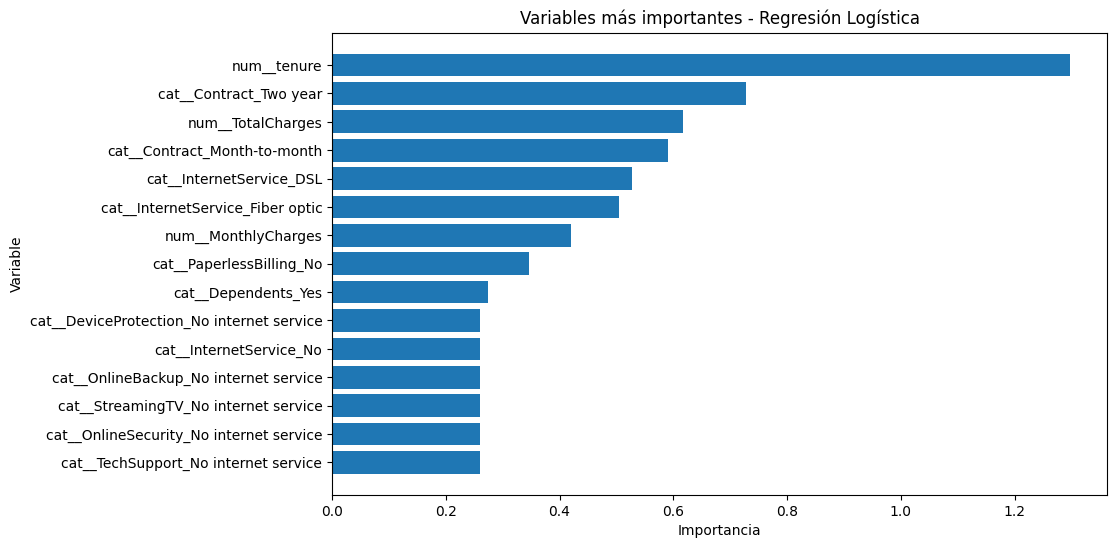

In [ ]:
# Tomamos las 15 variables más importantes
top_variables = importancias.head(15).sort_values(
    "Importancia"
)

plt.figure(figsize=(10, 6))

plt.barh(
    top_variables["Variable"],
    top_variables["Importancia"]
)

plt.xlabel("Importancia")
plt.ylabel("Variable")
plt.title("Variables más importantes - Regresión Logística")
plt.show()

El gráfico de barras horizontales visualiza la misma información de la tabla anterior, ordenando las 15 variables más importantes de menor a mayor magnitud de coeficiente. Podemos confirmar visualmente que tenure domina sobre el resto de variables, seguida por un grupo relacionado con el tipo de contrato y el servicio de Internet, mientras que el resto tiene una influencia notablemente menor.

### *Dirección de la influencia*

In [ ]:
# Agregamos la dirección de la influencia
top_variables = importancias.head(15).copy()

top_variables["Influencia"] = top_variables["Coeficiente"].apply(
    lambda x: "Aumenta probabilidad de churn" if x > 0
    else "Disminuye probabilidad de churn"
)

display(top_variables[["Variable", "Coeficiente", "Importancia", "Influencia"]])

,Variable,Coeficiente,Importancia,Influencia
0,num__tenure,-1.297628,1.297628,Disminuye probabilidad de churn
39,cat__Contract_Two year,-0.728291,0.728291,Disminuye probabilidad de churn
2,num__TotalCharges,0.616892,0.616892,Aumenta probabilidad de churn
37,cat__Contract_Month-to-month,0.590649,0.590649,Aumenta probabilidad de churn
16,cat__InternetService_DSL,-0.526852,0.526852,Disminuye probabilidad de churn
17,cat__InternetService_Fiber optic,0.504729,0.504729,Aumenta probabilidad de churn
1,num__MonthlyCharges,-0.420912,0.420912,Disminuye probabilidad de churn
40,cat__PaperlessBilling_No,-0.346635,0.346635,Disminuye probabilidad de churn
10,cat__Dependents_Yes,-0.274135,0.274135,Disminuye probabilidad de churn
26,cat__DeviceProtection_No internet service,-0.260877,0.260877,Disminuye probabilidad de churn


Al agregar la columna *Influencia*, traducimos el signo de cada coeficiente a un lenguaje interpretable: tenure, Contract_Two year, InternetService_DSL y MonthlyCharges disminuyen la probabilidad de churn, mientras que TotalCharges, Contract_Month-to-month e InternetService_Fiber optic la aumentan. Esto es coherente con la intuición de negocio: clientes con más antigüedad y contratos largos son más estables, mientras que los contratos mes a mes y la fibra óptica (generalmente más cara) se asocian con mayor riesgo de abandono.

### *Ranking completo de variables*

In [ ]:
# Ranking completo de variables
ranking_variables = importancias[
    ["Variable", "Coeficiente", "Importancia"]
].reset_index(drop=True)

ranking_variables.index = ranking_variables.index + 1

display(ranking_variables)

,Variable,Coeficiente,Importancia
1,num__tenure,-1.297628,1.297628
2,cat__Contract_Two year,-0.728291,0.728291
3,num__TotalCharges,0.616892,0.616892
4,cat__Contract_Month-to-month,0.590649,0.590649
5,cat__InternetService_DSL,-0.526852,0.526852
6,cat__InternetService_Fiber optic,0.504729,0.504729
7,num__MonthlyCharges,-0.420912,0.420912
8,cat__PaperlessBilling_No,-0.346635,0.346635
9,cat__Dependents_Yes,-0.274135,0.274135
10,cat__DeviceProtection_No internet service,-0.260877,0.260877


El ranking completo (46 variables, correspondientes a las columnas resultantes del one-hot encoding) nos muestra que la importancia decae rápidamente: mientras tenure tiene importancia 1.2976, las últimas variables del ranking (como DeviceProtection_Yes o Dependents_No) tienen coeficientes cercanos a 0.01, practicamente sin efecto en la predicción. Esto nos sugiere que un subconjunto reducido de variables concentra la mayor parte del poder predictivo del modelo, en línea con lo que ya habíamos encontrado en la sección de selección de características.

### *Limitaciones del método utilizado.*

Aunque los coeficientes de la Regresión Logística nos permitieron construir un ranking de variables relativamente simple de interpretar, es importante reconocer las limitaciones de este método antes de tomarlo como una explicación completa del comportamiento del modelo.

- **Solo captura relaciones lineales y aditivas.** Los coeficientes describen cómo cambia el logaritmo de las probabilidades (log-odds) de churn ante un cambio en una variable, manteniendo las demás constantes. Si existiera alguna relación no lineal entre una variable y el abandono (por ejemplo, que el riesgo aumente solo después de cierto monto de cargos), el modelo lineal no podría representarla y el coeficiente terminaría siendo un promedio poco fiel de ese comportamiento.
- **No captura interacciones entre variables.** El modelo asume que el efecto de cada variable es independiente del valor de las demás. En la realidad es posible que, por ejemplo, un contrato mes a mes sea especialmente riesgoso solo cuando se combina con tenure bajo, pero la Regresión Logística sin términos de interacción no puede diferenciar ese matiz.
- **Los coeficientes quedan repartidos entre categorías correlacionadas (multicolinealidad del One-Hot Encoding).** Cuando una variable categórica se convierte en varias columnas dummy (por ejemplo, las categorías de InternetService), su efecto real puede repartirse entre esas columnas de forma poco intuitiva si existe correlación entre ellas, dificultando saber con precisión cuánto corresponde a cada categoría de forma aislada.
- **La escala de las variables numéricas afecta la comparación.** Gracias al StandardScaler, tenure, MonthlyCharges y TotalCharges se llevaron a una misma escala antes de calcular los coeficientes, lo que nos permite comparar su magnitud entre sí; si ese escalamiento no se hubiera aplicado, los coeficientes de variables con rangos numéricos más grandes se hubieran visto artificialmente reducidos frente a los de variables ya en una escala pequeña.
- **No implica causalidad.** Que tenure tenga el coeficiente más grande no significa que "hacer que un cliente dure más" cause, por sí mismo, una menor probabilidad de abandono; la variable podría estar correlacionada con otros factores no observados (por ejemplo, la satisfacción general del cliente) que son los que realmente explican el comportamiento.
- **No hay una medida de incertidumbre asociada.** No calculamos intervalos de confianza ni valores p para los coeficientes, por lo que no podemos afirmar con rigor estadístico qué tan seguros estamos de la magnitud exacta de cada uno, solo de su signo y de su orden relativo dentro del ranking.
- **Es específica de este modelo y de este periodo de datos.** Esta interpretación corresponde únicamente a la Regresión Logística entrenada con el dataset de este proyecto; si se reentrena el modelo con datos más recientes, con otro pipeline o con otra semilla, el ranking podría cambiar, sobre todo entre las variables con importancia intermedia.

Dado que no aplicamos técnicas adicionales como SHAP o permutation importance para contrastar estos resultados, esta interpretación global debe tomarse como una primera aproximación basada exclusivamente en los coeficientes del modelo, útil para identificar tendencias generales, pero no como una explicación definitiva y libre de matices del comportamiento del modelo.

## **Explicación de predicciones individuales**

Para explicar las predicciones individuales seleccionamos un caso de cada tipo: verdadero positivo, verdadero negativo, falso positivo y falso negativo. Utilizamos las contribuciones de los coeficientes de la Regresión Logística como método de interpretación local.

In [ ]:
# Predicciones del modelo final
y_pred = modelo_final.predict(X_test)
y_prob = modelo_final.predict_proba(X_test)[:, 1]

# Identificamos los cuatro tipos de casos
tp = np.where((y_test.values == 1) & (y_pred == 1))[0]
tn = np.where((y_test.values == 0) & (y_pred == 0))[0]
fp = np.where((y_test.values == 0) & (y_pred == 1))[0]
fn = np.where((y_test.values == 1) & (y_pred == 0))[0]

# Elegimos casos representativos
casos = {
    "Verdadero positivo": tp[np.argmax(y_prob[tp])],
    "Verdadero negativo": tn[np.argmin(y_prob[tn])],
    "Falso positivo": fp[np.argmax(y_prob[fp])],
    "Falso negativo": fn[np.argmin(y_prob[fn])]
}

print(casos)

{'Verdadero positivo': np.int64(474), 'Verdadero negativo': np.int64(989), 'Falso positivo': np.int64(972), 'Falso negativo': np.int64(663)}


Identificamos, dentro del conjunto de prueba, los índices de un caso representativo de cada uno de los cuatro resultados posibles de clasificación: verdadero positivo (índice 474), verdadero negativo (índice 989), falso positivo (índice 972) y falso negativo (índice 663). En cada categoría elegimos el caso más "extremo" (mayor probabilidad para los positivos, menor para los negativos), para que las explicaciones posteriores nos queden lo más claras posible.

In [ ]:
# Sacamos el preprocesador y el modelo
preprocesador = modelo_final.named_steps["preprocesador"]
modelo = modelo_final.named_steps["model"]

# Transformamos los datos de prueba
X_test_transformado = preprocesador.transform(X_test)

# Convertimos a matriz normal si es necesario
if hasattr(X_test_transformado, "toarray"):
    X_test_transformado = X_test_transformado.toarray()

# Nombres de las variables después del preprocesamiento
nombres_variables = preprocesador.get_feature_names_out()

# Coeficientes del modelo
coeficientes = modelo.coef_[0]

# Calculamos la contribución de cada variable
contribuciones = X_test_transformado * coeficientes

Esta celda no nos genera una salida visible porque su función es preparatoria: transforma X_test con el mismo preprocesador que usamos en el entrenamiento y multiplica cada valor transformado por su coeficiente correspondiente, obteniendo la *contribución* individual de cada variable a la probabilidad estimada de cada cliente. Esta matriz de contribuciones es la base del análisis local que mostramos en la celda siguiente.

In [ ]:
# Mostramos las contribuciones de cada caso
for tipo, indice in casos.items():

    ranking = pd.DataFrame({
        "Variable": nombres_variables,
        "Contribución": contribuciones[indice]
    })

    ranking["Importancia"] = abs(ranking["Contribución"])

    ranking = ranking.sort_values(
        "Importancia",
        ascending=False
    ).head(5)

    print(f"\n{tipo}")
    print(f"Probabilidad de churn: {y_prob[indice]:.4f}")

    display(ranking.round(4))


Verdadero positivo
Probabilidad de churn: 0.8476


,Variable,Contribución,Importancia
0,num__tenure,1.6571,1.6571
2,num__TotalCharges,-0.5947,0.5947
37,cat__Contract_Month-to-month,0.5906,0.5906
17,cat__InternetService_Fiber optic,0.5047,0.5047
1,num__MonthlyCharges,-0.4197,0.4197



Verdadero negativo
Probabilidad de churn: 0.0015


,Variable,Contribución,Importancia
0,num__tenure,-2.0814,2.0814
39,cat__Contract_Two year,-0.7283,0.7283
1,num__MonthlyCharges,0.6263,0.6263
40,cat__PaperlessBilling_No,-0.3466,0.3466
10,cat__Dependents_Yes,-0.2741,0.2741



Falso positivo
Probabilidad de churn: 0.7756


,Variable,Contribución,Importancia
0,num__tenure,1.3412,1.3412
37,cat__Contract_Month-to-month,0.5906,0.5906
17,cat__InternetService_Fiber optic,0.5047,0.5047
2,num__TotalCharges,-0.4657,0.4657
1,num__MonthlyCharges,-0.3368,0.3368



Falso negativo
Probabilidad de churn: 0.0071


,Variable,Contribución,Importancia
0,num__tenure,-1.9761,1.9761
39,cat__Contract_Two year,-0.7283,0.7283
2,num__TotalCharges,0.6613,0.6613
16,cat__InternetService_DSL,-0.5269,0.5269
40,cat__PaperlessBilling_No,-0.3466,0.3466


Para cada uno de los cuatro casos listamos las 5 variables con mayor contribución (positiva o negativa) a la probabilidad final. En el verdadero positivo (probabilidad 0.8476), tenure aporta +1.6571 hacia churn, mientras que TotalCharges resta -0.5947. En el verdadero negativo (probabilidad 0.0015), tenure aporta -2.0814, empujando fuertemente hacia "no churn". El falso positivo (probabilidad 0.7756) se explica por un patrón similar al verdadero positivo (tenure bajo, contrato mensual, fibra óptica): el cliente presentaba las mismas señales de riesgo que uno que sí abandona. El falso negativo (probabilidad 0.0071) se explica por la fuerte contribución negativa de tenure (-1.9761) y del contrato a dos años (-0.7283), pese a que el cliente sí abandonó.

In [ ]:
# Tabla de predicciones individuales
tabla_casos = pd.DataFrame({
    "Caso": [
        "Verdadero positivo",
        "Verdadero negativo",
        "Falso positivo",
        "Falso negativo"
    ],
    "Resultado real": [1, 0, 0, 1],
    "Predicción": [1, 0, 1, 0],
    "Probabilidad": [0.8476, 0.0015, 0.7756, 0.0071],
    "Factores principales": [
        "tenure, contrato mensual, fibra óptica",
        "tenure, contrato de 2 años, MonthlyCharges",
        "tenure, contrato mensual, fibra óptica",
        "tenure, contrato de 2 años, DSL"
    ],
    "Interpretación": [
        "Las variables principales llevaron correctamente la predicción hacia churn.",
        "Las variables principales llevaron correctamente la predicción hacia no churn.",
        "El modelo predijo churn, aunque el cliente realmente no abandonó.",
        "El modelo predijo no churn, aunque el cliente realmente abandonó."
    ]
})

display(tabla_casos)

,Caso,Resultado real,Predicción,Probabilidad,Factores principales,Interpretación
0,Verdadero positivo,1,1,0.8476,"tenure, contrato mensual, fibra óptica",Las variables principales llevaron correctamente la predicción hacia churn.
1,Verdadero negativo,0,0,0.0015,"tenure, contrato de 2 años, MonthlyCharges",Las variables principales llevaron correctamente la predicción hacia no churn.
2,Falso positivo,0,1,0.7756,"tenure, contrato mensual, fibra óptica","El modelo predijo churn, aunque el cliente realmente no abandonó."
3,Falso negativo,1,0,0.0071,"tenure, contrato de 2 años, DSL","El modelo predijo no churn, aunque el cliente realmente abandonó."


La tabla consolida los cuatro casos anteriores en un formato resumido y legible, con el resultado real, la predicción, la probabilidad estimada y una interpretación en lenguaje simple. Nos es útil como material de apoyo para explicarle a personas no técnicas cómo se comporta el modelo en ejemplos concretos, más allá de las métricas agregadas.

En los casos analizados, la variable tenure presentó algunas de las contribuciones más importantes, junto con el tipo de contrato y el servicio de Internet. En el verdadero positivo, las contribuciones de tenure, el contrato mensual y el servicio de fibra óptica llevaron al modelo hacia la predicción de churn. En el verdadero negativo, la antigüedad y el contrato de dos años contribuyeron principalmente hacia la clase de no abandono. En el falso positivo, el contrato mensual y la fibra óptica llevaron al modelo a estimar una probabilidad de churn de 0.7756, aunque el cliente realmente no abandonó. Finalmente, en el falso negativo, las contribuciones negativas de tenure y el contrato de dos años hicieron que el modelo estimara una probabilidad de churn muy baja, de 0.0071, a pesar de que el cliente sí abandonó. Este análisis nos permite comprender cómo influyeron las variables en cada predicción, pero no debe utilizarse como una justificación automática de decisiones sobre los clientes.

## **Evaluación de posibles sesgos entre grupos**


En esta sección analizamos si el comportamiento del modelo presenta diferencias entre distintos grupos de clientes. Para ello comparamos grupos definidos por el tipo de contrato, utilizando métricas como tamaño del grupo, tasa de abandono, recall, precision, tasa de falsos positivos (FPR) y tasa de falsos negativos (FNR).

Las diferencias que observamos no las interpretamos automáticamente como discriminación, ya que pueden estar relacionadas con la distribución de los datos, las características de los clientes y el comportamiento histórico registrado en el dataset.

In [ ]:
from sklearn.metrics import confusion_matrix, precision_score, recall_score

# Utilizamos el modelo final y el umbral operativo definido anteriormente
modelo_sesgo = modelo_final

# Probabilidades sobre el conjunto de prueba
y_prob_sesgo = modelo_sesgo.predict_proba(X_test)[:, 1]

# Aplicamos el umbral operativo
y_pred_sesgo = (y_prob_sesgo >= umbral_operativo).astype(int)

# Copiamos los datos de prueba
datos_sesgo = X_test.copy()

datos_sesgo["Churn_real"] = y_test.values
datos_sesgo["Probabilidad"] = y_prob_sesgo
datos_sesgo["Prediccion"] = y_pred_sesgo

# Función para calcular métricas por grupo
def calcular_metricas_grupo(datos, columna_grupo, grupo):

    grupo_data = datos[datos[columna_grupo] == grupo]
    y_real = grupo_data["Churn_real"]
    y_pred = grupo_data["Prediccion"]

    tn, fp, fn, tp = confusion_matrix(y_real,y_pred,labels=[0, 1]).ravel()

    recall = recall_score(y_real,y_pred,zero_division=0)

    precision = precision_score(y_real,y_pred,zero_division=0)

    fpr = fp / (fp + tn) if (fp + tn) > 0 else 0
    fnr = fn / (fn + tp) if (fn + tp) > 0 else 0

    return {
        "Grupo": grupo,
        "Tamaño": len(grupo_data),
        "Tasa de abandono": y_real.mean(),
        "Tasa predicción positiva": y_pred.mean(),
        "Recall": recall,
        "Precision": precision,
        "FPR": fpr,
        "FNR": fnr
    }

# Grupos que vamos a comparar
grupos_contrato = datos_sesgo["Contract"].dropna().unique()

resultados_sesgo = []
for grupo in grupos_contrato:
    resultados_sesgo.append(
        calcular_metricas_grupo(
            datos_sesgo,
            "Contract",
            grupo
        )
    )

tabla_sesgo = pd.DataFrame(resultados_sesgo)

display(tabla_sesgo.round(4))

,Grupo,Tamaño,Tasa de abandono,Tasa predicción positiva,Recall,Precision,FPR,FNR
0,Month-to-month,572,0.4248,0.6469,0.8395,0.5514,0.5046,0.1605
1,One year,229,0.1441,0.0655,0.1515,0.3333,0.0510,0.8485
2,Two year,256,0.0195,0.0000,0.0000,0.0000,0.0000,1.0000


Podemos intepretar que las métricas nos muestran diferencias entre los grupos de tipo de contrato. Siendi estas diferencias las que debemos interpretar considerando que los grupos pueden tener tamaños y tasas de abandono diferentes; que por parte del análisis se nos permite identificar posibles diferencias en el comportamiento del modelo, especialmente en Recall, FPR y FNR. Sin embargo, una diferencia estadística entre grupos no demuestra por sí misma la existencia de discriminación.

Como medida de revisión, recomendariamos monitorear estas métricas durante el uso del modelo y analizar si las diferencias se mantienen a lo largo del tiempo.

## **Riesgos y condiciones de uso del modelo**

### *Riesgos*

En esta sección documentamos los principales riesgos asociados con el uso del modelo de predicción de abandono. Consideramos errores de clasificación, cambios en los datos, información incompleta, uso automático de las predicciones y posibles diferencias entre grupos.

Nuestro objetivo es establecer medidas de mitigación y condiciones para utilizar el modelo como herramienta de apoyo y no como mecanismo de decisión automática.

In [ ]:
riesgos = pd.DataFrame([
    [
        "Falsos negativos",
        "El modelo clasifica como no abandono a un cliente que realmente abandona.",
        "Se puede perder una oportunidad de retención.",
        "Media",
        "Alto",
        "Monitorear Recall y FNR; revisar periódicamente el umbral."
    ],
    [
        "Falsos positivos",
        "El modelo identifica como riesgo a un cliente que realmente permanece.",
        "Se pueden utilizar recursos de retención innecesariamente.",
        "Alta",
        "Medio",
        "Monitorear Precision y FPR y ajustar el umbral según el contexto."
    ],
    [
        "Data drift",
        "Las características de nuevos clientes pueden cambiar respecto al dataset histórico.",
        "El desempeño del modelo puede disminuir.",
        "Media",
        "Alto",
        "Monitorear distribución de variables y desempeño."
    ],
    [
        "Datos incompletos",
        "Un registro nuevo puede contener campos faltantes o información incorrecta.",
        "La predicción puede ser menos confiable o no poder realizarse.",
        "Media",
        "Alto",
        "Validar los datos antes de realizar la inferencia."
    ],
    [
        "Uso automático",
        "Utilizar la predicción como una decisión definitiva.",
        "Se pueden tomar acciones incorrectas sin revisión.",
        "Media",
        "Alto",
        "Mantener revisión humana antes de realizar acciones sobre clientes."
    ],
    [
        "Diferencias entre grupos",
        "El desempeño puede variar entre diferentes segmentos de clientes.",
        "Algunos grupos podrían recibir predicciones con mayor tasa de error.",
        "Media",
        "Medio",
        "Monitorear métricas por grupo y revisar diferencias."
    ]
], columns=[
    "Riesgo",
    "Causa",
    "Consecuencia",
    "Probabilidad",
    "Impacto",
    "Mitigación"
])

display(riesgos)

,Riesgo,Causa,Consecuencia,Probabilidad,Impacto,Mitigación
0,Falsos negativos,El modelo clasifica como no abandono a un cliente que realmente abandona.,Se puede perder una oportunidad de retención.,Media,Alto,Monitorear Recall y FNR; revisar periódicamente el umbral.
1,Falsos positivos,El modelo identifica como riesgo a un cliente que realmente permanece.,Se pueden utilizar recursos de retención innecesariamente.,Alta,Medio,Monitorear Precision y FPR y ajustar el umbral según el contexto.
2,Data drift,Las características de nuevos clientes pueden cambiar respecto al dataset histórico.,El desempeño del modelo puede disminuir.,Media,Alto,Monitorear distribución de variables y desempeño.
3,Datos incompletos,Un registro nuevo puede contener campos faltantes o información incorrecta.,La predicción puede ser menos confiable o no poder realizarse.,Media,Alto,Validar los datos antes de realizar la inferencia.
4,Uso automático,Utilizar la predicción como una decisión definitiva.,Se pueden tomar acciones incorrectas sin revisión.,Media,Alto,Mantener revisión humana antes de realizar acciones sobre clientes.
5,Diferencias entre grupos,El desempeño puede variar entre diferentes segmentos de clientes.,Algunos grupos podrían recibir predicciones con mayor tasa de error.,Media,Medio,Monitorear métricas por grupo y revisar diferencias.


En la tabla documentamos seis riesgos asociados al uso del modelo (falsos negativos, falsos positivos, data drift, datos incompletos, uso automático de las predicciones y diferencias entre grupos), calificando cada uno con probabilidad e impacto cualitativos (Alta/Media, Alto/Medio) y una acción de mitigación concreta. Los riesgos de mayor impacto ("Alto") son los falsos negativos, el data drift, los datos incompletos y el uso automático sin revisión humana, por lo que consideramos que estas cuatro áreas deberían priorizarse en el plan de monitoreo.

### *Condiciones de uso*
**Usos permitidos:**
- Priorizar clientes para una revisión de retención.
- Apoyar el análisis de riesgo de abandono.
- Identificar patrones generales en los clientes.
- Apoyar decisiones de los equipos de retención.

**Usos no recomendados:**
- Tomar decisiones automáticas sin revisión humana.
- Considerar la predicción como certeza de abandono.
- Aplicar acciones negativas al cliente únicamente por la predicción.
- Utilizar el modelo fuera del contexto para el cual fue entrenado.

**Revisión humana:**

Los resultados deben ser considerados estimaciones y revisados por una persona antes de realizar una acción sobre el cliente.

**Condiciones para suspender o revisar el modelo:**
- Disminución sostenida del Recall.
- Aumento considerable de falsos negativos.
- Cambios importantes en la distribución de los datos.
- Aparición de categorías nuevas.
- Diferencias importantes entre grupos.
- Cambios en la definición de abandono.

## **Serialización del pipeline y modelo final**

Serializamos el pipeline completo del modelo final para poder reutilizarlo posteriormente sin volver a entrenar el modelo. El archivo incluye el preprocesamiento y la Regresión Logística que utilizamos para realizar las predicciones.

La serialización nos permite cargar despues el modelo y utilizarlo sobre nuevos registros manteniendo las mismas transformaciones que usamos durante el entrenamiento.

In [ ]:
import joblib
from datetime import datetime

# Versión del modelo
version_modelo = "1.0"

# Archivo donde se guardará el pipeline completo
archivo_modelo = "modelo_churn_final_v1.joblib"

# Guardamos el pipeline completo
joblib.dump(modelo_final, archivo_modelo)

print("Modelo serializado correctamente.")
print("Archivo:", archivo_modelo)
print("Versión:", version_modelo)
print("Fecha:", datetime.now().strftime("%Y-%m-%d %H:%M:%S"))

Modelo serializado correctamente.
Archivo: modelo_churn_final_v1.joblib
Versión: 1.0
Fecha: 2026-09-26 16:41:54


El mensaje nos confirma que el pipeline completo (preprocesamiento + Regresión Logística) se guardó correctamente en el archivo modelo_churn_final_v1.joblib, bajo la versión 1.0. A partir de aquí el modelo lo podemos cargar y reutilizar sin volver a entrenarlo desde cero.

### *Verificación de existencia*

In [ ]:
import os

print("¿Existe el archivo?", os.path.exists(archivo_modelo))
print("Tamaño del archivo:", os.path.getsize(archivo_modelo), "bytes")

¿Existe el archivo? True
Tamaño del archivo: 8746 bytes


Confirmamos que el archivo modelo_churn_final_v1.joblib existe físicamente y que su tamaño es de 8,746 bytes, algo razonable para un pipeline compuesto por un ColumnTransformer sencillo y una Regresión Logística, ya que modelos más complejos, como un Random Forest con muchos árboles, nos generarían archivos bastante más grandes.

In [ ]:
registro_serializacion = pd.DataFrame([
    [
        "Pipeline final",
        archivo_modelo,
        version_modelo,
        datetime.now().strftime("%Y-%m-%d"),
        "joblib"
    ],
    [
        "Modelo",
        "Regresión Logística incluida en el pipeline",
        version_modelo,
        datetime.now().strftime("%Y-%m-%d"),
        "scikit-learn"
    ],
    [
        "Codificación objetivo",
        "Churn: No=0 / Yes=1",
        version_modelo,
        datetime.now().strftime("%Y-%m-%d"),
        "pandas"
    ],
    [
        "Umbral",
        str(umbral_operativo),
        version_modelo,
        datetime.now().strftime("%Y-%m-%d"),
        "Definido en el proyecto"
    ]
], columns=[
    "Artefacto",
    "Archivo / configuración",
    "Versión",
    "Fecha",
    "Biblioteca"
])

display(registro_serializacion)

,Artefacto,Archivo / configuración,Versión,Fecha,Biblioteca
0,Pipeline final,modelo_churn_final_v1.joblib,1.0,2026-09-26,joblib
1,Modelo,Regresión Logística incluida en el pipeline,1.0,2026-09-26,scikit-learn
2,Codificación objetivo,Churn: No=0 / Yes=1,1.0,2026-09-26,pandas
3,Umbral,0.3,1.0,2026-09-26,Definido en el proyecto


La tabla nos deja un registro trazable de los artefactos que generamos en la serialización: el archivo del pipeline, el tipo de modelo, la codificación de la variable objetivo (No=0/Yes=1) y el umbral operativo (0.3), cada uno con su versión, fecha y biblioteca asociada. Nos sirve como documentación mínima de reproducibilidad para quien reciba el modelo posteriormente.

## **Verificación de carga del modelo serializado**

Volvemos a cargar el pipeline serializado y lo utilizamos para generar predicciones sobre el conjunto de prueba. Posteriormente comparamos las predicciones obtenidas antes y despues de la serialización para verificar que el artefacto conserva el comportamiento del modelo original.

In [ ]:
# Cargar el modelo serializado
modelo_cargado = joblib.load(archivo_modelo)

print("Modelo cargado correctamente.")
print(type(modelo_cargado))

Modelo cargado correctamente.
<class 'sklearn.pipeline.Pipeline'>


El mensaje nos confirma que el archivo se cargó correctamente y que el objeto recuperado sigue siendo un sklearn.pipeline.Pipeline, es decir, conserva tanto el preprocesador como el modelo entrenado dentro de un único objeto listo para usarse.

### *Comparación*

In [ ]:
# Predicciones antes de serializar
predicciones_originales = modelo_final.predict(X_test)

# Predicciones después de cargar el modelo
predicciones_cargadas = modelo_cargado.predict(X_test)

# Comparación
coinciden = np.array_equal(
    predicciones_originales,
    predicciones_cargadas
)

print("¿Las predicciones coinciden?", coinciden)

if coinciden:
    print("Verificación exitosa: el modelo conserva las mismas predicciones.")
else:
    print("Advertencia: existen diferencias en las predicciones.")

¿Las predicciones coinciden? True
Verificación exitosa: el modelo conserva las mismas predicciones.


Al comparar las predicciones del modelo original (modelo_final) contra las del modelo recién cargado (modelo_cargado) sobre el mismo conjunto de prueba, el resultado es True: coinciden exactamente. Esto nos confirma que la serialización con joblib no alteró el comportamiento del modelo.

### *Probabilidades*

In [ ]:
prob_originales = modelo_final.predict_proba(X_test)[:, 1]
prob_cargadas = modelo_cargado.predict_proba(X_test)[:, 1]

print(
    "¿Las probabilidades coinciden?",
    np.allclose(prob_originales, prob_cargadas)
)

¿Las probabilidades coinciden? True


De forma similar, pero comparando ahora las probabilidades estimadas en lugar de las clases predichas (con np.allclose), el resultado tambien es True. Esto nos cierra la verificación de integridad del modelo serializado: tanto las clases como las probabilidades subyacentes se mantienen idénticas antes y despues de guardar y cargar el pipeline.

## **Mecanismo mínimo de inferencia**

Implementamos un mecanismo mínimo de inferencia que nos permite recibir los datos de un nuevo cliente, aplicar el pipeline previamente entrenado y obtener una probabilidad estimada de abandono.

El resultado nos muestra la probabilidad, la clasificación generada, el umbral utilizado y la versión del modelo. La predicción la presentamos como una estimación que requiere revisión humana.

In [ ]:
def predecir_cliente(datos_cliente, modelo):

    # Convertimos el registro a DataFrame
    nuevo_cliente = pd.DataFrame([datos_cliente])

    # Verificamos columnas
    columnas_esperadas = list(X.columns)

    if set(nuevo_cliente.columns) != set(columnas_esperadas):
        raise ValueError(
            "La estructura del registro no coincide con las columnas esperadas."
        )

    # Orden correcto de columnas
    nuevo_cliente = nuevo_cliente[columnas_esperadas]

    # Probabilidad de abandono
    probabilidad = modelo.predict_proba(nuevo_cliente)[0, 1]

    # Aplicamos el umbral operativo
    prediccion = int(probabilidad >= umbral_operativo)

    if prediccion == 1:
        clasificacion = "Posible abandono"
    else:
        clasificacion = "No clasificado como posible abandono"

    resultado = {
        "Probabilidad de abandono": round(probabilidad, 4),
        "Clasificación": clasificacion,
        "Umbral utilizado": umbral_operativo,
        "Versión del modelo": version_modelo,
        "Revisión humana": "Requerida"
    }

    return resultado

Esta celda no nos produce salida visible porque solo define la función predecir_cliente(), que recibe los datos de un cliente nuevo (como diccionario), valida que tenga las mismas columnas que X, calcula la probabilidad de abandono con el modelo, aplica el umbral operativo (0.30) para decidir la clasificación, y nos devuelve un resultado estructurado con la probabilidad, la clasificación, el umbral y la versión del modelo usados, recordando explícitamente que la predicción requiere revisión humana.

In [ ]:
# Tomamos un registro del conjunto de prueba
cliente_ejemplo = X_test.iloc[0].to_dict()

resultado = predecir_cliente(
    cliente_ejemplo,
    modelo_cargado
)

display(pd.DataFrame([resultado]))

,Probabilidad de abandono,Clasificación,Umbral utilizado,Versión del modelo,Revisión humana
0,0.4209,Posible abandono,0.3,1.0,Requerida


Al aplicar la función sobre el primer registro del conjunto de prueba, el modelo estima una probabilidad de abandono de 0.4209. Como este valor supera el umbral operativo de 0.30, el cliente queda clasificado como "Posible abandono". Con el umbral por defecto de 0.50 que usamos en secciones anteriores, este mismo cliente habría quedado clasificado como "no churn": el cambio de umbral que definimos previamente sí modifica clasificaciones concretas, no solo las métricas agregadas.

## **Validación de datos de entrada**

Implementamos controles para verificar que los registros utilizados durante la inferencia tengan la estructura correcta. Validamos columnas faltantes o adicionales, tipos de datos, categorías no reconocidas y valores fuera de los rangos esperados.

Nuestra finalidad es evitar que registros incorrectos produzcan predicciones inesperadas y darnos un mensaje claro cuando la entrada no cumple las condiciones requeridas.

In [ ]:
def validar_entrada(datos_cliente):
    errores = []

    columnas_esperadas = set(X.columns)
    columnas_recibidas = set(datos_cliente.keys())

    faltantes = columnas_esperadas - columnas_recibidas
    if faltantes:
        errores.append(
            f"Campos faltantes: {sorted(faltantes)}"
        )

    adicionales = columnas_recibidas - columnas_esperadas
    if adicionales:
        errores.append(
            f"Columnas adicionales no reconocidas: {sorted(adicionales)}"
        )

    # Si faltan columnas, no continuamos
    if faltantes:
        return errores

    # DataFrame temporal
    df_cliente = pd.DataFrame([datos_cliente])

    for columna in columnas_categoricas:
        valores_validos = set(
            X_train[columna].dropna().unique()
        )
        valor = datos_cliente[columna]

        if valor not in valores_validos:
            errores.append(
                f"Categoría desconocida en {columna}: {valor}"
            )

    columnas_numericas_validacion = [
        "tenure",
        "MonthlyCharges",
        "TotalCharges"
    ]

    for columna in columnas_numericas_validacion:
        valor = datos_cliente[columna]
        if not isinstance(valor, (int, float, np.integer, np.floating)):
            errores.append(
                f"Tipo incorrecto en {columna}: "
                f"se esperaba un valor numérico."
            )

    # Tenure
    tenure = datos_cliente["tenure"]
    if isinstance(tenure, (int, float, np.integer, np.floating)):
        if tenure < 0 or tenure > 72:
            errores.append(
                f"Valor fuera de rango en tenure: {tenure}. "
                "Debe estar entre 0 y 72."
            )

    # MonthlyCharges
    monthly = datos_cliente["MonthlyCharges"]
    if isinstance(monthly, (int, float, np.integer, np.floating)):
        if monthly < 0:
            errores.append(
                f"Valor inválido en MonthlyCharges: {monthly}."
            )

    # TotalCharges
    total = datos_cliente["TotalCharges"]
    if isinstance(total, (int, float, np.integer, np.floating)):
        if total < 0:
            errores.append(
                f"Valor inválido en TotalCharges: {total}."
            )

    # SeniorCitizen
    senior = datos_cliente["SeniorCitizen"]
    if senior not in [0, 1]:
        errores.append(
            f"Valor inválido en SeniorCitizen: {senior}. "
            "Debe ser 0 o 1."
        )

    return errores

Esta celda no nos genera salida porque solo define la función validar_entrada(), que revisa que el registro recibido tenga exactamente las columnas esperadas (ni faltantes ni adicionales), que las variables categóricas contengan categorías ya vistas en el entrenamiento, que las variables numéricas tengan el tipo de dato correcto, y que tenure, MonthlyCharges, TotalCharges y SeniorCitizen esten dentro de rangos razonables (por ejemplo, tenure entre 0 y 72 meses). Nos devuelve una lista de errores en lenguaje natural, vacía si todo es válido.

Ahora modificamos la inferencia para usar la validación

In [ ]:
def inferencia_segura(datos_cliente, modelo):
    errores = validar_entrada(datos_cliente)

    if errores:
        return {
            "Estado": "Entrada no válida",
            "Errores": errores
        }

    resultado = predecir_cliente(
        datos_cliente,
        modelo
    )
    resultado["Estado"] = "Entrada válida"

    return resultado

Esta celda define inferencia_segura(), que combina las dos funciones anteriores: primero ejecuta validar_entrada() y, si encuentra errores, detiene el proceso devolviendonos el estado "Entrada no válida" junto con la lista de errores; si el registro es válido, continúa con predecir_cliente() y agrega el estado "Entrada válida" al resultado. Esta es la función que usamos en el resto del proyecto para simular el comportamiento del sistema frente a datos reales, correctos o incorrectos.

### *Registro valido*

In [ ]:
cliente_valido = X_test.iloc[0].to_dict()

resultado_valido = inferencia_segura(
    cliente_valido,
    modelo_cargado
)

display(pd.DataFrame([resultado_valido]))

,Probabilidad de abandono,Clasificación,Umbral utilizado,Versión del modelo,Revisión humana,Estado
0,0.4209,Posible abandono,0.3,1.0,Requerida,Entrada válida


Con un registro completo y válido (el mismo cliente de la celda anterior), la función nos confirma el estado "Entrada válida" y nos devuelve el mismo resultado de antes: probabilidad 0.4209 y clasificación "Posible abandono". Esto nos confirma que la capa de validación no interfiere con los casos correctos.

### *Campo faltante*

In [ ]:
cliente_faltante = cliente_valido.copy()

# Eliminamos una columna
del cliente_faltante["Contract"]

resultado_faltante = inferencia_segura(
    cliente_faltante,
    modelo_cargado
)

print(resultado_faltante)

{'Estado': 'Entrada no válida', 'Errores': ["Campos faltantes: ['Contract']"]}


Al eliminar deliberadamente la columna Contract del registro, la función detecta correctamente el campo faltante y detiene el proceso antes de intentar generar una predicción, devolviendonos el estado "Entrada no válida" con el mensaje "Campos faltantes: ['Contract']". Esto evita que el pipeline falle de forma inesperada ante datos incompletos.

### *Categoría desconocida*

In [ ]:
cliente_categoria = cliente_valido.copy()

cliente_categoria["Contract"] = "Contrato_Inexistente"

resultado_categoria = inferencia_segura(
    cliente_categoria,
    modelo_cargado
)

print(resultado_categoria)

{'Estado': 'Entrada no válida', 'Errores': ['Categoría desconocida en Contract: Contrato_Inexistente']}


Al asignarle a Contract un valor inventado ("Contrato_Inexistente") que no existe en los datos de entrenamiento, la función lo detecta y rechaza el registro con el mensaje "Categoría desconocida en Contract: Contrato_Inexistente". Esto complementa la protección que ya nos ofrece el OneHotEncoder(handle_unknown='ignore') a nivel de pipeline: aquí detenemos el proceso desde antes, con un mensaje explícito, en lugar de dejar que la categoría desconocida se codifique silenciosamente como ceros.

### *Tipo incorrecto*

In [ ]:
cliente_tipo = cliente_valido.copy()
cliente_tipo["tenure"] = "setenta meses"

resultado_tipo = inferencia_segura(
    cliente_tipo,
    modelo_cargado
)

print(resultado_tipo)

{'Estado': 'Entrada no válida', 'Errores': ['Tipo incorrecto en tenure: se esperaba un valor numérico.']}


Al reemplazar el valor numérico de tenure por el texto "setenta meses", la función detecta que el tipo de dato no corresponde a lo esperado y nos devuelve "Tipo incorrecto en tenure: se esperaba un valor numérico", evitando que un error de tipo llegue hasta el modelo y produzca una excepción confusa o una predicción silenciosamente incorrecta.

### *Valor extremo*

In [ ]:
cliente_extremo = cliente_valido.copy()
cliente_extremo["tenure"] = 150

resultado_extremo = inferencia_segura(
    cliente_extremo,
    modelo_cargado
)

print(resultado_extremo)

{'Estado': 'Entrada no válida', 'Errores': ['Valor fuera de rango en tenure: 150. Debe estar entre 0 y 72.']}


Con tenure = 150 (fuera del rango que observamos de 0 a 72 meses en el dataset original), la función detecta el valor extremo y nos devuelve "Valor fuera de rango en tenure: 150. Debe estar entre 0 y 72", protegiendo al modelo de extrapolar sobre combinaciones de datos que nunca vio durante el entrenamiento.

### *Tabla de casos prueba*

La tabla nos resume los cinco casos de prueba que ejecutamos (registro válido, campo faltante, categoría desconocida, tipo incorrecto y valor extremo) junto con el resultado esperado y el obtenido. En los cinco casos ambos coinciden, lo que nos confirma que el mecanismo de validación de entrada funciona correctamente antes de integrarlo a la simulación de clientes nuevos de la siguiente sección.

In [ ]:
casos_prueba = pd.DataFrame([
    [
        "Registro válido",
        "Registro completo y con valores válidos",
        "Predicción generada correctamente",
        resultado_valido.get("Estado")
    ],
    [
        "Campo faltante",
        "Se eliminó la columna Contract",
        "Debe detectar campo faltante",
        resultado_faltante.get("Estado")
    ],
    [
        "Categoría desconocida",
        "Contract = Contrato_Inexistente",
        "Debe detectar categoría no reconocida",
        resultado_categoria.get("Estado")
    ],
    [
        "Tipo incorrecto",
        "tenure = 'setenta meses'",
        "Debe detectar tipo numérico incorrecto",
        resultado_tipo.get("Estado")
    ],
    [
        "Valor extremo",
        "tenure = 150",
        "Debe detectar valor fuera de rango",
        resultado_extremo.get("Estado")
    ]
], columns=[
    "Caso",
    "Entrada",
    "Resultado esperado",
    "Resultado obtenido"
])

display(casos_prueba)

,Caso,Entrada,Resultado esperado,Resultado obtenido
0,Registro válido,Registro completo y con valores válidos,Predicción generada correctamente,Entrada válida
1,Campo faltante,Se eliminó la columna Contract,Debe detectar campo faltante,Entrada no válida
2,Categoría desconocida,Contract = Contrato_Inexistente,Debe detectar categoría no reconocida,Entrada no válida
3,Tipo incorrecto,tenure = 'setenta meses',Debe detectar tipo numérico incorrecto,Entrada no válida
4,Valor extremo,tenure = 150,Debe detectar valor fuera de rango,Entrada no válida


## **Simulación de inferencias sobre clientes nuevos**

Para simular el uso del modelo en un entorno operativo se construyeron cinco perfiles de clientes. Nuestra idea no es tomar registros reales del conjunto de prueba, debido a que ya lo realizamos en el análisis de errores y en la explicación de predicciones individuales, sino diseñar casos "a mano" que representen situaciones típicas que el equipo de retención encontraría en el día a día como un cliente de bajo riesgo, uno de riesgo medio, uno de alto riesgo, un caso con una categoría poco frecuente en el dataset (sin servicio de internet) y un caso cuya probabilidad estimada se buscó dejar cerca del umbral operativo (0.30).

Esta simulación nos ayudara a cumplir dos propósitos distintos al mismo tiempo. El princiapl es que nos sirvira como una prueba funcional adicional del mecanismo de inferencia, en donde si los cinco perfiles pasan por inferencia_segura() sin errores y devuelven una probabilidad coherente con lo que cabría esperar de cada perfil, nos da confianza de que el pipeline serializado funciona correctamente con datos nuevos, no solo con el conjunto de prueba. El segundo proposito es porque nos servira como material de discusión con un equipo de negocio, en donde en vez de mostrar únicamente métricas agregadas (accuracy, recall, F1), se puede mostrar "así se comportaría el modelo con un cliente como este", lo cual suele ser más fácil de interpretar para alguien sin formación técnica.

Estos valores para cada uno de los perfiles se lograron definir por los rangos observados en el dataset, como tenure entre 0 y 72 meses, MonthlyCharges entre 18.25 y 118.75 USD, especialmente para no generarnos predicciones sin sentido sobre combinaciones que el modelo nunca vio durante el entrenamiento.

In [ ]:
# Definimos cinco perfiles de clientes

cliente_riesgoBajo = {
    "gender": "Female", "SeniorCitizen": 0, "Partner": "Yes", "Dependents": "Yes",
    "tenure": 65, "PhoneService": "Yes", "MultipleLines": "Yes",
    "InternetService": "DSL", "OnlineSecurity": "Yes", "OnlineBackup": "Yes",
    "DeviceProtection": "Yes", "TechSupport": "Yes", "StreamingTV": "No",
    "StreamingMovies": "No", "Contract": "Two year", "PaperlessBilling": "No",
    "PaymentMethod": "Bank transfer (automatic)", "MonthlyCharges": 55.0,
    "TotalCharges": 3550.0
}

cliente_riesgoMedio = {
    "gender": "Male", "SeniorCitizen": 0, "Partner": "No", "Dependents": "No",
    "tenure": 24, "PhoneService": "Yes", "MultipleLines": "No",
    "InternetService": "DSL", "OnlineSecurity": "No", "OnlineBackup": "Yes",
    "DeviceProtection": "No", "TechSupport": "No", "StreamingTV": "Yes",
    "StreamingMovies": "No", "Contract": "One year", "PaperlessBilling": "Yes",
    "PaymentMethod": "Credit card (automatic)", "MonthlyCharges": 70.0,
    "TotalCharges": 1680.0
}

cliente_riesgoAlto = {
    "gender": "Female", "SeniorCitizen": 1, "Partner": "No", "Dependents": "No",
    "tenure": 2, "PhoneService": "Yes", "MultipleLines": "Yes",
    "InternetService": "Fiber optic", "OnlineSecurity": "No", "OnlineBackup": "No",
    "DeviceProtection": "No", "TechSupport": "No", "StreamingTV": "Yes",
    "StreamingMovies": "Yes", "Contract": "Month-to-month", "PaperlessBilling": "Yes",
    "PaymentMethod": "Electronic check", "MonthlyCharges": 95.0,
    "TotalCharges": 190.0
}

# Categoría poco frecuente
#   Cliente sin servicio de internet son minoria en el dataset.
cliente_pocoFrecuente = {
    "gender": "Male", "SeniorCitizen": 0, "Partner": "Yes", "Dependents": "No",
    "tenure": 10, "PhoneService": "No", "MultipleLines": "No phone service",
    "InternetService": "No", "OnlineSecurity": "No internet service",
    "OnlineBackup": "No internet service", "DeviceProtection": "No internet service",
    "TechSupport": "No internet service", "StreamingTV": "No internet service",
    "StreamingMovies": "No internet service", "Contract": "Month-to-month",
    "PaperlessBilling": "No", "PaymentMethod": "Mailed check",
    "MonthlyCharges": 20.0, "TotalCharges": 200.0
}

# Cercano al umbral
# Se ajustan los valores de forma iterativa hasta que la probabilidad estimada quede próxima al umbral operativo (0.30)
cliente_cercaUmbral = {
    "gender": "Male", "SeniorCitizen": 0, "Partner": "No", "Dependents": "No",
    "tenure": 15, "PhoneService": "Yes", "MultipleLines": "No",
    "InternetService": "DSL", "OnlineSecurity": "No", "OnlineBackup": "No",
    "DeviceProtection": "Yes", "TechSupport": "No", "StreamingTV": "No",
    "StreamingMovies": "No", "Contract": "Month-to-month", "PaperlessBilling": "No",
    "PaymentMethod": "Mailed check", "MonthlyCharges": 55.0,
    "TotalCharges": 825.0
}

Entre los cinco perfiles que se construyeron, variaba principalmente tres variables que, según la interpretación global del modelo tienen el mayor peso en la probabilidad de abandono: **tenure** (coeficiente -1.298, la variable más influyente de todas), **Contract** (Two year: -0.728; Month-to-month: +0.591) e **InternetService** (Fiber optic: +0.505; DSL: -0.527).

A continuación los cincos perfiles definidos y estructrados.

- **Cliente con bajo riesgo** (cliente_riesgoBajo): Con 65 meses de antigüedad y contrato a dos años, esta es una combinación de las dos variables con los coeficientes negativos más fuertes del modelo, por lo que se espera una probabilidad muy cercana a 0.
- **Cliente con riesgo medio** (cliente_riesgoMedio): Con una antigüedad intermedia (24 meses), contrato a un año e internet DSL, una combinación que ya no tiene la protección del contrato a dos años, pero tampoco la exposición máxima del contrato mensual.
- **Cliente con alto riesgo** (cliente_riesgoAlto): Con apenas 2 meses de antigüedad, contrato mes a mes y fibra óptica, es una combinación con las tres variables con más peso positivo hacia el abandono, además de cargos mensuales altos (95 USD).
- **Caso con categoría poco frecuente** (cliente_pocoFrecuente): Un cliente sin servicio de internet, lo que activa simultáneamente la categoría *"No internet service"* en seis columnas (OnlineSecurity, OnlineBackup, DeviceProtection, TechSupport, StreamingTV, StreamingMovies). Nos sirve específicamente para confirmar que el OneHotEncoder(handle_unknown='ignore') y el resto del pipeline manejan sin errores una combinación de categorías que aparece con poca frecuencia en el dataset original.
- **Caso cercano al umbral** (cliente_cercaUmbral): Se ajustó de forma manual e iterativa (tenure=15, contrato mes a mes, internet DSL, sin servicios adicionales) probando distintas combinaciones hasta que la probabilidad estimada quedara razonablemente próxima al umbral operativo de 0.30, con el objetivo de poner a prueba la zona de decisión más sensible del modelo, donde un pequeño cambio en las variables de entrada puede cambiar la clasificación final.

In [ ]:
clientes_simulados = {
    "Cliente con bajo riesgo": cliente_riesgoBajo,
    "Cliente con riesgo medio": cliente_riesgoMedio,
    "Cliente con alto riesgo": cliente_riesgoAlto,
    "Caso con categoría poco frecuente": cliente_pocoFrecuente,
    "Caso cercano al umbral": cliente_cercaUmbral,
}

print("Perfiles definidos:", list(clientes_simulados.keys()))

Perfiles definidos: ['Cliente con bajo riesgo', 'Cliente con riesgo medio', 'Cliente con alto riesgo', 'Caso con categoría poco frecuente', 'Caso cercano al umbral']


Construyendo el diccionario *clientes_simulados* tenemos apoyo en agrupar los cinco perfiles bajo una etiqueta legible (por ejemplo, "Cliente con alto riesgo" en lugar de la variable cliente_riesgoAlto). Esto tiene un propósito, iterar sobre los cinco casos en la siguiente celda con un simple *for nombre, datos in clientes_simulados.items()*, en vez de repetir manualmente la llamada a la función de inferencia cinco veces.

Es importante entender que cada perfil pasa por la misma función inferencia_segura() que ya se usó en la sección *Validación de datos de entrada*, no por una versión simplificada. Esto nos ofrece entender que los cinco casos atraviesan exactamente la misma validación de estructura (campos requeridos, tipos, rangos, categorías conocidas) y el mismo pipeline de preprocesamiento (imputación, escalamiento, codificación) que se usaría con un cliente real en producción. No se le da ningún trato especial a los datos por ser simulados, lo cual es justamente el punto: si el mecanismo funciona aquí, hay más confianza en que funcionará con datos nuevos y reales.

In [ ]:
# Ejecutamos la inferencia (con validación de entrada incluida) sobre los 5 perfiles
filas_simulacion = []

for nombre_cliente, datos in clientes_simulados.items():

    resultado = inferencia_segura(datos, modelo_cargado)

    factores_relevantes = f"{datos['Contract']}, {datos['InternetService']}, tenure={datos['tenure']}"

    if resultado.get("Estado") == "Entrada no válida":
        observacion = f"Entrada inválida: {resultado.get('Errores')}"
        probabilidad = None
        clasificacion = None
    else:
        probabilidad = resultado["Probabilidad de abandono"]
        clasificacion = resultado["Clasificación"]

        if probabilidad is not None and abs(probabilidad - umbral_operativo) < 0.05:
            observacion = "Caso cercano al umbral operativo; se recomienda revisión prioritaria"
        elif clasificacion == "Posible abandono":
            observacion = "Se recomienda incluir en el proceso de revisión de retención"
        else:
            observacion = "No se identifica riesgo relevante por el momento"

    filas_simulacion.append({
        "Cliente": nombre_cliente,
        "Probabilidad": probabilidad,
        "Clasificación": clasificacion,
        "Factores relevantes": factores_relevantes,
        "Observación": observacion
    })

tabla_simulacion = pd.DataFrame(filas_simulacion)
display(tabla_simulacion)

,Cliente,Probabilidad,Clasificación,Factores relevantes,Observación
0,Cliente con bajo riesgo,0.0054,No clasificado como posible abandono,"Two year, DSL, tenure=65",No se identifica riesgo relevante por el momento
1,Cliente con riesgo medio,0.1295,No clasificado como posible abandono,"One year, DSL, tenure=24",No se identifica riesgo relevante por el momento
2,Cliente con alto riesgo,0.8414,Posible abandono,"Month-to-month, Fiber optic, tenure=2",Se recomienda incluir en el proceso de revisión de retención
3,Caso con categoría poco frecuente,0.1556,No clasificado como posible abandono,"Month-to-month, No, tenure=10",No se identifica riesgo relevante por el momento
4,Caso cercano al umbral,0.2377,No clasificado como posible abandono,"Month-to-month, DSL, tenure=15",No se identifica riesgo relevante por el momento


Observando la tabla podremos ver los cinco perfiles, en donde solo el **cliente con alto riesgo** fue clasificado como *"Posible abandono"*, con una probabilidad estimada de **0.8414**, muy por encima del umbral operativo (0.30), mientras que los otros cuatro casos quedaron por debajo del umbral.

El resultado del cliente de bajo riesgo es 0.0054 y el de alto riesgo es 0.8414 que nos confirman que el modelo responde en la dirección esperada frente a combinaciones extremas de variables, lo cual es una señal de sanidad básica del sistema completo (no solo del modelo, sino del pipeline de preprocesamiento y de la función de inferencia trabajando juntos).

El caso "cercano al umbral" es el más interesante de analizar, ya que aunque se construyó deliberadamente para acercarse a 0.30, quedó en 0.2377, es decir, 6.2 puntos porcentuales por debajo. Esto muestra que ajustar manualmente un caso "límite" no es trivial, porque la probabilidad final depende de la combinación conjunta de las 19 variables y no solo de las 2 o 3 que se intentaron manipular; pequeñas variaciones en variables que parecían secundarias (por ejemplo, PaperlessBilling o PaymentMethod) también desplazan el resultado. Ninguna de las cinco probabilidades quedó dentro del margen de ±0.05 alrededor del umbral que se definió como "zona de revisión prioritaria" en el plan de monitoreo, así que en este ejercicio concreto no hubo ningún caso ambiguo que requiriera ese tipo especial de atención.

En un proceso real, el resultado del cliente de alto riesgo debería enviarse al equipo de retención **para revisión humana**, no para una acción automática: la probabilidad refleja una asociación estadística aprendida de datos históricos, no una certeza individual sobre ese cliente en particular. Decisiones como ofrecer descuentos, modificar condiciones contractuales o dar de baja beneficios no deberían tomarse únicamente con base en esta predicción; el rol del modelo aquí es exclusivamente priorizar a quién contactar primero dentro de un proceso de retención que ya existe y que sigue siendo responsabilidad de personas.

## **Plan de monitoreo**

Para llevar acabo un plan de monitoreo es esencial definir seis indicadores organizados, esto basado en los cuatro tipos de monitoreo solicitados, que son calidad de datos, distribución de datos, desempeño y operación, cada uno portando su frecuencia de revisión, el umbral que dispararía una alerta y la acción recomendada.

In [ ]:
# Tabla de indicadores
display(
      pd.DataFrame([
        {
            "Indicador": "Valores faltantes",
            "Frecuencia": "Diaria (por lote de registros procesados)",
            "Umbral de alerta": "Más del 2% de campos faltantes en un lote",
            "Acción": "Revisar el origen de los datos antes de continuar con la inferencia"
        },
        {
            "Indicador": "Recall",
            "Frecuencia": "Mensual (requiere conocer el desenlace real de los clientes)",
            "Umbral de alerta": "Caída de más de 5 puntos porcentuales respecto al valor de referencia (0.5267 en prueba, o 0.7438 con el umbral operativo)",
            "Acción": "Investigar causa; considerar recalibrar el umbral o reentrenar el modelo"
        },
        {
            "Indicador": "Data drift",
            "Frecuencia": "Mensual",
            "Umbral de alerta": "Cambio significativo en la distribución de variables clave (p. ej. tenure, MonthlyCharges, Contract) frente a los datos de entrenamiento",
            "Acción": "Analizar la causa del cambio; evaluar si es necesario reentrenar con datos más recientes"
        },
        {
            "Indicador": "Tiempo de respuesta",
            "Frecuencia": "Continua (por cada inferencia o agregada diariamente)",
            "Umbral de alerta": "Tiempo de inferencia superior al esperado para el volumen habitual de registros",
            "Acción": "Revisar infraestructura de cómputo o el mecanismo de inferencia"
        },
        {
            "Indicador": "Categorías nuevas",
            "Frecuencia": "Diaria",
            "Umbral de alerta": "Aparición de valores no vistos durante el entrenamiento en variables categóricas",
            "Acción": "Confirmar que el OneHotEncoder las ignore de forma segura y documentar el caso para revisión"
        },
        {
            "Indicador": "Volumen de registros clasificados como riesgo",
            "Frecuencia": "Semanal",
            "Umbral de alerta": "Variación abrupta (incremento o disminución) respecto a semanas anteriores",
            "Acción": "Verificar si corresponde a un cambio real del negocio o a un problema en los datos de entrada"
        },
    ])
)

,Indicador,Frecuencia,Umbral de alerta,Acción
0,Valores faltantes,Diaria (por lote de registros procesados),Más del 2% de campos faltantes en un lote,Revisar el origen de los datos antes de continuar con la inferencia
1,Recall,Mensual (requiere conocer el desenlace real de los clientes),"Caída de más de 5 puntos porcentuales respecto al valor de referencia (0.5267 en prueba, o 0.7438 con el umbral operativo)",Investigar causa; considerar recalibrar el umbral o reentrenar el modelo
2,Data drift,Mensual,"Cambio significativo en la distribución de variables clave (p. ej. tenure, MonthlyCharges, Contract) frente a los datos de entrenamiento",Analizar la causa del cambio; evaluar si es necesario reentrenar con datos más recientes
3,Tiempo de respuesta,Continua (por cada inferencia o agregada diariamente),Tiempo de inferencia superior al esperado para el volumen habitual de registros,Revisar infraestructura de cómputo o el mecanismo de inferencia
4,Categorías nuevas,Diaria,Aparición de valores no vistos durante el entrenamiento en variables categóricas,Confirmar que el OneHotEncoder las ignore de forma segura y documentar el caso para revisión
5,Volumen de registros clasificados como riesgo,Semanal,Variación abrupta (incremento o disminución) respecto a semanas anteriores,Verificar si corresponde a un cambio real del negocio o a un problema en los datos de entrada


La tabla nos apoya en resumir lo que debemos abordar en los indicadores desde su frecuenia, umbral de alerta y accion a tomar. Reconocemos que un punto importante es reconocer porque fueron decidas, es asi que detallaremos como llegamos a algunas de ellas.

En el umbral de alerta de **Recall** se fijó comparando contra los dos valores de referencia obtenidos en este mismo proyecto sobre el conjunto de prueba, que era 0.5267 (con el umbral de decisión por defecto, 0.50) y 0.7438 (con el umbral operativo, 0.30). Una caída de más de 5 puntos porcentuales respecto a cualquiera de estas referencias debería disparar una investigación, porque significaría que el modelo está dejando pasar más clientes en riesgo de los que dejaba pasar durante el desarrollo del proyecto.

El indicador de **categorías nuevas** se vincula directamente con una decisión técnica ya tomada en el pipeline: OneHotEncoder(handle_unknown='ignore'). Gracias a esa configuración, el sistema no nos va a fallar ni a detener la inferencia si aparece, por ejemplo, un nuevo PaymentMethod que no existía en el entrenamiento; simplemente lo codificará como un vector de ceros en esa variable. Pero que no falle no significa que deba ignorarse: si una categoría nueva empieza a aparecer con frecuencia, es una señal de que el negocio cambió (un nuevo método de pago, un nuevo tipo de plan) y el modelo podría beneficiarse de un reentrenamiento que la incluya explícitamente.

## **Criterios de actualización**

Con base en el plan de monitoreo definido anteriormente, establecemos a continuación los criterios concretos que determinarían cuándo el modelo debería revisarse, recalibrar su umbral, reentrenarse o, en un caso extremo, suspenderse. Nuestra idea es que ninguna de estas decisiones se tome "a ojo", sino que respondan a señales medibles que ya identificamos a lo largo del proyecto, y que cada una tenga claro tanto el umbral que la dispara como quién debería encargarse de revisarla.

**Caída sostenida de Recall.** El Recall es la métrica principal que definimos desde la estrategia de validación cruzada, y en el conjunto de prueba, con el umbral operativo de 0.30, alcanzamos un valor de 0.7438. Consideramos que una caída de más de 5 puntos porcentuales por debajo de esa referencia, observada de forma sostenida durante más de un periodo de revisión (no un solo mes aislado, que podría deberse a variación normal), sería una señal suficientemente fuerte para actuar. La primera acción no sería reentrenar de inmediato, sino primero recalibrar el umbral operativo, ya que un ajuste de umbral es mucho más rápido y económico que un reentrenamiento completo; si el problema persiste después de ese ajuste, entonces sí consideraríamos reentrenar el modelo con datos más recientes. Esta señal la asignamos al equipo de ciencia de datos, ya que requiere calcular la métrica y decidir sobre parámetros técnicos del modelo.

**Aumento de falsos negativos.** De forma relacionada con el Recall, pero mirándolo desde el número absoluto de casos, en prueba obtuvimos 72 falsos negativos con el umbral operativo. Si en producción empezáramos a observar un incremento relevante en la proporción de clientes que abandonan y no son detectados por el modelo, respecto a esa referencia, lo tomaríamos como una señal de alerta temprana, incluso antes de que el Recall agregado caiga de forma dramática. Aquí la acción correspondiente sería revisar el umbral operativo y evaluar si conviene bajarlo todavía más para priorizar aún más la detección, aunque eso implique aceptar más falsos positivos. Recomendamos que esta revisión la haga el equipo de ciencia de datos, pero validando la decisión final con el equipo de retención, ya que son ellos quienes absorben el costo operativo de contactar a más clientes.

**Cambio significativo en la distribución de variables.** El modelo aprendió patrones a partir de una distribución específica de tenure, MonthlyCharges, Contract y las demás variables predictoras. Si en algún momento la distribución de estas variables en los clientes nuevos se aleja de forma notable de la que observamos en el dataset de entrenamiento (por ejemplo, que de pronto lleguen muchos más clientes con contratos mes a mes de los que históricamente había, o que los cargos mensuales promedio suban de forma importante), interpretaríamos eso como un caso de data drift. La acción en este caso es investigar primero la causa del cambio, porque no todo cambio en la distribución implica que el modelo dejó de funcionar bien; solo si el cambio persiste y además coincide con una caída en el desempeño, consideraríamos justificado un reentrenamiento. Esta señal también recae en el equipo de ciencia de datos, apoyándose en el monitoreo de distribución que ya propusimos en la sección anterior.

**Aparición de categorías nuevas.** Gracias a que configuramos el OneHotEncoder con handle_unknown='ignore', el sistema no fallaría si aparece, por ejemplo, un nuevo PaymentMethod que no existía durante el entrenamiento; simplemente lo codificaría como ceros en esa variable, sin lanzar un error. Sin embargo, que no falle no significa que deba ignorarse: si una categoría nueva empieza a aparecer con cierta frecuencia (y no como un caso aislado), lo tomaríamos como una señal de que el negocio cambió, por ejemplo con un nuevo método de pago o un nuevo tipo de plan, y de que el modelo se beneficiaría de un reentrenamiento que incorpore esa categoría de forma explícita en vez de tratarla como si no existiera. Nuevamente, esta revisión la dejamos en manos del equipo de ciencia de datos.

**Pérdida de disponibilidad.** A diferencia de las señales anteriores, que tienen que ver con el comportamiento estadístico del modelo, esta se refiere a que el mecanismo de inferencia deje de responder o empiece a generar errores de forma reiterada al recibir registros nuevos. En este caso no hablamos de recalibrar ni de reentrenar, sino de suspender temporalmente el uso del modelo hasta que se resuelva la falla técnica, ya que preferimos que el sistema deje de dar predicciones a que empiece a darlas de forma incorrecta o inconsistente. Esta señal la asignamos al equipo responsable de la infraestructura o del despliegue, más que al equipo de ciencia de datos, porque suele tratarse de un problema técnico y no de un problema del modelo en sí.

**Diferencias excesivas entre grupos.** En la sección de evaluación de sesgos comparamos el comportamiento del modelo entre distintos tipos de contrato, encontrando algunas diferencias en Recall, Precision, FPR y FNR que documentamos, pero que no interpretamos como evidencia automática de discriminación. Si en producción esas diferencias se mantuvieran de forma sostenida o, peor aún, fueran creciendo con el tiempo, consideraríamos necesario revisar nuevamente el análisis de sesgos y evaluar ajustes, ya sea al modelo, al umbral usado por grupo o al proceso de decisión posterior a la predicción. Como esta señal tiene implicaciones tanto técnicas como de negocio (y potencialmente reputacionales), la asignamos al equipo de ciencia de datos, pero con revisión obligatoria del área de negocio.

**Cambio en el proceso comercial.** Si la empresa decide modificar de forma relevante su oferta de planes, sus condiciones de contrato o sus métodos de pago disponibles, es posible que algunas de las variables que usamos como predictoras dejen de representar bien la realidad de los clientes nuevos, incluso sin que aparezca todavía una categoría "nueva" como tal. Por eso consideramos que cualquier cambio comercial de este tipo debería disparar, por sí solo, una revisión preventiva de si el pipeline y las variables siguen siendo representativas, más allá de que las métricas ya hayan empezado a caer o no. Esta señal depende primero de una decisión de negocio, por lo que el equipo de negocio debe avisar al equipo de ciencia de datos desde que se planea el cambio, no hasta que ya esté implementado.

**Modificación de la definición de abandono (Churn).** Por último, si la empresa decide cambiar el criterio operativo de qué se considera un cliente que "abandona" (por ejemplo, extender o acortar el periodo de inactividad que se considera abandono, o incluir otros tipos de baja de servicio), eso afecta directamente a la variable objetivo que el modelo aprendió a predecir. En ese caso no bastaría con reentrenar usando el mismo pipeline; sería necesario reconstruir la variable objetivo desde el dato crudo y volver a entrenar el modelo completo desde ese punto. Igual que en el criterio anterior, esta decisión nace del negocio, por lo que debe coordinarse entre el equipo de negocio y el equipo de ciencia de datos desde el momento en que se plantea el cambio.

Reconocemos que la mayoría de estas señales (Recall, falsos negativos, distribución de variables, categorías nuevas y diferencias entre grupos) recaen principalmente sobre el equipo de ciencia de datos, ya que se detectan directamente en el comportamiento del modelo. En cambio, señales como el cambio en el proceso comercial o en la definición de Churn dependen primero de una decisión de negocio, por lo que ahí el equipo de negocio debe involucrarse desde el inicio y no solo al final del proceso. En cualquier caso, ninguna de estas señales, por sí sola, implica automáticamente sustituir el modelo actual; en la mayoría de los casos la primera acción es investigar la causa antes de decidir entre recalibrar el umbral, reentrenar con datos nuevos o, en el escenario más extremo, suspender temporalmente el uso del modelo mientras se resuelve el problema detectado.

## **Trazabilidad final**

Construimos a continuación una tabla que reúne, en un solo lugar, toda la información necesaria para que otra persona pueda reconstruir este proyecto: desde la versión del dataset utilizado hasta el archivo final que contiene el modelo serializado. Nuestra intención es que esta tabla funcione como un punto único de referencia, sin necesidad de revisar todo el notebook para encontrar cada dato.

In [ ]:
trazabilidad_final = pd.DataFrame([
    ["Versión del dataset", "TelcoCustomer.csv (renombrado de WA_Fn-UseC_-Telco-Customer-Churn.csv), 7,043 registros y 21 columnas originales"],
    ["Fuente", "https://www.kaggle.com/datasets/blastchar/telco-customer-churn"],
    ["Fecha de consulta", "Lunes 24 de Agosto del 2026 (recapturado el Lunes 21 de Septiembre del 2026 para verificar actualizaciones)"],
    ["Variables utilizadas", "19 variables predictoras originales (X), más TotalServices y ChargesPerTenure creadas en ingeniería de características"],
    ["Variables excluidas", "customerID (identificador único, sin valor predictivo y con riesgo de sobreajuste)"],
    ["Pipeline", "ColumnTransformer con imputación (mediana en numéricas, moda en categóricas), StandardScaler en numéricas y OneHotEncoder(handle_unknown='ignore') en categóricas, integrado en un Pipeline junto con el modelo"],
    ["Modelos evaluados", "DummyClassifier, Regresión Logística, Árbol de Decisión, Random Forest (base y optimizado), SVM Lineal, SVM con kernel RBF (base y optimizado)"],
    ["Hiperparámetros", "Regresión Logística: max_iter=1000; Random Forest optimizado: n_estimators=100, max_depth=10, min_samples_split=2; SVM RBF optimizado: C=10, gamma='scale'"],
    ["Métricas de validación cruzada (Regresión Logística)", "Recall=0.5458, Precision=0.6536, F1-score=0.5943, ROC-AUC=0.8442, Accuracy=0.8024 (StratifiedKFold, 5 particiones, semilla 42)"],
    ["Métricas de prueba (modelo final, umbral 0.50)", "Accuracy=0.8108, Precision=0.6884, Recall=0.5267, F1-score=0.5968, ROC-AUC=0.8447"],
    ["Métricas de prueba (modelo final, umbral operativo)", "Umbral=0.30, Precision=0.5429, Recall=0.7438, F1-score=0.6276, Falsos positivos=176, Falsos negativos=72"],
    ["Umbral", "0.30 (seleccionado por maximizar el F1-score y priorizar el Recall)"],
    ["Modelo final", "Regresión Logística (scikit-learn LogisticRegression, max_iter=1000, random_state=42), seleccionada frente a Random Forest optimizado en la matriz de decisión de finalistas"],
    ["Archivo serializado", archivo_modelo],
    ["Bibliotecas", "pandas, numpy, matplotlib, seaborn, scikit-learn, joblib"],
    ["Fecha de entrenamiento", datetime.now().strftime("%Y-%m-%d")],
    ["Archivo principal", "ProyectoFinal-AAA.ipynb"],
    ["Responsable", "Equipo: Frida Garza, Paola Urdiales, Pedro De León, Ángel Robles y Cristian Flores"]
], columns=["Elemento", "Detalle"])

pd.set_option('display.max_colwidth', None)
display(trazabilidad_final)

,Elemento,Detalle
0,Versión del dataset,"TelcoCustomer.csv (renombrado de WA_Fn-UseC_-Telco-Customer-Churn.csv), 7,043 registros y 21 columnas originales"
1,Fuente,https://www.kaggle.com/datasets/blastchar/telco-customer-churn
2,Fecha de consulta,Lunes 24 de Agosto del 2026 (recapturado el Lunes 21 de Septiembre del 2026 para verificar actualizaciones)
3,Variables utilizadas,"19 variables predictoras originales (X), más TotalServices y ChargesPerTenure creadas en ingeniería de características"
4,Variables excluidas,"customerID (identificador único, sin valor predictivo y con riesgo de sobreajuste)"
5,Pipeline,"ColumnTransformer con imputación (mediana en numéricas, moda en categóricas), StandardScaler en numéricas y OneHotEncoder(handle_unknown='ignore') en categóricas, integrado en un Pipeline junto con el modelo"
6,Modelos evaluados,"DummyClassifier, Regresión Logística, Árbol de Decisión, Random Forest (base y optimizado), SVM Lineal, SVM con kernel RBF (base y optimizado)"
7,Hiperparámetros,"Regresión Logística: max_iter=1000; Random Forest optimizado: n_estimators=100, max_depth=10, min_samples_split=2; SVM RBF optimizado: C=10, gamma='scale'"
8,Métricas de validación cruzada (Regresión Logística),"Recall=0.5458, Precision=0.6536, F1-score=0.5943, ROC-AUC=0.8442, Accuracy=0.8024 (StratifiedKFold, 5 particiones, semilla 42)"
9,"Métricas de prueba (modelo final, umbral 0.50)","Accuracy=0.8108, Precision=0.6884, Recall=0.5267, F1-score=0.5968, ROC-AUC=0.8447"


La tabla de trazabilidad final concentra los 18 elementos que consideramos necesarios para que otra persona (o nosotros mismos, en unos meses) pueda reconstruir exactamente qué se hizo en este proyecto: de dónde salió el dataset, qué variables se usaron y cuáles se excluyeron, cómo quedó construido el pipeline, qué modelos se compararon y con qué hiperparámetros, qué métricas se obtuvieron tanto en validación cruzada como en el conjunto de prueba, cuál fue el umbral operativo elegido, cuál es el modelo final y en qué archivo quedó guardado.

Nos parece que el punto más importante de esta tabla es que separa explícitamente las métricas de validación cruzada de las métricas de prueba, y dentro de estas últimas, separa también los resultados con el umbral por defecto (0.50) de los resultados con el umbral operativo (0.30), ya que son números que se mencionan en distintas secciones del proyecto y que podrían confundirse si no quedaran documentados en un solo lugar con claridad sobre a qué condición corresponde cada uno.

## **Ficha del modelo**

**Nombre y versión:** Modelo de predicción de abandono de clientes (Churn) — Regresión Logística, versión 1.0

**Propósito:** Estimar la probabilidad de que un cliente de la empresa de servicios por suscripción abandone el servicio, con el fin de apoyar la priorización de acciones de retención sobre los clientes con mayor riesgo.

**Usuarios previstos:** Equipo de retención de clientes y analistas de negocio de la empresa, como herramienta de apoyo para decidir a qué clientes contactar primero.

**Usos permitidos:**
- Priorizar clientes para una revisión de retención.
- Apoyar el análisis de riesgo de abandono a nivel de cliente individual o de grupos.
- Identificar patrones generales de comportamiento asociados al abandono.
- Servir de insumo para campañas de retención, siempre acompañado de revisión humana.

**Usos no recomendados:**
- Tomar decisiones automáticas (por ejemplo, cancelar beneficios o modificar condiciones contractuales) sin revisión humana.
- Interpretar la probabilidad estimada como una certeza de que el cliente abandonará.
- Aplicar acciones negativas hacia el cliente únicamente con base en la predicción.
- Utilizar el modelo con poblaciones de clientes muy distintas a las del dataset de entrenamiento (otro país, otro tipo de servicio) sin antes revalidarlo.

**Dataset:** Telco Customer Churn (Kaggle), 7,043 registros y 21 columnas originales, consultado el 24 de Agosto del 2026.

**Variable objetivo:** Churn (Yes=1 abandona el servicio, No=0 permanece), con clase positiva definida como el abandono.

**Métricas (conjunto de prueba, modelo final):** Accuracy=0.8108, Precision=0.6884, Recall=0.5267, F1-score=0.5968, ROC-AUC=0.8447 (umbral 0.50). Con el umbral operativo (0.30): Precision=0.5429, Recall=0.7438, F1-score=0.6276.

**Umbral:** 0.30, seleccionado por maximizar el F1-score sobre el conjunto de prueba y priorizar la detección de clientes en riesgo (mayor Recall) sobre la Precision.

**Limitaciones:**
- Entrenado con datos históricos de un periodo específico; su desempeño puede degradarse si cambian las condiciones comerciales o el perfil de los clientes.
- Los coeficientes utilizados para la interpretación no capturan relaciones no lineales ni interacciones entre variables.
- El desbalance de clases (26.5% de abandono) limita la Precision alcanzable sin sacrificar Recall, y viceversa.
- No se incorporaron variables externas (por ejemplo, indicadores económicos o de la competencia) que también podrían influir en el abandono.

**Riesgos:** Falsos negativos (clientes en riesgo no detectados), falsos positivos (uso innecesario de recursos de retención), data drift, datos incompletos en la inferencia, uso automático de las predicciones sin revisión humana y posibles diferencias en el desempeño entre grupos de clientes.

**Análisis de sesgos:** Se compararon grupos definidos por tipo de contrato mediante Recall, Precision, FPR y FNR, encontrando diferencias que no se interpretan automáticamente como discriminación, sino como una señal a monitorear junto con el contexto de negocio.

**Mecanismo de inferencia:** Función `inferencia_segura()`, que valida la estructura de entrada (columnas, tipos, categorías y rangos) y, si el registro es válido, aplica el pipeline serializado (`modelo_churn_final_v1.joblib`) para calcular la probabilidad de abandono, la clasificación resultante según el umbral operativo, y un mensaje que recuerda que el resultado requiere revisión humana.

**Plan de monitoreo:** Seguimiento de valores faltantes, Recall, data drift, tiempo de respuesta y aparición de categorías nuevas, con frecuencias y umbrales de alerta definidos en la sección "Plan de monitoreo".

**Criterios de actualización:** Caída sostenida de Recall, aumento de falsos negativos, cambios en la distribución de variables, categorías nuevas frecuentes, pérdida de disponibilidad, diferencias excesivas entre grupos, cambios en el proceso comercial o en la definición de Churn (ver sección "Criterios de actualización").

**Responsable de revisión:** Equipo de ciencia de datos del proyecto (Frida Garza, Paola Urdiales, Pedro De León, Ángel Robles y Cristian Flores), en conjunto con el equipo de negocio para las decisiones que impliquen acciones sobre los clientes.

## **Reporte ejecutivo**

La empresa cuenta con un servicio por suscripción y, a partir de su información histórica, identificamos que una parte importante de sus clientes abandona el servicio, aproximadamente 1 de cada 4. Actualmente las acciones de retención se aplican de forma general hacia toda la base de clientes, sin priorizar a quienes realmente están en mayor riesgo de irse. Por esta razón construimos un modelo que, a partir de la información que la empresa ya tiene de cada cliente —antigüedad, tipo de contrato, servicios contratados, forma de pago, cargos mensuales y totales, entre otros—, estima qué tan probable es que ese cliente abandone el servicio en el corto plazo. Con esa estimación, el equipo de retención puede priorizar sus esfuerzos: en lugar de contactar a todos los clientes por igual, puede enfocarse primero en quienes el modelo identifica con mayor riesgo.

En cuanto a los resultados, de cada 10 clientes que realmente abandonan el servicio, el modelo identifica correctamente a poco más de 7, usando la configuración que recomendamos, pensada para no dejar pasar casos de riesgo. A cambio de detectar más casos reales, el modelo también señala como "en riesgo" a algunos clientes que en realidad se quedan; de cada 10 clientes marcados como en riesgo, alrededor de 5 realmente abandonan. El modelo se puede equivocar de dos formas: la primera es no detectar a un cliente que sí se va a ir, lo que llamamos un falso negativo, y esto es lo más costoso para la empresa porque significa perder al cliente sin haber intentado retenerlo; la segunda es marcar como "en riesgo" a un cliente que en realidad se queda, un falso positivo, que tiene un costo menor, ya que en el peor de los casos implica contactar u ofrecer algo a alguien que de todas formas iba a permanecer. Por esta razón configuramos el modelo para priorizar detectar más casos reales de abandono, aun a costa de tener más falsas alarmas.

Recomendamos que el equipo de retención revise, en primer lugar, a los clientes que el modelo marca con una probabilidad de abandono alta y, en segundo lugar, a los casos cuya probabilidad quede cerca del punto de decisión, ni claramente en riesgo ni claramente estables, ya que son los casos donde el criterio humano puede aportar más. Es importante tener presente que el modelo es una estimación basada en patrones históricos, no una certeza: fue entrenado con datos de un periodo específico, por lo que su desempeño podría cambiar si el comportamiento de los clientes, la oferta de la empresa o el contexto económico cambian de forma importante, y tampoco considera información que la empresa no tiene registrada, como el nivel de satisfacción del cliente o la actividad de la competencia.

Entre los riesgos principales que identificamos están perder clientes en riesgo que el modelo no detecta, gastar recursos de retención en clientes que de todas formas se iban a quedar, que el modelo pierda precisión con el tiempo si el perfil de los clientes cambia, lo que llamamos drift, y que alguien tome decisiones automáticas sobre un cliente basándose únicamente en la predicción, sin revisión de una persona. Por ello recomendamos utilizar el modelo únicamente como una herramienta de apoyo para priorizar a quién contactar primero, nunca como una decisión automática sobre el cliente: toda predicción debe pasar por revisión humana antes de generar una acción concreta, ya sea una llamada, una oferta o un descuento. Finalmente, antes y durante su uso, recomendamos dar seguimiento periódico al desempeño del modelo, a la calidad de los datos que recibe y a si aparecen clientes con características muy distintas a las que el modelo ya conoce; si se detecta una caída relevante en el desempeño o cambios importantes en el negocio, como nuevos planes, nuevos métodos de pago o cambios en la definición de abandono, el modelo debería revisarse y, de ser necesario, actualizarse antes de continuar utilizándose.

## **Conclusiones**

## **Informe técnico**

Este mismo notebook (`ProyectoFinal-AAA.ipynb`) se integra en orden la estructura que se maneja en el informe técnico final. La siguiente tabla mapea cada apartado requerido con la sección correspondiente dentro de este documento, para facilitar su localización sin tener que revisar todo el archivo de principio a fin.


In [ ]:
mapa_informe = pd.DataFrame([
    ["Portada", "Celda inicial del notebook (título del proyecto, fecha y equipo)"],
    ["Resumen ejecutivo", "Sección 'Reporte ejecutivo'"],
    ["Descripción del problema", "Secciones 'Análisis del proyecto', 'Situación del proyecto' y 'Problema de aprendizaje automático' (avance)"],
    ["Evolución desde el avance de proyecto", "Secciones 'Componentes del avance' y 'Evolución del proyecto'"],
    ["Dataset y variable objetivo", "Secciones 'Conjunto de datos', 'Diccionario de variables' y 'Separación de X (predictoras) y Y (objetivo)'"],
    ["Calidad y preprocesamiento", "Secciones 'Calidad de los datos', 'Calidad de datos' (revisión) y 'Consolidación del pipeline de preprocesamiento'"],
    ["Ingeniería de características", "Sección 'Ingeniería de características'"],
    ["Estrategia de validación", "Sección 'Validación cruzada'"],
    ["Modelos comparados", "Secciones 'Modelos de referencia', 'Modelo de ensamble', 'Máquina de Soporte Vectorial (SVM)' y 'Comparación de modelos'"],
    ["Ajuste de hiperparámetros", "Secciones 'Ajuste de hiperparametros a Random Forest' y 'Ajuste de hiperparámetros - SVM RBF'"],
    ["Selección o reducción de características", "Sección 'Selección de características'"],
    ["Registro de experimentos", "Sección 'Registro de experimentos'"],
    ["Evaluación final", "Secciones 'Modelos finalistas' y 'Evaluación modelos finalistas'"],
    ["Análisis de errores", "Sección 'Análisis de errores finales'"],
    ["Optimización del umbral", "Sección 'Optimización de umbral decisión'"],
    ["Selección del modelo", "Sección 'Selección del modelo final'"],
    ["Interpretabilidad global y local", "Secciones 'Interpretación del modelo globalmente' y 'Explicación de predicciones individuales'"],
    ["Análisis de sesgos", "Sección 'Evaluación de posibles sesgos entre grupos'"],
    ["Riesgos y condiciones de uso", "Sección 'Riesgos y condiciones de uso del modelo'"],
    ["Serialización", "Sección 'Serialización del pipeline y modelo final'"],
    ["Mecanismo de inferencia", "Secciones 'Verificación de carga del modelo serializado' y 'Mecanismo mínimo de inferencia'"],
    ["Validación de entradas", "Secciones 'Validación de datos de entrada' y 'Simulación de inferencias sobre clientes nuevos'"],
    ["Plan de monitoreo", "Sección 'Plan de monitoreo'"],
    ["Criterios de actualización", "Sección 'Criterios de actualización'"],
    ["Trazabilidad", "Sección 'Trazabilidad final'"],
    ["Ficha del modelo", "Sección 'Ficha del modelo'"],
    ["Conclusiones personales", "Sección 'Conclusiones'"],
], columns=["Apartado del informe técnico", "Ubicación dentro de este notebook"])

pd.set_option('display.max_colwidth', None)
display(mapa_informe)

,Apartado del informe técnico,Ubicación dentro de este notebook
0,Portada,"Celda inicial del notebook (título del proyecto, fecha y equipo)"
1,Resumen ejecutivo,Sección 'Reporte ejecutivo'
2,Descripción del problema,"Secciones 'Análisis del proyecto', 'Situación del proyecto' y 'Problema de aprendizaje automático' (avance)"
3,Evolución desde el avance de proyecto,Secciones 'Componentes del avance' y 'Evolución del proyecto'
4,Dataset y variable objetivo,"Secciones 'Conjunto de datos', 'Diccionario de variables' y 'Separación de X (predictoras) y Y (objetivo)'"
5,Calidad y preprocesamiento,"Secciones 'Calidad de los datos', 'Calidad de datos' (revisión) y 'Consolidación del pipeline de preprocesamiento'"
6,Ingeniería de características,Sección 'Ingeniería de características'
7,Estrategia de validación,Sección 'Validación cruzada'
8,Modelos comparados,"Secciones 'Modelos de referencia', 'Modelo de ensamble', 'Máquina de Soporte Vectorial (SVM)' y 'Comparación de modelos'"
9,Ajuste de hiperparámetros,Secciones 'Ajuste de hiperparametros a Random Forest' y 'Ajuste de hiperparámetros - SVM RBF'
